In [1]:
import importlib
import sys
import warnings
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

_project_root = str(
    next(
        (
            _p
            for _p in (Path.cwd(), *Path.cwd().parents)
            if (_p / "common.py").is_file()
        ),
        Path.cwd().parent,
    )
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

warnings.filterwarnings("ignore")

import figure_config

importlib.reload(figure_config)
from figure_config import (
    AXIS_SPINE_COLOR,
    AXIS_SPINE_LINEWIDTH,
    CONDITION_LABELS,
    FONTSIZE,
    FONTSIZE_HEADING,
    LW_MEDIUM,
    LW_THICK,
    LW_THIN,
    OBS_LABELS,
    configure_axis_spines,
)

import figures_paper.gap_analysis as gap_analysis
from common import evaluations_dir, features_dir
from figures_paper.de_corr_plots import draw_corr_barplot, plot_panel_volcano

importlib.reload(gap_analysis)
import cell_line_annotations as cla
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import contextualize_measurements
from figures_paper.gap_analysis import (
    compute_gap_per_cell_line,
    compute_rmse_per_cell_line,
    detect_heatmap_outliers,
)
from gene_shells import load_msigdb_gmt
from training_configuration import SPLITS
from util import load_petab_base_files

print("All imports OK")

All imports OK


## Data loading & panel helpers

In [2]:

# ── Shared constants ─────────────────────────────────────────────────

_COLOR_DEFAULT = "#999999"

# ΔRMSE gap subgroup colors (dendrogram-based)
_SUBGROUP_COLORS = {
    "low gap":         _COLOR_DEFAULT,   # grey
    "high p90RSK gap": sns.color_palette("Dark2")[0],
    "high pERBB2 gap": sns.color_palette("Dark2")[1],
}

# Train RMSE subgroup colors (extracted from train RMSE clustermap dendrogram)
_TRAIN_RMSE_COLORS = {
    "other":                 _COLOR_DEFAULT,
    "high iMEK RMSE":        sns.color_palette("Dark2")[2],
    "high iEGFR/iMEK RMSE":  sns.color_palette("Dark2")[3],
    "high pMEK RMSE":        sns.color_palette("Dark2")[4],
    "high pERBB2 RMSE":      sns.color_palette("Dark2")[5],
}

# Core EGFR→RAS→RAF→MEK→ERK cascade genes (protected from DE pre-filtering)
_CORE_MAPK_GENES = {
    "EGFR", "ERBB2", "ERBB3", "ERBB4",
    "GRB2", "SOS1", "SOS2", "SHC1", "GAB1",
    "SPRY2", "SPRY4",
    "HRAS", "KRAS", "NRAS",
    "BRAF", "RAF1", "ARAF",
    "MAP2K1", "MAP2K2",
    "MAPK1", "MAPK3",
    "RPS6KA1", "RPS6KA2", "RPS6KA3",
    "NF1", "RASA1", "DUSP4", "DUSP6",
}

_VAL_CELL_LINES = {f"c{s}" for s in SPLITS}

_MUT_TYPE_MAP = {
    "Missense_Mutation": 1, "Nonsense_Mutation": 2,
    "Frame_Shift_Del": 3, "Frame_Shift_Ins": 3,
    "In_Frame_Del": 4, "In_Frame_Ins": 4,
    "Splice_Site": 5, "Splice_Region": 5,
}
_MUT_TYPE_LABELS = {
    0: "None", 1: "Missense", 2: "Nonsense",
    3: "Frameshift", 4: "In-frame", 5: "Splice", 6: "Other",
}
_MUT_TYPE_COLORS = [
    "#f0f0f0", "#2166ac", "#b2182b", "#1b7837",
    "#762a83", "#e08214", "#636363",
]


# ── Private helpers ──────────────────────────────────────────────────

def _select_labels(plot_df, y_col, gap_quantile=0.82):
    """Return (outlier_set, val_set) of cell_line names to highlight."""
    threshold = plot_df[y_col].quantile(gap_quantile)
    high_gap = set(plot_df.loc[plot_df[y_col] >= threshold, "cell_line"])
    high_gap -= _VAL_CELL_LINES
    return high_gap, set(plot_df["cell_line"]) & _VAL_CELL_LINES


def _sig_label(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "n.s."


def _draw_bracket(ax, x1, x2, y, h, label, color="black"):
    ax.plot([x1, x1, x2, x2], [y, y * h, y * h, y], lw=LW_MEDIUM, color=color)
    ax.text((x1 + x2) / 2, y * h, label, ha="center", va="bottom",
            fontsize=FONTSIZE - 1, color=color)


def load_gap_figure_data():
    """Load all data needed for the gap-analysis figure panels."""
    data, figure = "dream_cytof", "figure5"
    models = {"tegfr": "EGFR_MAPK__logobs_tegfr_aggavg"}

    # LOOCV evaluation
    by_dfs = {}
    for label, model in models.items():
        path = evaluations_dir / model / data / f"by_cl_cond_obs_{figure}.csv"
        df = pd.read_csv(path, index_col=0).rename(columns={"sample": "cell_line"})
        df["model_label"] = label
        by_dfs[label] = df
    by_df = pd.concat(by_dfs.values(), ignore_index=True)

    # Best regressor
    REGRESSION_MODES = ["linreg", "lasso", "elasticnet"]
    reg_df = by_df[by_df["ref"].isin(REGRESSION_MODES)]
    best_reg = (
        reg_df[reg_df["dataset"] == "train"]
        .groupby(["model_label", "context", "ref"])
        .agg(mean_rmse=("rmse", "mean")).reset_index()
        .sort_values("mean_rmse")
        .groupby(["model_label", "context"]).first().reset_index()
        .rename(columns={"ref": "best_ref"})
        [["model_label", "context", "best_ref"]]
    )

    # Generalisation gap
    dmm_gap = compute_gap_per_cell_line(by_df, by_df["ref"] == "DMM", "DMM")
    reg_gap_parts = []
    for _, row in best_reg.iterrows():
        ml, ctx, ref = row["model_label"], row["context"], row["best_ref"]
        mask = ((by_df["ref"] == ref) & (by_df["context"] == ctx)
                & (by_df["model_label"] == ml))
        reg_gap_parts.append(compute_gap_per_cell_line(by_df, mask, "Regression"))
    reg_gap = pd.concat(reg_gap_parts, ignore_index=True)
    merged = pd.merge(
        dmm_gap[["cell_line", "model_label", "context", "gap"]].rename(
            columns={"gap": "gap_dmm"}),
        reg_gap[["cell_line", "model_label", "context", "gap"]].rename(
            columns={"gap": "gap_regression"}),
        on=["cell_line", "model_label", "context"], how="inner",
    )

    # RMSE (all split)
    all_dfs = {}
    for label, model_name in models.items():
        path_all = evaluations_dir / model_name / data / f"by_cl_cond_obs_{figure}.csv"
        df_all = pd.read_csv(path_all, index_col=0).rename(
            columns={"sample": "cell_line"})
        df_all = df_all[df_all["samples"] == "all"].copy()
        df_all["model_label"] = label
        all_dfs[label] = df_all
    all_df = pd.concat(all_dfs.values(), ignore_index=True)

    dmm_rmse = compute_rmse_per_cell_line(
        all_df, all_df["ref"] == "DMM", "DMM"
    ).rename(columns={"mean_rmse": "rmse_all_dmm"})
    reg_rmse_parts = []
    for _, row in best_reg.iterrows():
        ml, ctx, ref = row["model_label"], row["context"], row["best_ref"]
        mask = ((all_df["ref"] == ref) & (all_df["context"] == ctx)
                & (all_df["model_label"] == ml) & (all_df["dataset"] == "train"))
        reg_rmse_parts.append(compute_rmse_per_cell_line(all_df, mask, "Regression"))
    reg_rmse = pd.concat(reg_rmse_parts, ignore_index=True).rename(
        columns={"mean_rmse": "rmse_all_reg"})
    gap_vs_rmse = merged.merge(
        dmm_rmse[["cell_line", "model_label", "context", "rmse_all_dmm"]],
        on=["cell_line", "model_label", "context"], how="inner",
    ).merge(
        reg_rmse[["cell_line", "model_label", "context", "rmse_all_reg"]],
        on=["cell_line", "model_label", "context"], how="inner",
    )
    # CyTOF PCA
    _conf = Conf(model="EGFR_MAPK__logobs", data=data)
    _files = load_petab_base_files(_conf)
    _all_samples = sorted(get_samples(_conf.data))
    _cytof_mat, _ = contextualize_measurements(
        measurement_table=_files["measurement_table"],
        observable_table=_files["observable_table"],
        contextualization="cytof_dynamic",
        samples=_all_samples, impute=False,
    )
    _X_imp = KNNImputer().fit_transform(_cytof_mat.values)
    _pca = PCA(n_components=10)
    _Xt = _pca.fit_transform(_X_imp)
    ve1, ve2 = _pca.explained_variance_ratio_[:2]
    pca_df = pd.DataFrame(
        {"PC1": _Xt[:, 0], "PC2": _Xt[:, 1]}, index=_cytof_mat.index)
    pca_df.index.name = "cell_line"
    # Overall gap
    _model_label = list(models.keys())[0]
    _context = sorted(by_dfs[_model_label]["context"].dropna().unique())[0]
    _, _, _gap_mat = detect_heatmap_outliers(
        by_df, model_label=_model_label, context=_context, mode="gap", ref="DMM")
    overall_gap = _gap_mat.mean(axis=1)
    overall_gap.name = "overall_gap"

    # Trajectory residuals
    _traj_path = (evaluations_dir / models[_model_label] / data
                  / "trajectories_figure5.csv")
    _traj_raw = pd.read_csv(_traj_path, index_col=0)
    _traj_val = _traj_raw[
        (_traj_raw["dataset"] == "val") & (_traj_raw["context"] == _context)
    ].rename(columns={"sample": "cell_line"})
    _traj_val["res_sq"] = _traj_val["res"] ** 2
    residuals_df = (
        _traj_val.groupby(
            ["job", "cell_line", "condition", "observable"], as_index=False)
        .agg(mean_res=("res_sq", "mean"))
        .groupby(["cell_line", "condition", "observable"], as_index=False)
        .agg(mean_res=("mean_res", "mean"))
    )
    residuals_df["mean_res"] = np.sqrt(residuals_df["mean_res"])
    residuals_df["cond_obs"] = (
        residuals_df["observable"].str.replace("_obs", "") + "\n"
        + residuals_df["condition"]
    )

    # Cell Model Passport (CMP) driver mutations + MAPK gene set
    _all_cls = sorted(gap_vs_rmse["cell_line"].unique())
    _ann = cla.get_all_annotations(
        _all_cls, cache_dir=features_dir, file_dir=features_dir)
    cbio_df = _ann["cbio_df"]
    cmp_drivers = _ann["cmp_driver_mutations"]   # dict cl → list[str]
    cmp_driver_genes = _ann["cmp_driver_genes"]  # set of all driver gene symbols
    covered_cls = set(cl for cl in _all_cls if cl in cmp_drivers)

    _MSIGDB_PATH = Path(_project_root) / "data" / "msigdb_c2cp_2025.1.Hs.json"
    _gmt = load_msigdb_gmt(_MSIGDB_PATH)
    _matched_sets = {
        k: k.split("_", 1)[0] for k in _gmt
        if any(tag in k.upper() for tag in [
            "MAPK_SIGNALING", "ERK_PATHWAY", "RAS_PATHWAY", "RAF_PATHWAY",
            "MEK_PATHWAY", "ERBB_SIGNALING", "EGFR_SIGNALING",
            "SIGNALING_BY_ERBB",
        ])
    }
    MAPK_GENES = sorted(set().union(*(set(_gmt[gs]) for gs in _matched_sets)))

    # Outlier cell lines (85th percentile gap)
    ctx0 = sorted(gap_vs_rmse["context"].unique())[0]
    _plot_ctx = gap_vs_rmse[gap_vs_rmse["context"] == ctx0]
    _gap_thresh = _plot_ctx["gap_dmm"].quantile(0.82)
    outlier_cls_set = (
        set(_plot_ctx.loc[_plot_ctx["gap_dmm"] >= _gap_thresh, "cell_line"])
        - _VAL_CELL_LINES
    )
    # Fetch OncoKB cancer gene list
    import requests as _req
    _oncokb_resp = _req.get(
        "https://www.oncokb.org/api/v1/utils/cancerGeneList",
        headers={"accept": "application/json"}, timeout=30)
    _oncokb_resp.raise_for_status()
    _oncokb_genes = {g["hugoSymbol"] for g in _oncokb_resp.json()}

    # Mutational burden per gene-set category
    _mapk_set = set(MAPK_GENES)
    _cbio_by_cl = cbio_df.groupby("cell_line")["gene"].apply(set).to_dict()
    analysis = pd.DataFrame({"cell_line": sorted(covered_cls)})
    analysis["n_all"] = analysis["cell_line"].map(
        lambda cl: len(_cbio_by_cl.get(cl, set())))
    analysis["n_mapk"] = analysis["cell_line"].map(
        lambda cl: len(_cbio_by_cl.get(cl, set()) & _mapk_set))
    analysis["n_cmp"] = analysis["cell_line"].map(
        lambda cl: len(_cbio_by_cl.get(cl, set()) & cmp_driver_genes))
    analysis["n_oncokb"] = analysis["cell_line"].map(
        lambda cl: len(_cbio_by_cl.get(cl, set()) & _oncokb_genes))
    analysis["is_outlier"] = analysis["cell_line"].isin(outlier_cls_set)
    analysis["overall_gap"] = analysis["cell_line"].map(overall_gap)
    analysis["Group"] = analysis["is_outlier"].map(
        {True: "gap outlier", False: "other"})
    _out = analysis[analysis["is_outlier"]]
    _rest_out = analysis[~analysis["is_outlier"]]
    _burden_pvals = {}
    for col in ["n_all", "n_mapk", "n_cmp", "n_oncokb"]:
        _, _burden_pvals[col] = mannwhitneyu(
            _out[col], _rest_out[col], alternative="two-sided")

    # Proteomics & transcriptomics matrices (DE run separately)
    _prot_mat = pd.read_csv(
        Path(_project_root) / "data" / "proteomics.csv", index_col=0
    ).pivot_table(
        index="preequilibrationConditionId", values="measurement",
        columns="FEATURE_ID",
    ).loc[lambda x: x.index.isin(_all_cls)]
    _trans_mat = pd.read_csv(
        Path(_project_root) / "data" / "transcriptomics.csv", index_col=0
    ).pivot_table(
        index="preequilibrationConditionId", values="measurement",
        columns="FEATURE_ID",
    ).loc[lambda x: x.index.isin(_all_cls)]

    print(f"\nData loaded: {len(gap_vs_rmse)} gap rows, "
          f"{pca_df.shape[0]} PCA cell lines, "
          f"{len(covered_cls)}/{len(_all_cls)} with CMP driver data")

    return SimpleNamespace(
        gap_vs_rmse=gap_vs_rmse, pca_df=pca_df, ve1=ve1, ve2=ve2,
        overall_gap=overall_gap, residuals_df=residuals_df,
        cbio_df=cbio_df, cmp_drivers=cmp_drivers, covered_cls=covered_cls,
        cmp_driver_genes=cmp_driver_genes, oncokb_genes=_oncokb_genes,
        MAPK_GENES=MAPK_GENES, gmt=_gmt,
        outlier_cls_set=outlier_cls_set,
        analysis=analysis, burden_pvals=_burden_pvals,
        prot_mat=_prot_mat,
        trans_mat=_trans_mat,
    )

print("Constants, helpers, and data loader defined")


Constants, helpers, and data loader defined


## Load all data

In [3]:
D = load_gap_figure_data()

══════════════════════════════════════════════════════════════════════
Fetching all cell-line annotations …
══════════════════════════════════════════════════════════════════════

[1/4] Cellosaurus …
  [cache hit] Cellosaurus annotations loaded from cache

[2/4] cBioPortal CCLE …
  [cache hit] cBioPortal mutations loaded from cache

[3/4] Cell Model Passports …
  [cache hit] 791 CMP driver genes loaded from cache
  [cache hit] CMP driver mutations loaded from cache

[4/4] Subtypes …
  PAM50: 52 cell lines, LB: 52 cell lines

══════════════════════════════════════════════════════════════════════
All annotations fetched.
══════════════════════════════════════════════════════════════════════

Data loaded: 58 gap rows, 63 PCA cell lines, 44/58 with CMP driver data


In [4]:
# Ensure phospho markers are available for downstream DE analysis
if not hasattr(D, "phospho_mat"):
    _conf = Conf(model="EGFR_MAPK__logobs", data="dream_cytof")
    _files = load_petab_base_files(_conf)
    _all_cls = sorted(D.gap_vs_rmse["cell_line"].unique())
    _phospho_mat, _ = contextualize_measurements(
        measurement_table=_files["measurement_table"],
        observable_table=_files["observable_table"],
        contextualization="cytof_init",
        samples=_all_cls,
        impute=False,
    )
    D.phospho_mat = _phospho_mat.reindex([cl for cl in _all_cls if cl in _phospho_mat.index])

print(f"Phospho matrix ready: {D.phospho_mat.shape[0]} samples x {D.phospho_mat.shape[1]} markers")

Phospho matrix ready: 58 samples x 38 markers


## Panel A — ΔRMSE gap heatmap

In [5]:
# Panel A — Clustermap: ΔRMSE — observables × conditions vs cell lines (clustered)
_OBS_ORDER_HM = ["pERBB2_Y1248", "pMEK_S222", "pERK_Y204", "pRPS6KA1_S380"]
_COND_ORDER_HM = ["EGF", "iEGFR", "iMEK"]

from collections import namedtuple

from scipy.cluster.hierarchy import dendrogram as _dendrogram_func
from scipy.cluster.hierarchy import (
    fcluster,
    linkage,
    optimal_leaf_ordering,
)
from scipy.cluster.hierarchy import leaves_list as _leaves_list
from scipy.spatial.distance import pdist

_SubgroupResult = namedtuple(
    "_SubgroupResult", "mapping labels obs_to_label obs_to_rows")

# ── Reusable helpers ──────────────────────────────────────────────────

def _prepare_heatmap_data(src_df, value_col, row_order=None, row_label_map=None,
                          exclude_obs_linkage=None):
    """Pivot source data into an obs×cond vs cell-line matrix and compute column linkage.

    src_df must contain columns: cell_line, condition, observable, <value_col>.
    If row_order / row_label_map are None, they are built from the data.
    exclude_obs_linkage: optional list of observable names (without '_obs') whose
        rows are excluded when computing column linkage (but kept in the pivot).

    Returns (pivot, pivot_filled, col_linkage, row_order, row_label_map).
    """
    df = src_df.copy()
    df["obs_short"] = df["observable"].str.replace("_obs", "")
    df["cond_obs"] = df["obs_short"] + "\n" + df["condition"]

    if row_label_map is None:
        row_order = []
        row_label_map = {}
        for obs in _OBS_ORDER_HM:
            obs_label = OBS_LABELS.get(obs + "_obs", obs).replace(" [a.u.]", "")
            for cond in _COND_ORDER_HM:
                key = f"{obs}\n{cond}"
                if key in df["cond_obs"].values:
                    label = f"{obs_label} / {CONDITION_LABELS.get(cond, cond)}"
                    row_order.append(label)
                    row_label_map[key] = label

    df["row_label"] = df["cond_obs"].map(row_label_map)
    pivot = df.pivot(index="row_label", columns="cell_line", values=value_col)
    pivot = pivot.loc[[r for r in row_order if r in pivot.index]]
    pivot.columns = [c.replace("c", "", 1) for c in pivot.columns]

    pivot_filled = pivot.fillna(0)

    # Optionally exclude rows from linkage computation
    linkage_data = pivot_filled
    if exclude_obs_linkage:
        exclude_labels = {
            OBS_LABELS.get(obs + "_obs", obs).replace(" [a.u.]", "")
            for obs in exclude_obs_linkage}
        keep = [r for r in pivot_filled.index
                if not any(r.startswith(lbl) for lbl in exclude_labels)]
        linkage_data = pivot_filled.loc[keep]

    col_dists = pdist(linkage_data.T.values, metric="euclidean")
    col_linkage = linkage(col_dists, method="average")
    col_linkage = optimal_leaf_ordering(col_linkage, col_dists)

    return pivot, pivot_filled, col_linkage, row_order, row_label_map


def _assign_subgroups(pivot_filled, col_linkage, labels):
    """Cluster columns and assign labels sequentially by ascending overall mean.

    labels: list of str, length = number of clusters.  labels[0] is assigned to
            the cluster with the lowest overall mean, labels[-1] to the highest.

    Returns _SubgroupResult(mapping, labels, obs_to_label, obs_to_rows).
    """
    n_clusters = len(labels)
    cluster_ids = fcluster(col_linkage, t=n_clusters, criterion="maxclust")
    cl_to_cluster = pd.Series(cluster_ids, index=pivot_filled.columns)

    obs_to_label = {obs: OBS_LABELS.get(obs + "_obs", obs).replace(" [a.u.]", "")
                    for obs in _OBS_ORDER_HM}
    obs_to_rows = {obs: [r for r in pivot_filled.index if r.startswith(lbl)]
                   for obs, lbl in obs_to_label.items()}

    # Rank clusters by ascending overall mean
    cluster_overall_mean = {}
    for cid in sorted(cl_to_cluster.unique()):
        cls = cl_to_cluster[cl_to_cluster == cid].index.tolist()
        cluster_overall_mean[cid] = pivot_filled[cls].mean().mean()

    ranked_cids = sorted(cluster_overall_mean, key=cluster_overall_mean.get)
    cluster_to_label = dict(zip(ranked_cids, labels))

    subgroups = cl_to_cluster.map(cluster_to_label).to_dict()
    return _SubgroupResult(subgroups, list(labels), obs_to_label, obs_to_rows)


def _print_subgroup_summary(title, sg, pivot_filled):
    """Print a summary of subgroup assignments with per-observable profiles."""
    # Build condition-to-rows mapping from row labels (format: "obs_label / cond")
    _short_to_cond = {v: k for k, v in CONDITION_LABELS.items()}
    cond_to_rows = {}
    for row_label in pivot_filled.index:
        parts = row_label.rsplit(" / ", 1)
        if len(parts) == 2:
            cond_short = parts[1]
            cond_name = _short_to_cond.get(cond_short, cond_short)
            cond_to_rows.setdefault(cond_name, []).append(row_label)

    print(f"{title} ({len(sg.labels)} clusters):\n")
    for label in sg.labels:
        cls = sorted(cl for cl, l in sg.mapping.items() if l == label)
        if not cls:
            continue
        profile = {obs: pivot_filled.loc[rows, cls].mean().mean() if rows else 0.0
                   for obs, rows in sg.obs_to_rows.items()}
        overall = pivot_filled[cls].mean().mean()
        profile_str = ", ".join(
            f"{sg.obs_to_label[o]}={v:.4f}" for o, v in profile.items())
        # Condition-specific averages
        cond_profile = {cond: pivot_filled.loc[rows, cls].mean().mean()
                        for cond, rows in cond_to_rows.items() if rows}
        cond_str = ", ".join(
            f"{CONDITION_LABELS.get(c, c)}={v:.4f}" for c, v in cond_profile.items())
        print(f"  {label}  (overall mean={overall:.4f})")
        print(f"    Per observable: {profile_str}")
        print(f"    Per condition:  {cond_str}")
        print(f"    Cell lines ({len(cls)}): {cls}\n")


# ── ΔRMSE data prep ──────────────────────────────────────────────────

_traj_path = (evaluations_dir / "EGFR_MAPK__logobs_tegfr_aggavg"
              / "dream_cytof" / "trajectories_figure5.csv")
_traj_raw = pd.read_csv(_traj_path, index_col=0).rename(
    columns={"sample": "cell_line"})
_ctx0 = sorted(D.gap_vs_rmse["context"].unique())[0]
_traj_hm = _traj_raw[_traj_raw["context"] == _ctx0].copy()
_traj_hm["res_sq"] = _traj_hm["res"] ** 2

_per_job = (_traj_hm
    .groupby(["job", "cell_line", "condition", "observable", "dataset"],
             as_index=False)
    .agg(mse=("res_sq", "mean")))
_per_job["rmse"] = np.sqrt(_per_job["mse"])

_mean_rmse = (_per_job
    .groupby(["cell_line", "condition", "observable", "dataset"], as_index=False)
    .agg(mean_rmse=("rmse", "mean")))

_hm_train = (_mean_rmse[_mean_rmse["dataset"] == "train"]
             .rename(columns={"mean_rmse": "mean_res_train"})
             .drop(columns="dataset"))
_hm_val = (_mean_rmse[_mean_rmse["dataset"] == "val"]
           .rename(columns={"mean_rmse": "mean_res_val"})
           .drop(columns="dataset"))
_delta_df = _hm_val.merge(_hm_train, on=["cell_line", "condition", "observable"])
_delta_df["mean_res"] = _delta_df["mean_res_val"] - _delta_df["mean_res_train"]

_hm_pivot, _hm_pivot_filled, _col_linkage, _row_order, _row_label_map = \
    _prepare_heatmap_data(_delta_df, "mean_res")
_vabs = max(abs(_hm_pivot_filled.min().min()), abs(_hm_pivot_filled.max().max()))

# ── ΔRMSE gap subgroups ───────────────────────────────────────────────

_gap_sg = _assign_subgroups(
    _hm_pivot_filled, _col_linkage,
    list(_SUBGROUP_COLORS.keys()))
gap_subgroups = _gap_sg.mapping
_SUBGROUP_ORDER = _gap_sg.labels
gap_subgroups_full = {"c" + cl: label for cl, label in gap_subgroups.items()}

_print_subgroup_summary("Gap subgroups", _gap_sg, _hm_pivot_filled)

# ── Train RMSE data ──────────────────────────────────────────────────

_by_path = (evaluations_dir / "EGFR_MAPK__logobs_tegfr_aggavg"
            / "dream_cytof" / "by_cl_cond_obs_figure5.csv")
_by_all = pd.read_csv(_by_path, index_col=0).rename(columns={"sample": "cell_line"})
_train_src = _by_all[
    (_by_all["samples"] == "all")
    & (_by_all["ref"] == "DMM")
    & (_by_all["dataset"] == "train")
    & (_by_all["context"] == _ctx0)
][["cell_line", "condition", "observable", "rmse"]].copy()

_train_src = (_train_src
    .groupby(["cell_line", "condition", "observable"], as_index=False)
    .agg(rmse=("rmse", "mean")))

_train_pivot, _train_filled, _train_col_linkage, _, _ = \
    _prepare_heatmap_data(_train_src, "rmse",
                          row_order=_row_order, row_label_map=_row_label_map,
                          exclude_obs_linkage=["pERBB2_Y1248"])

# ── Train RMSE subgroups ─────────────────────────────────────────────

_train_sg = _assign_subgroups(
    _train_filled, _train_col_linkage,
    list(_TRAIN_RMSE_COLORS.keys()))
train_rmse_subgroups = _train_sg.mapping
_TRAIN_RMSE_ORDER = _train_sg.labels

_print_subgroup_summary("Train RMSE subgroups", _train_sg, _train_filled)

Gap subgroups (3 clusters):

  low gap  (overall mean=0.0459)
    Per observable: pERBB2=0.0196, pMEK=0.0377, pERK=0.0573, pp90$^{rsk}$=0.0691
    Per condition:  EGF=0.0458, +iRTK=0.0414, +iMEK=0.0506
    Cell lines (51): ['184A1', '184B5', 'AU565', 'BT20', 'BT483', 'BT549', 'CAL148', 'CAL851', 'DU4475', 'EFM19', 'EFM192A', 'HBL100', 'HCC1187', 'HCC1395', 'HCC1419', 'HCC1428', 'HCC1500', 'HCC1569', 'HCC1806', 'HCC1937', 'HCC1954', 'HCC202', 'HCC2185', 'HCC3153', 'HCC38', 'HCC70', 'HDQP1', 'Hs578T', 'JIMT1', 'LY2', 'MCF10A', 'MCF12A', 'MCF7', 'MDAMB134VI', 'MDAMB175VII', 'MDAMB231', 'MDAMB361', 'MDAMB415', 'MDAMB436', 'MDAMB453', 'MDAMB468', 'MFM223', 'MPE600', 'MX1', 'OCUBM', 'SKBR3', 'T47D', 'UACC3199', 'UACC812', 'ZR751', 'ZR7530']

  high p90RSK gap  (overall mean=0.1486)
    Per observable: pERBB2=0.0262, pMEK=0.0380, pERK=0.1994, pp90$^{rsk}$=0.3306
    Per condition:  EGF=0.1544, +iRTK=0.1499, +iMEK=0.1414
    Cell lines (6): ['BT474', 'CAL51', 'EVSAT', 'MACLS2', 'MDAMB157', 'UA

Panel A saved.


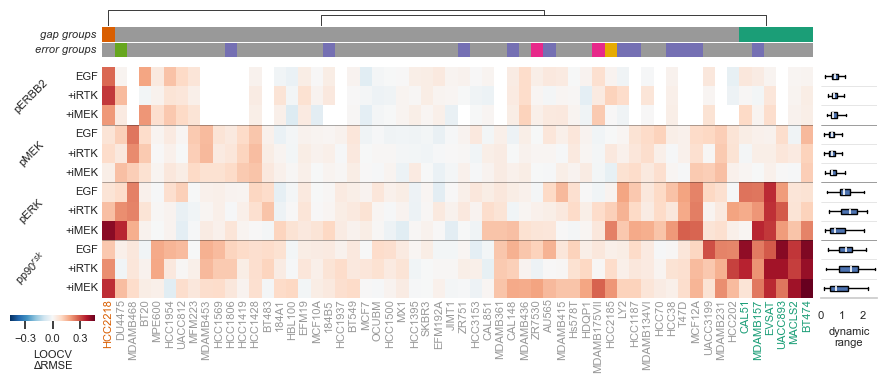

In [6]:

# ── Shared heatmap plotting helpers ───────────────────────────────────

def _hm_draw_obs_separators(ax, row_index):
    """Draw horizontal lines between observable groups."""
    for obs in _OBS_ORDER_HM[:-1]:
        obs_label = OBS_LABELS.get(obs + "_obs", obs).replace(" [a.u.]", "")
        matching = [i for i, r in enumerate(row_index) if r.startswith(obs_label)]
        if matching:
            ax.axhline(matching[-1] + 1, color="k", lw=LW_THIN, alpha=0.5)


def _hm_draw_obs_labels(ax, row_index):
    """Draw rotated observable group labels on the left side."""
    from matplotlib.transforms import blended_transform_factory
    left_trans = blended_transform_factory(ax.transAxes, ax.transData)
    for obs in _OBS_ORDER_HM:
        obs_label = OBS_LABELS.get(obs + "_obs", obs).replace(" [a.u.]", "")
        matching = [i for i, r in enumerate(row_index) if r.startswith(obs_label)]
        if matching:
            center_y = (matching[0] + matching[-1]) / 2 + 0.5
            ax.text(-0.1, center_y, obs_label, transform=left_trans,
                    ha="center", va="center", fontsize=FONTSIZE,
                    clip_on=False, rotation=45)


def _hm_format_ylabels(ax, fontsize=FONTSIZE, shorten=False):
    """Format y-tick labels.

    shorten: if True, strip the observable prefix (keep only the part after " / ").
    """
    labels = [tl.get_text() for tl in ax.get_yticklabels()]
    if shorten:
        labels = [lbl.split(" / ")[1] if " / " in lbl else lbl for lbl in labels]
    ax.set_yticklabels(labels, fontsize=fontsize)
    ax.tick_params(axis="y", pad=-3)


def _hm_draw_color_strips(ax, ordered_cols, strips, y_start=-1.25, height=0.75,
                           gap=0.05, labels=None, offset_x=0.0):
    """Draw color-coded strips below the heatmap.

    strips: list of (value_map, color_map) tuples, drawn top-to-bottom.
        value_map: dict mapping column name → category label
        color_map: dict mapping category label → color
    gap: vertical gap between consecutive strips.
    labels: optional list of str (same length as strips) for left-side labels.
    """
    for si, (value_map, color_map) in enumerate(strips):
        strip_y = y_start - si * (height + gap)
        for j, cl in enumerate(ordered_cols):
            color = color_map.get(value_map.get(cl, ""), "#d9d9d9")
            ax.add_patch(plt.Rectangle(
                (j + offset_x, strip_y), 1, height, facecolor=color, edgecolor="none",
                clip_on=False))
        if labels is not None and si < len(labels):
            ax.text(-0.5 + offset_x, strip_y + height / 2, labels[si],
                    ha="right", va="center", fontsize=FONTSIZE,
                    clip_on=False, style="italic")


def _hm_draw_dendrogram(ax, linkage_mat, n_cols, n_rows, color_threshold=None):
    """Draw dendrogram above heatmap as an inset axes."""
    dendro = _dendrogram_func(linkage_mat, no_plot=True)
    strip_frac = 2 / n_rows
    ax_dend = ax.inset_axes([0, 1.0 + strip_frac + 0.01, 1, 0.07])
    for xs, ys in zip(dendro["icoord"], dendro["dcoord"]):
        ax_dend.plot([x / 10 for x in xs], ys, color="k", lw=0.6)
    ax_dend.set_xlim(0, n_cols)
    if color_threshold is not None:
        _y_max = max(y for ys in dendro["dcoord"] for y in ys)
        ax_dend.set_ylim(color_threshold, _y_max)
    ax_dend.set_axis_off()
    return ax_dend


def _hm_draw_colorbar(ax, cmap, vmin, vmax, label, ticks=None,
                       pos=(-0.13, -0.1, 0.12, 0.025)):
    """Draw a colorbar as an inset axes."""
    import matplotlib.colors as mcolors
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    ax_cbar = ax.inset_axes(list(pos))
    cbar = plt.colorbar(sm, cax=ax_cbar, orientation="horizontal")
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=FONTSIZE)
    cbar.set_label(label, fontsize=FONTSIZE)
    if ticks is not None:
        cbar.ax.set_xticks(ticks)
    return cbar


# ── Boxplot stat helpers ───────────────────────────────────────────────

def _compute_heatmap_boxplot_stats(traj_df, row_order, row_label_map):
    """Compute per-row variance and max-min range stats from trajectory data.

    Deduplicates on (cell_line, condition, observable, time) so that repeated
    jobs do not inflate statistics.

    Returns (range_data) — dict mapping row_label → list of per-cell-line floats.
    """
    traj_unique = traj_df.drop_duplicates(
        subset=["cell_line", "condition", "observable", "time"])
    inv_map = {v: k for k, v in row_label_map.items()}

    range_data = {}

    for row_label in row_order:
        key = inv_map.get(row_label)
        if key is None:
            continue
        parts = key.split("\n")
        if len(parts) != 2:
            continue
        obs_short, cond = parts

        sub = traj_unique[
            (traj_unique["observable"].str.replace("_obs", "", regex=False)
             == obs_short)
            & (traj_unique["condition"] == cond)
        ]

        # 2) Max-min range per cell line
        mm_vals = (sub.groupby("cell_line")["obs"]
                   .apply(lambda x: x.max() - x.min())
                   .dropna().tolist())

        range_data[row_label] = mm_vals

    return range_data


def plot_panel_heatmap_boxplots(ax_range, row_order, range_data):
    """Draw horizontal boxplots aligned with heatmap rows.

        ax_box receives the variance distribution (x-axis on bottom, blue).
    """
    n_rows = len(row_order)

    BOX_WIDTH = 0.28

    bp_kw_mm = {
        "vert": False,
        "widths": BOX_WIDTH,
        "patch_artist": True,
        "showfliers": False,
        "medianprops": {"lw": 1.2, "color": "white"},
    }

    for i_row, row_label in enumerate(row_order):
        mm_vals = range_data.get(row_label, [])
        ax_range.boxplot(mm_vals, positions=[i_row + 0.5], **bp_kw_mm)

    # Draw row-separator guide lines
    for i in range(1, n_rows):
        ax_range.axhline(i, color="lightgrey", lw=0.4, zorder=0)

    # Draw observable-group separator lines (matching heatmap)
    for obs in _OBS_ORDER_HM[:-1]:
        obs_label = OBS_LABELS.get(obs + "_obs", obs).replace(" [a.u.]", "")
        matching = [i for i, r in enumerate(row_order) if r.startswith(obs_label)]
        if matching:
            ax_range.axhline(matching[-1] + 1, color="k", lw=LW_THIN, alpha=0.5)

    # Align y-axis with heatmap (inverted, rows top-to-bottom)
    ax_range.set_ylim(n_rows, 0)

    ax_range.tick_params(axis="x", labelsize=FONTSIZE)
    ax_range.set_xlabel("dynamic\nrange", fontsize=FONTSIZE)
    ax_range.spines["left"].set_visible(False)
    ax_range.spines["right"].set_visible(False)
    ax_range.spines["top"].set_visible(False)
    ax_range.set_xlim([0, ax_range.get_xlim()[1]])  # ensure x-axis starts at 0
    ax_range.set_xticks([0, 1, 2])
    ax_range.grid(False, axis="both")
    ax_range.set_yticks([])
    ax_range.set_ylabel("")



# ── Panel functions ───────────────────────────────────────────────────

def plot_panel_delta_heatmap(ax, train_rmse_sg, ax_box=None):
    """Plot ΔRMSE heatmap on a given axes.

    ax_box: optional axes to the right for aligned boxplots.
    """
    _leaf_order = _leaves_list(_col_linkage)
    _ordered_cols = [_hm_pivot_filled.columns[i] for i in _leaf_order]
    _data = _hm_pivot_filled[_ordered_cols]
    _mask = _hm_pivot[_ordered_cols].isna()

    sns.heatmap(_data, ax=ax, cmap="RdBu_r", vmin=-_vabs, vmax=_vabs,
                mask=_mask, cbar=False,
                xticklabels=True, yticklabels=True)
    ax.grid(False)
    ax.set_ylabel("")

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=FONTSIZE)
    ax.tick_params(axis="x", pad=-5)
    for tl in ax.get_xticklabels():
        sg = gap_subgroups.get(tl.get_text(), "low gap")
        tl.set_color(_SUBGROUP_COLORS.get(sg, "black"))

    _hm_format_ylabels(ax, fontsize=FONTSIZE, shorten=True)
    _hm_draw_obs_labels(ax, _data.index)
    _hm_draw_obs_separators(ax, _data.index)

    _hm_draw_color_strips(ax, _ordered_cols, [
        (train_rmse_sg, _TRAIN_RMSE_COLORS),
        (gap_subgroups, _SUBGROUP_COLORS),
    ], labels=["error groups", "gap groups"])

    _n_clust = len(_SUBGROUP_COLORS)
    _dend_thresh = _col_linkage[-_n_clust, 2]
    _hm_draw_dendrogram(ax, _col_linkage, len(_ordered_cols), len(_data.index),
                        color_threshold=_dend_thresh)
    _hm_draw_colorbar(ax, "RdBu_r", -_vabs, _vabs, "LOOCV\nΔRMSE",
                      ticks=[-0.3, 0.0, 0.3])
    ax.set_title("", fontsize=FONTSIZE)

    if ax_box is not None:
        _mm_data = _compute_heatmap_boxplot_stats(
            _traj_hm, _data.index.tolist(), _row_label_map)
        plot_panel_heatmap_boxplots(ax_box, _data.index.tolist(), _mm_data)


# ── Panel A — standalone plot ─────────────────────────────────────────
fig_a, (_ax_a_hm, _ax_a_box) = plt.subplots(
    1, 2, figsize=(10, 3),
    gridspec_kw={"width_ratios": [5, 0.4], "wspace": 0.02})
ax_a = _ax_a_hm

plot_panel_delta_heatmap(ax_a, train_rmse_sg=train_rmse_subgroups,
                         ax_box=_ax_a_box)
print("Panel A saved.")
fig_a.savefig("Panel_A_heatmap.pdf", dpi=300, bbox_inches="tight")

plt.show()


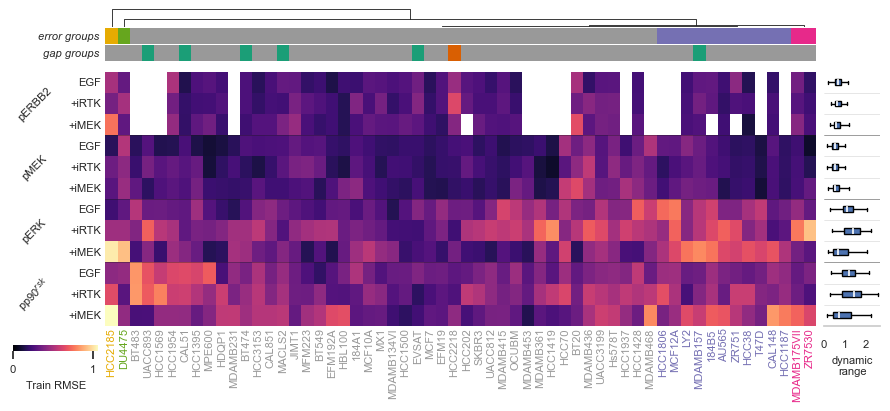

In [7]:
def plot_panel_train_heatmap(ax, ax_box=None):
    """Plot Train RMSE heatmap on a given axes."""
    _leaf_order = _leaves_list(_train_col_linkage)
    _ordered_cols = [_train_filled.columns[i] for i in _leaf_order]
    _data = _train_filled[_ordered_cols]
    _mask = _train_pivot[_ordered_cols].isna()

    sns.heatmap(_data, ax=ax, cmap="magma", vmin=0,
                mask=_mask, cbar=False,
                xticklabels=True, yticklabels=True)
    ax.grid(False)
    ax.set_ylabel("")

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=FONTSIZE)
    ax.tick_params(axis="x", pad=-5)
    for tl in ax.get_xticklabels():
        sg = train_rmse_subgroups.get(tl.get_text(), "other")
        tl.set_color(_TRAIN_RMSE_COLORS.get(sg, "black"))

    _hm_format_ylabels(ax, fontsize=FONTSIZE, shorten=True)
    _hm_draw_obs_labels(ax, _data.index)
    _hm_draw_obs_separators(ax, _data.index)

    _hm_draw_color_strips(ax, _ordered_cols, [
        (gap_subgroups, _SUBGROUP_COLORS),
        (train_rmse_subgroups, _TRAIN_RMSE_COLORS),
    ], labels=["gap groups", "error groups"])

    _n_clust_train = len(_TRAIN_RMSE_COLORS)
    _dend_thresh_train = _train_col_linkage[-_n_clust_train, 2]
    _hm_draw_dendrogram(ax, _train_col_linkage,
                        len(_ordered_cols), len(_data.index),
                        color_threshold=_dend_thresh_train)

    _vmax = _data.values[~_mask.values].max()
    _hm_draw_colorbar(ax, "magma", 0, _vmax, "Train RMSE")

    if ax_box is not None:
        _mm_data = _compute_heatmap_boxplot_stats(
            _traj_hm, _data.index.tolist(), _row_label_map)
        plot_panel_heatmap_boxplots(
            ax_box, _data.index.tolist(), _mm_data)


# Train RMSE heatmap
fig_train_dist, (_ax_tr_hm, _ax_tr_box) = plt.subplots(
    1, 2, figsize=(10, 3.3),
    gridspec_kw={"width_ratios": [5, 0.4], "wspace": 0.02})
ax_train = _ax_tr_hm

plot_panel_train_heatmap(ax_train, ax_box=_ax_tr_box)
plt.show()


## Panels B–D — Gap scatter plots

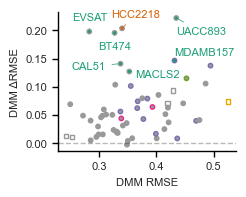

In [8]:
# Dataset marker shapes: train = circle, val = square, test = diamond
_DATASET_MARKERS = {"train": "o", "val": "s", "test": "D"}
_MARKER_SIZE = 10

def _subgroup_colors_for_df(plot_df, subgroups_full):
    """Return list of per-point colours based on gap subgroups."""
    return [_SUBGROUP_COLORS.get(subgroups_full.get(cl, "low gap"), _SUBGROUP_COLORS["low gap"])
            for cl in plot_df["cell_line"]]

def _rmse_edge_colors_for_df(plot_df, train_rmse_sg):
    """Return list of per-point edge colours based on train RMSE subgroups.
    Keys in train_rmse_sg use short names (no 'c' prefix)."""
    return [_TRAIN_RMSE_COLORS.get(
                train_rmse_sg.get(cl.replace("c", "", 1), "other"),
                _TRAIN_RMSE_COLORS["other"])
            for cl in plot_df["cell_line"]]

def _scatter_by_dataset(ax, plot_df, x_col, y_col, subgroups_full,
                        val_cls=None, test_cls=None, train_rmse_sg=None):
    """Scatter points using subgroup colors and dataset-specific markers.
    Train markers are filled; val/test markers are hollow (unfilled).
    If train_rmse_sg is given, edge color encodes train-RMSE subgroup."""
    if val_cls is None:
        val_cls = _VAL_CELL_LINES
    if test_cls is None:
        test_cls = set()
    for ds, marker in _DATASET_MARKERS.items():
        if ds == "val":
            mask = plot_df["cell_line"].isin(val_cls)
        elif ds == "test":
            mask = plot_df["cell_line"].isin(test_cls)
        else:
            mask = ~plot_df["cell_line"].isin(val_cls | test_cls)
        sub = plot_df[mask]
        if sub.empty:
            continue
        colors = _subgroup_colors_for_df(sub, subgroups_full)
        if ds == "train":
            edge_kw = {"linewidths": LW_THIN}
            if train_rmse_sg is not None:
                edge_kw["edgecolors"] = _rmse_edge_colors_for_df(sub, train_rmse_sg)
                edge_kw["linewidths"] = LW_MEDIUM
            ax.scatter(sub[x_col], sub[y_col], c=colors,
                       s=_MARKER_SIZE, marker=marker,
                       alpha=1.0, zorder=2,
                       **edge_kw)
        else:
            edge_colors = colors
            if train_rmse_sg is not None:
                edge_colors = _rmse_edge_colors_for_df(sub, train_rmse_sg)
            ax.scatter(sub[x_col], sub[y_col],
                       facecolors="none", edgecolors=edge_colors,
                       s=_MARKER_SIZE, marker=marker,
                       alpha=1.0, linewidths=LW_MEDIUM, zorder=3)

def _annotate_non_lowgap(ax, plot_df, x_col, y_col, subgroups_full, offsets):
    """Annotate cell lines not in the 'low gap' subgroup."""
    for _, row in plot_df.iterrows():
        sg = subgroups_full.get(row["cell_line"], "low gap")
        if sg != "low gap":
            name = row["cell_line"].replace("c", "", 1)
            ofs = offsets.get(name, (10, 5))
            color = _SUBGROUP_COLORS[sg]
            ax.annotate(
                name, (row[x_col], row[y_col]),
                xytext=ofs, textcoords="offset points",
                fontsize=FONTSIZE, color=color,
                arrowprops=dict(arrowstyle="-", color=color,
                                lw=LW_THIN))

def _add_subgroup_legend(ax, include_markers=True, include_rmse_edges=False,
                         **kwargs):
    """Add a legend with subgroup colors and dataset marker shapes."""
    handles = [Patch(facecolor=_SUBGROUP_COLORS[sg], label=sg)
               for sg in _SUBGROUP_ORDER]
    if include_rmse_edges:
        for sg in _TRAIN_RMSE_ORDER:
            handles.append(Line2D([0], [0], marker="o", color="w",
                markerfacecolor="w", markeredgecolor=_TRAIN_RMSE_COLORS[sg],
                markeredgewidth=LW_MEDIUM, markersize=5, linewidth=0,
                label=sg))
    if include_markers:
        for lbl, m in _DATASET_MARKERS.items():
            if lbl == "train":
                handles.append(Line2D([0], [0], marker=m, color="w",
                    markerfacecolor="k", markeredgecolor="k",
                    markersize=5, linewidth=0, label=lbl))
            else:
                handles.append(Line2D([0], [0], marker=m, color="w",
                    markerfacecolor="none", markeredgecolor="k",
                    markersize=5, linewidth=0, label=lbl))
    defaults = dict(fontsize=FONTSIZE - 1, frameon=False, loc="upper left")
    defaults.update(kwargs)
    ax.legend(handles=handles, **defaults)

# Label offsets (dx, dy) in points for each panel
_LABEL_OFFSETS_B = {
    "BT474":    (-12, -12),
    "CAL51":    (-35, -4),
    "EVSAT":    (-12, 8),
    "HCC2218":  (-8, 8),
    "MACLS2":   (4, -4),
    "MDAMB157": (0, 4),
    "UACC893":  (0, -12),
    "HCC202":   (-35, -8)
}


def plot_panel_gap_vs_rmse(ax, gap_vs_rmse_df, subgroups_full, *, method="dmm",
                           context=None, title=None, train_rmse_sg=None):
    """Panel B: RMSE (all split) vs generalisation gap, colored by subgroup."""
    if method == "dmm":
        x_col, y_col = "rmse_all_dmm", "gap_dmm"
        default_title = ""
    else:
        x_col, y_col = "rmse_all_reg", "gap_regression"
        default_title = ""
    plot_df = gap_vs_rmse_df.copy()
    if context is not None:
        plot_df = plot_df[plot_df["context"] == context]
    _scatter_by_dataset(ax, plot_df, x_col, y_col, subgroups_full,
                        train_rmse_sg=train_rmse_sg)
    ax.axhline(0, color="k", ls="--", alpha=0.3, lw=LW_MEDIUM)
    _annotate_non_lowgap(ax, plot_df, x_col, y_col, subgroups_full, _LABEL_OFFSETS_B)
    ax.set_xlabel("DMM RMSE" if method == "dmm" else "Regression RMSE", fontsize=FONTSIZE)
    ax.set_ylabel("DMM ΔRMSE" if method == "dmm" else "Regression gap", fontsize=FONTSIZE)
    ax.set_title(title or default_title, fontsize=FONTSIZE_HEADING)
    ax.grid(False)
    #_add_subgroup_legend(ax, include_rmse_edges=train_rmse_sg is not None)
    configure_axis_spines(ax)

# Panel B — DMM RMSE vs Gap
fig_a, ax_a = plt.subplots(figsize=(2.5, 2))
_ctx = sorted(D.gap_vs_rmse["context"].unique())[0]
plot_panel_gap_vs_rmse(ax_a, D.gap_vs_rmse, gap_subgroups_full, method="dmm",
                       context=_ctx, train_rmse_sg=train_rmse_subgroups)
fig_a.tight_layout()
fig_a.savefig("fig_gap_panelB.pdf", bbox_inches="tight")
plt.show()

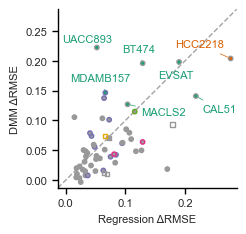

In [9]:
_LABEL_OFFSETS_C = {
    "BT474":    (-15, 8),
    "CAL51":    (5, -12),
    "EVSAT":    (-15, -12),
    "HCC2218":  (-40, 8),
    "MACLS2":   (10, -8),
    "MDAMB157": (-25, 8),
    "UACC893":  (-25, 4),
    "HCC202":   (40, -20)
}

def plot_panel_gap_scatter(ax, merged_df, subgroups_full, *, context=None,
                           title=None, show_ylabel=True, shared_ylim=None,
                           train_rmse_sg=None):
    """Panel C: Regression gap (x) vs DMM gap (y) per cell line, colored by subgroup."""
    plot_df = merged_df.copy()
    if context is not None:
        plot_df = plot_df[plot_df["context"] == context]
    _scatter_by_dataset(ax, plot_df, "gap_regression", "gap_dmm", subgroups_full,
                        train_rmse_sg=train_rmse_sg)
    if shared_ylim is not None:
        ylo, yhi = shared_ylim
        ax.set_ylim(ylo, yhi)
        x_pad = 0.01
        ax.set_xlim(plot_df["gap_regression"].min() - x_pad,
                     plot_df["gap_regression"].max() + x_pad)
        diag_lo = min(ylo, plot_df["gap_regression"].min() - x_pad)
        diag_hi = max(yhi, plot_df["gap_regression"].max() + x_pad)
    else:
        lims = [
            min(plot_df["gap_dmm"].min(), plot_df["gap_regression"].min()) - 0.01,
            max(plot_df["gap_dmm"].max(), plot_df["gap_regression"].max()) + 0.01,
        ]
        ax.set_xlim(lims); ax.set_ylim(lims)
        diag_lo, diag_hi = lims
    ax.plot([diag_lo, diag_hi], [diag_lo, diag_hi], "k--", alpha=0.4,
            lw=LW_MEDIUM, zorder=0)
    ax.set_aspect("equal", adjustable="box")

    _annotate_non_lowgap(ax, plot_df, "gap_regression", "gap_dmm",
                         subgroups_full, _LABEL_OFFSETS_C)
    ax.set_xlabel("Regression ΔRMSE", fontsize=FONTSIZE)
    ax.set_ylabel("DMM ΔRMSE" if show_ylabel else "", fontsize=FONTSIZE)
    ax.grid(False)
    # _add_subgroup_legend(ax, include_rmse_edges=train_rmse_sg is not None)
    configure_axis_spines(ax)

# Panel C — DMM vs Regression Gap
fig_b, ax_b = plt.subplots(figsize=(2.5, 2.5))
plot_panel_gap_scatter(ax_b, D.gap_vs_rmse, gap_subgroups_full, context=_ctx,
                       train_rmse_sg=train_rmse_subgroups)
fig_b.tight_layout()
fig_b.savefig("fig_gap_panelC.pdf", bbox_inches="tight")
plt.show()

RMSE | low gap | DMM vs Regression: p=0.03064  (*)
RMSE | high p90RSK gap | DMM vs Regression: p=1  (n.s.)
RMSE | other | DMM vs Regression: p=0.114  (n.s.)
RMSE | high iMEK RMSE | DMM vs Regression: p=0.3579  (n.s.)
RMSE | high iEGFR/iMEK RMSE | DMM vs Regression: p=0.3333  (n.s.)
ΔRMSE | low gap | DMM vs Regression: p=0.02912  (*)
ΔRMSE | high p90RSK gap | DMM vs Regression: p=0.1797  (n.s.)
ΔRMSE | other | DMM vs Regression: p=0.09901  (n.s.)
ΔRMSE | high iMEK RMSE | DMM vs Regression: p=1  (n.s.)
ΔRMSE | high iEGFR/iMEK RMSE | DMM vs Regression: p=0.3333  (n.s.)


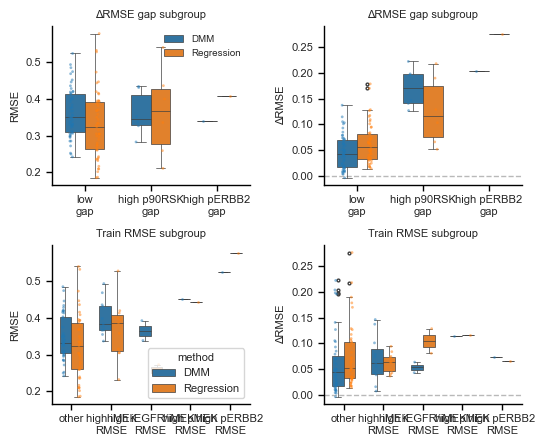

In [10]:
# ── Boxplot: RMSE and ΔRMSE across gap subgroups + train RMSE subgroups ───
from scipy.stats import mannwhitneyu as _mwu

_ctx_box = sorted(D.gap_vs_rmse["context"].unique())[0]
_box_src = D.gap_vs_rmse[D.gap_vs_rmse["context"] == _ctx_box].copy()
_box_src["gap_subgroup"] = _box_src["cell_line"].map(
    lambda cl: gap_subgroups_full.get(cl, "low gap"))
_box_src["rmse_subgroup"] = _box_src["cell_line"].map(
    lambda cl: train_rmse_subgroups.get(cl.replace("c", "", 1), "other"))

# Melt into long form: one row per (cell_line, method, metric)
_long_rows = []
for _, r in _box_src.iterrows():
    cl = r["cell_line"]
    gap_sg = r["gap_subgroup"]
    rmse_sg = r["rmse_subgroup"]
    _long_rows.append({"cell_line": cl, "gap_subgroup": gap_sg, "rmse_subgroup": rmse_sg,
                        "method": "DMM", "metric": "RMSE", "value": r["rmse_all_dmm"]})
    _long_rows.append({"cell_line": cl, "gap_subgroup": gap_sg, "rmse_subgroup": rmse_sg,
                        "method": "Regression", "metric": "RMSE", "value": r["rmse_all_reg"]})
    _long_rows.append({"cell_line": cl, "gap_subgroup": gap_sg, "rmse_subgroup": rmse_sg,
                        "method": "DMM", "metric": "ΔRMSE", "value": r["gap_dmm"]})
    _long_rows.append({"cell_line": cl, "gap_subgroup": gap_sg, "rmse_subgroup": rmse_sg,
                        "method": "Regression", "metric": "ΔRMSE", "value": r["gap_regression"]})
_long_df = pd.DataFrame(_long_rows)

# ── Layout: 2 rows × 2 cols (top = gap subgroups, bottom = train RMSE subgroups)
fig_bp, axes_bp = plt.subplots(2, 2, figsize=(5.5, 4.5), sharey=False)

_gap_order = _SUBGROUP_ORDER  # ["high pERBB2 gap", "high p90RSK gap", "low gap"]
_rmse_order = _TRAIN_RMSE_ORDER  # ["high iMEK RMSE", "other"]

for col_i, metric in enumerate(["RMSE", "ΔRMSE"]):
    sub = _long_df[_long_df["metric"] == metric]

    # ── Row 0: gap subgroups ──
    ax = axes_bp[0, col_i]
    sns.boxplot(
        data=sub, x="gap_subgroup", y="value", hue="method",
        order=_gap_order, hue_order=["DMM", "Regression"],
        palette={"DMM": "#1f77b4", "Regression": "#ff7f0e"},
        width=0.6, linewidth=LW_THIN, fliersize=2, ax=ax,
    )
    sns.stripplot(
        data=sub, x="gap_subgroup", y="value", hue="method",
        order=_gap_order, hue_order=["DMM", "Regression"],
        palette={"DMM": "#1f77b4", "Regression": "#ff7f0e"},
        dodge=True, size=2, alpha=0.5, jitter=0.05, ax=ax, legend=False,
    )
    ax.set_xlabel("", fontsize=FONTSIZE)
    ax.set_ylabel(metric, fontsize=FONTSIZE)
    ax.tick_params(axis="both", labelsize=FONTSIZE)
    ax.set_xticklabels([s.replace(" gap", "\ngap") for s in _gap_order],
                       fontsize=FONTSIZE)
    configure_axis_spines(ax)
    ax.grid(False)
    if metric == "ΔRMSE":
        ax.axhline(0, color="k", ls="--", alpha=0.3, lw=LW_MEDIUM)
    if col_i == 0:
        ax.legend(fontsize=FONTSIZE - 1, frameon=False, loc="upper right")
        ax.set_title("ΔRMSE gap subgroup", fontsize=FONTSIZE)
    else:
        ax.get_legend().remove()
        ax.set_title("ΔRMSE gap subgroup", fontsize=FONTSIZE)

    # Mann-Whitney: DMM vs Regression within each gap subgroup
    for sg in _gap_order:
        dmm_vals = sub[(sub["gap_subgroup"] == sg) & (sub["method"] == "DMM")]["value"]
        reg_vals = sub[(sub["gap_subgroup"] == sg) & (sub["method"] == "Regression")]["value"]
        if len(dmm_vals) > 1 and len(reg_vals) > 1:
            _, p = _mwu(dmm_vals, reg_vals, alternative="two-sided")
            print(f"{metric} | {sg} | DMM vs Regression: p={p:.4g}  ({_sig_label(p)})")

    # ── Row 1: train RMSE subgroups ──
    ax2 = axes_bp[1, col_i]
    sns.boxplot(
        data=sub, x="rmse_subgroup", y="value", hue="method",
        order=_rmse_order, hue_order=["DMM", "Regression"],
        palette={"DMM": "#1f77b4", "Regression": "#ff7f0e"},
        width=0.6, linewidth=LW_THIN, fliersize=2, ax=ax2,
    )
    sns.stripplot(
        data=sub, x="rmse_subgroup", y="value", hue="method",
        order=_rmse_order, hue_order=["DMM", "Regression"],
        palette={"DMM": "#1f77b4", "Regression": "#ff7f0e"},
        dodge=True, size=2, alpha=0.5, jitter=0.05, ax=ax2, legend=False,
    )
    ax2.set_xlabel("", fontsize=FONTSIZE)
    ax2.set_ylabel(metric, fontsize=FONTSIZE)
    ax2.tick_params(axis="both", labelsize=FONTSIZE)
    ax2.set_xticklabels([s.replace(" RMSE", "\nRMSE") for s in _rmse_order],
                        fontsize=FONTSIZE)
    configure_axis_spines(ax2)
    ax2.grid(False)
    if metric == "ΔRMSE":
        ax2.axhline(0, color="k", ls="--", alpha=0.3, lw=LW_MEDIUM)
    if col_i == 0:
        ax2.set_title("Train RMSE subgroup", fontsize=FONTSIZE)
    else:
        ax2.get_legend().remove() if ax2.get_legend() else None
        ax2.set_title("Train RMSE subgroup", fontsize=FONTSIZE)

    # Mann-Whitney: DMM vs Regression within each train RMSE subgroup
    for sg in _rmse_order:
        dmm_vals = sub[(sub["rmse_subgroup"] == sg) & (sub["method"] == "DMM")]["value"]
        reg_vals = sub[(sub["rmse_subgroup"] == sg) & (sub["method"] == "Regression")]["value"]
        if len(dmm_vals) > 1 and len(reg_vals) > 1:
            _, p = _mwu(dmm_vals, reg_vals, alternative="two-sided")
            print(f"{metric} | {sg} | DMM vs Regression: p={p:.4g}  ({_sig_label(p)})")

fig_bp.tight_layout()
fig_bp.savefig("fig_gap_boxplot_rmse_delta.pdf", bbox_inches="tight")
plt.show()

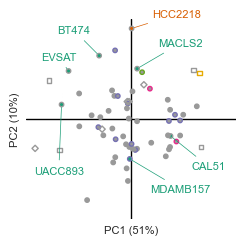

In [11]:
_LABEL_OFFSETS_D = {
    "BT474":    (-30, 16),
    "CAL51":    (15, -24),
    "EVSAT":    (-20, 8),
    "HCC2218":  (15, 8),
    "MACLS2":   (15, 16),
    "MDAMB157": (15, -24),
    "UACC893":  (-20, -50),
    "HCC202":   (-10, -20)
}

def plot_panel_pca(ax, pca_df, ve1, ve2, subgroups_full, test_cls=None,
                   train_rmse_sg=None):
    """Panel D: CyTOF PCA scatter, colored by subgroup."""
    _pca_plot = pca_df.copy()
    _pca_plot["cell_line"] = _pca_plot.index
    _scatter_by_dataset(ax, _pca_plot, "PC1", "PC2", subgroups_full,
                        test_cls=test_cls, train_rmse_sg=train_rmse_sg)
    # Annotate non-low-gap cell lines
    for cl in _pca_plot["cell_line"]:
        sg = subgroups_full.get(cl, "low gap")
        if sg != "low gap" and cl in _pca_plot.index:
            name = cl.replace("c", "", 1)
            ofs = _LABEL_OFFSETS_D.get(name, (10, 5))
            color = _SUBGROUP_COLORS[sg]
            ax.annotate(
                name, (_pca_plot.loc[cl, "PC1"], _pca_plot.loc[cl, "PC2"]),
                xytext=ofs, textcoords="offset points",
                fontsize=FONTSIZE, color=color,
                arrowprops=dict(arrowstyle="-", color=color,
                                lw=LW_THIN))
    ax.axhline(0, color=AXIS_SPINE_COLOR, alpha=1.0, lw=AXIS_SPINE_LINEWIDTH, zorder=0)
    ax.axvline(0, color=AXIS_SPINE_COLOR, alpha=1.0, lw=AXIS_SPINE_LINEWIDTH, zorder=0)
    _pc1_abs = max(abs(_pca_plot["PC1"].min()), abs(_pca_plot["PC1"].max())) * 1.1
    _pc2_abs = max(abs(_pca_plot["PC2"].min()), abs(_pca_plot["PC2"].max())) * 1.1
    ax.set_xlim(-_pc1_abs, _pc1_abs)
    ax.set_ylim(-_pc2_abs, _pc2_abs)
    ax.set_xlabel(f"PC1 ({ve1:.0%})", fontsize=FONTSIZE)
    ax.set_ylabel(f"PC2 ({ve2:.0%})", fontsize=FONTSIZE)
    ax.set_title("", fontsize=FONTSIZE_HEADING)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    # _add_subgroup_legend(ax, include_rmse_edges=train_rmse_sg is not None)

# Panel D — CyTOF PCA
fig_c, ax_c = plt.subplots(figsize=(2.5, 2.5))
_test_cls = set(D.pca_df.index) - set(D.gap_vs_rmse["cell_line"])
plot_panel_pca(ax_c, D.pca_df, D.ve1, D.ve2, gap_subgroups_full,
               test_cls=_test_cls, train_rmse_sg=train_rmse_subgroups)
fig_c.tight_layout()
fig_c.savefig("fig_gap_panelD.pdf", bbox_inches="tight")
plt.show()

## Binned dynamic CyTOF data by gap subgroup

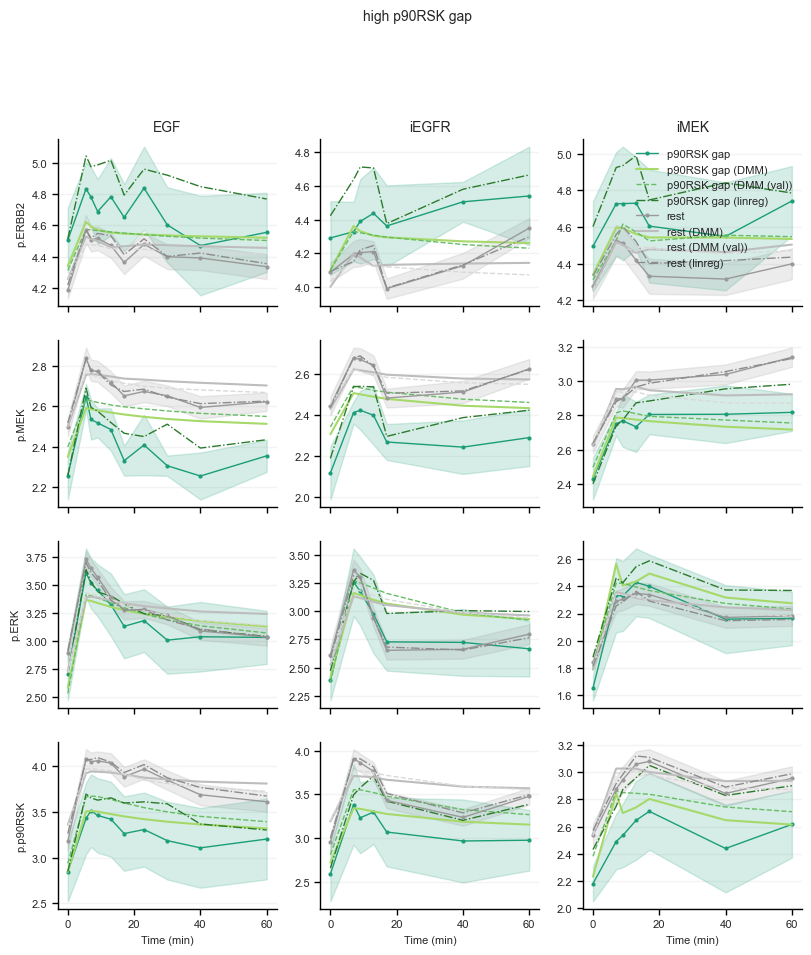

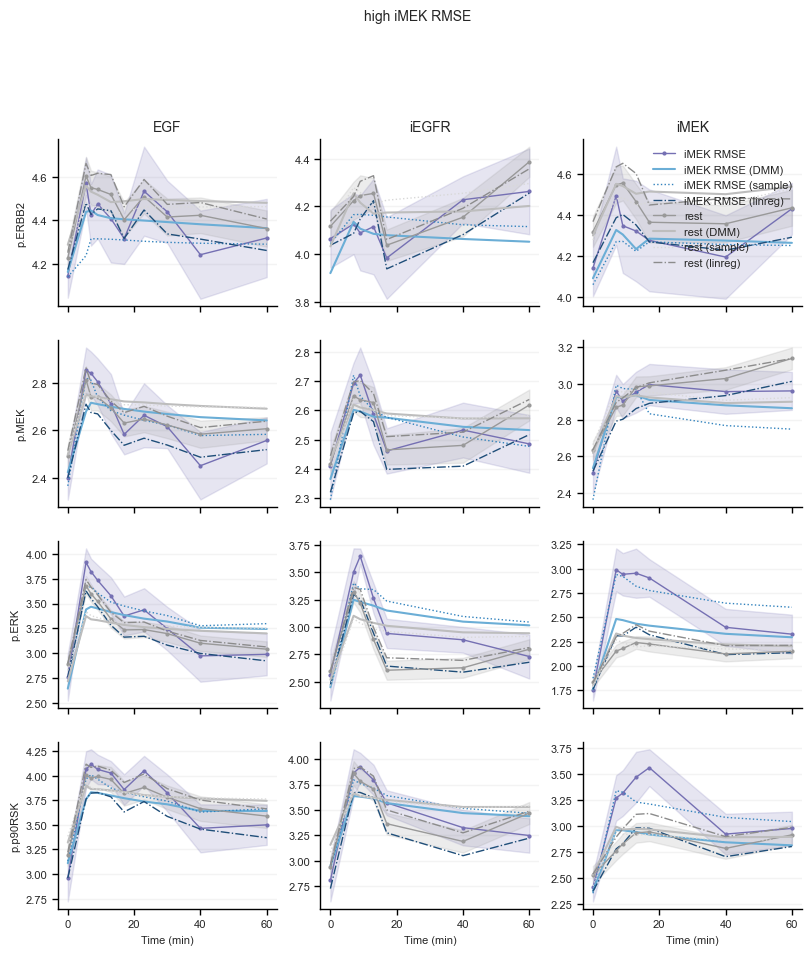

In [12]:
# ── Binned dynamics: experimental CyTOF + DMM simulations by gap subgroup ─────
from figures_paper.embeddings import load_dynamic_cytof_data

# Observable mapping: display name → CyTOF observableId, trajectory observable
_DYN_OBS = {
    "p.ERBB2":  ("p.HER2",            "pERBB2_Y1248_obs"),
    "p.MEK":    ("p.MEK",             "pMEK_S222_obs"),
    "p.ERK":    ("p.ERK",             "pERK_Y204_obs"),
    "p.p90RSK": ("p.p90RSK",          "pRPS6KA1_S380_obs"),
}
_DYN_CONDITIONS = ["EGF", "iEGFR", "iMEK"]
_DYN_REG_REFS = ("linreg",)

# Colors: rest is always gray; "in" uses the subgroup colour
_DYN_REST_COLOR = "#999999"
_DYN_IN_COLORS = {
    "high p90RSK gap": _SUBGROUP_COLORS["high p90RSK gap"],   # green
    "high iMEK RMSE":  _TRAIN_RMSE_COLORS["high iMEK RMSE"], # blue
}
# Simulation overlay colours: lighter variant for DMM/sample, darker shades for regressors
_DYN_SIM_COLORS   = {
    "high p90RSK gap": {
        "DMM":        {"in": "#a6d96a", "rest": "#bdbdbd"},
        "DMM (val)":  {"in": "#66bd63", "rest": "#d9d9d9"},
        "sample":     {"in": "#4d9221", "rest": "#cfcfcf"},
        "linreg":     {"in": "#2c7a2c", "rest": "#8c8c8c"},
        # "lasso":      {"in": "#1f5f1f", "rest": "#7a7a7a"},
        # "elasticnet": {"in": "#144714", "rest": "#666666"},
    },
    "high iMEK RMSE": {
        "DMM":        {"in": "#6baed6", "rest": "#bdbdbd"},
        "sample":     {"in": "#3182bd", "rest": "#d9d9d9"},
        "linreg":     {"in": "#1f4e79", "rest": "#8c8c8c"},
        # "lasso":      {"in": "#123a5a", "rest": "#7a7a7a"},
        # "elasticnet": {"in": "#0b2a42", "rest": "#666666"},
    },
}

# Subgroups to plot
_DYN_SUBGROUPS = [
    ("high p90RSK gap", gap_subgroups),
    ("high iMEK RMSE",  train_rmse_subgroups),
]


def plot_subgroup_dynamics(
    ax, obs_display, condition, subgroup_name, subgroup_dict,
    sim_dfs=None, min_samples=3,
    show_xlabel=True, show_ylabel=True, title=None,
):
    """Plot CyTOF dynamics binned by gap-subgroup membership.

    Cell lines in *subgroup_name* → 'in' group; all others → 'rest'.
    *sim_dfs*: dict mapping ref label (e.g. "DMM", "sample") → DataFrame.
    """
    cytof_id, traj_obs = _DYN_OBS[obs_display]
    dynamic_df = load_dynamic_cytof_data(cytof_id, condition=condition,
                                         min_samples=0)
    # subgroup_dict may use short names (no 'c' prefix) or full names
    in_cls_short = {cl for cl, sg in subgroup_dict.items() if sg == subgroup_name}
    in_cls = in_cls_short | {f"c{cl}" for cl in in_cls_short}
    dynamic_df["bin"] = dynamic_df["cell_line"].apply(
        lambda cl: "in" if cl in in_cls else "rest")

    # Average per cell line first, then across cell lines per bin
    cl_avg = (dynamic_df
              .groupby(["cell_line", "bin", "time"])["measurement"]
              .mean().reset_index())
    grouped = (cl_avg
               .groupby(["bin", "time"])["measurement"]
               .agg(["mean", "std", "count"]).reset_index())
    # Keep only timepoints where *each* bin has ≥ min_samples cell lines
    if min_samples > 1:
        _min_per_t = grouped.groupby("time")["count"].min()
        _valid_t = _min_per_t[_min_per_t >= min_samples].index
        grouped = grouped[grouped["time"].isin(_valid_t)]

    # Prepare simulation overlays (one per ref)
    valid_times = set(grouped["time"].unique())  # experimental timepoints that passed filtering
    sim_overlays = {}  # ref_label → grouped sim df
    if sim_dfs is not None:
        for ref_label, sdf in sim_dfs.items():
            sim_sub = sdf[
                (sdf["observable"] == traj_obs)
                & (sdf["condition"] == condition)
            ].copy()
            if sim_sub.empty:
                continue
            sim_sub["bin"] = sim_sub["cell_line"].apply(
                lambda cl: "in" if cl in in_cls else "rest")
            sim_grouped = (sim_sub
                           .groupby(["bin", "time"])["sim"]
                           .agg(["mean", "std", "count"]).reset_index())
            # Restrict to experimental timepoints
            sim_grouped = sim_grouped[sim_grouped["time"].isin(valid_times)]
            sim_overlays[ref_label] = sim_grouped

    # Plot experimental data
    in_color = _DYN_IN_COLORS.get(subgroup_name, "#B2182B")
    sg_sim_colors = _DYN_SIM_COLORS.get(subgroup_name, {})
    for bin_label in ("in", "rest"):
        data_color = in_color if bin_label == "in" else _DYN_REST_COLOR
        bdf = grouped[grouped["bin"] == bin_label]
        if bdf.empty:
            continue
        se = bdf["std"] / np.sqrt(bdf["count"])
        display_label = subgroup_name.replace("high ", "") if bin_label == "in" else "rest"
        ax.plot(bdf["time"], bdf["mean"], marker="o", linewidth=LW_MEDIUM,
                markersize=2, color=data_color, label=display_label)
        ax.fill_between(bdf["time"], bdf["mean"] - se, bdf["mean"] + se,
                        color=data_color, alpha=0.18)

        # Sim overlays (one line per ref)
        for ref_label, sg_df in sim_overlays.items():
            sdf = sg_df[sg_df["bin"] == bin_label]
            if sdf.empty:
                continue
            sim_color = sg_sim_colors.get(ref_label, {}).get(bin_label, data_color)
            if ref_label == "DMM":
                linestyle = "-"
                sim_lw = LW_THICK
            elif ref_label == "sample":
                linestyle = ":"
                sim_lw = LW_MEDIUM
            elif ref_label in _DYN_REG_REFS:
                linestyle = "-."
                sim_lw = LW_MEDIUM
            else:                       # "DMM (val)"
                linestyle = "--"
                sim_lw = LW_MEDIUM
            ax.plot(sdf["time"], sdf["mean"], linewidth=sim_lw,
                    linestyle=linestyle, color=sim_color,
                    label=f"{display_label} ({ref_label})")

    ax.set_xlabel("Time (min)" if show_xlabel else "", fontsize=FONTSIZE)
    ax.set_ylabel(obs_display if show_ylabel else "", fontsize=FONTSIZE)
    if title:
        ax.set_title(title, fontsize=FONTSIZE_HEADING)
    ax.tick_params(axis="both", labelsize=FONTSIZE)
    ax.grid(True, alpha=0.22)
    configure_axis_spines(ax)


# ── Prepare simulation DFs ────────────────────────────────────────────────────
# Gap subgroups: DMM train (samples=all) + DMM val (LOOCV, samples!=all) + regressors
_sim_dfs_dyn_gap = {}
# DMM train (label "DMM")
_sub_train = _traj_raw[
    (_traj_raw["ref"] == "DMM")
    & (_traj_raw["context"] == _ctx0)
    & (_traj_raw["samples"] == "all")
    & (_traj_raw["dataset"] == "train")
].copy()
if not _sub_train.empty:
    _sim_dfs_dyn_gap["DMM"] = _sub_train
# DMM val LOOCV (label "DMM (val)")
_sub_val = _traj_raw[
    (_traj_raw["ref"] == "DMM")
    & (_traj_raw["context"] == _ctx0)
    & (_traj_raw["samples"] != "all")
    & (_traj_raw["dataset"] == "val")
].copy()
if not _sub_val.empty:
    _sim_dfs_dyn_gap["DMM (val)"] = _sub_val
# Regressors from all-samples LOOCV val
for _reg_ref in _DYN_REG_REFS:
    _sub_reg = _traj_raw[
        (_traj_raw["ref"] == _reg_ref)
        & (_traj_raw["context"] == _ctx0)
        & (_traj_raw["samples"] != "all")
        & (_traj_raw["dataset"] == "val")
    ].copy()
    if not _sub_reg.empty:
        _sim_dfs_dyn_gap[_reg_ref] = _sub_reg

# iMEK RMSE subgroup: DMM + sample + regressors from "all" samples model
_sim_dfs_dyn_all = {}
for _ref in ("DMM", "sample", *_DYN_REG_REFS):
    _sub = _traj_raw[
        (_traj_raw["ref"] == _ref)
        & (_traj_raw["context"] == _ctx0)
        & (_traj_raw["samples"] == "all")
    ].copy()
    if not _sub.empty:
        _sim_dfs_dyn_all[_ref] = _sub

# Map subgroup name → sim DFs
_DYN_SIM_MAP = {
    "high p90RSK gap": _sim_dfs_dyn_gap,
    "high iMEK RMSE":  _sim_dfs_dyn_all,
}

# ── Figure: 3 subgroups × 4 observables × 3 conditions ───────────────────────
n_obs = len(_DYN_OBS)
n_conds = len(_DYN_CONDITIONS)

for sg, sg_dict in _DYN_SUBGROUPS:
    fig_dyn, axes_dyn = plt.subplots(
        n_obs, n_conds, figsize=(3.2 * n_conds, 2.5 * n_obs),
        sharex="col", squeeze=False)
    fig_dyn.suptitle(sg, fontsize=FONTSIZE_HEADING, y=1.01)

    _sim_dfs_for_sg = _DYN_SIM_MAP.get(sg, _sim_dfs_dyn_all)

    for ri, obs_display in enumerate(_DYN_OBS):
        for ci, cond in enumerate(_DYN_CONDITIONS):
            ax = axes_dyn[ri, ci]
            plot_subgroup_dynamics(
                ax, obs_display, cond, sg, sg_dict,
                sim_dfs=_sim_dfs_for_sg,
                show_xlabel=(ri == n_obs - 1),
                show_ylabel=(ci == 0),
                title=cond if ri == 0 else None,
            )
            if ri == 0 and ci == n_conds - 1:
                ax.legend(fontsize=FONTSIZE, frameon=False,
                          loc="upper right")


## Panel E — Mutation heatmap annotations

Query ClinVar (with pathogenic / VUS classification) and dbSNP for the enriched-gene SNPs.

In [13]:

# TEMP PATCH: save / load ClinVar + OncoKB annotation cache
# Run once with annotations in memory → saves pickle.
# After kernel restart, run again → restores from pickle.
# If snp_queries has expanded (e.g. new genes added), cell 20 will
# incrementally query only new pairs, then re-run this cell to persist.
import pickle as _pkl
from pathlib import Path as _Path

_ANNOT_CACHE = _Path(_project_root) / "figures_paper" / ".annotation_cache.pkl"

if _ANNOT_CACHE.exists():
    with open(_ANNOT_CACHE, "rb") as _f:
        _c = _pkl.load(_f)
    snp_queries = _c["snp_queries"]
    clinvar_annotations = _c["clinvar_annotations"]
    clinvar_pathogenic = _c["clinvar_pathogenic"]
    clinvar_vus = _c["clinvar_vus"]
    oncokb_annotations = _c["oncokb_annotations"]
    oncokb_set = _c["oncokb_set"]
    print(f"✓ Loaded annotation cache  —  {len(snp_queries)} queries, "
          f"{len(oncokb_set)} OncoKB oncogenic, "
          f"{len(clinvar_pathogenic)} ClinVar pathogenic, "
          f"{len(clinvar_vus)} ClinVar VUS")
else:
    _pkl.dump({
        "snp_queries": snp_queries,
        "clinvar_annotations": clinvar_annotations,
        "clinvar_pathogenic": clinvar_pathogenic,
        "clinvar_vus": clinvar_vus,
        "oncokb_annotations": oncokb_annotations,
        "oncokb_set": oncokb_set,
    }, open(_ANNOT_CACHE, "wb"))
    print(f"✓ Saved annotation cache → {_ANNOT_CACHE}")


✓ Loaded annotation cache  —  679 queries, 67 OncoKB oncogenic, 68 ClinVar pathogenic, 99 ClinVar VUS


In [14]:
# ---------------------------------------------------------------------------
# Compute enriched-gene mutation data for Panel F (done once, passed to plot)
# ---------------------------------------------------------------------------
import time
import xml.etree.ElementTree as ET

import requests

# ---------------------------------------------------------------------------
# Derive high p90RSK gap cell line set from dendrogram subgroups
# ---------------------------------------------------------------------------
_p90rsk_cls = {cl for cl, sg in gap_subgroups_full.items() if sg == "high p90RSK gap"}
print(f"high p90RSK gap cell lines ({len(_p90rsk_cls)}): {sorted(_p90rsk_cls)}")

# ---------------------------------------------------------------------------
# Collect ALL unique SNPs across MAPK genes + mutation-heatmap target genes
# ---------------------------------------------------------------------------
_mapk_set = set(D.MAPK_GENES)
_extra_genes = {"RAC1", "RHOA", "ERBB2", "BRAF", "MAP2K1", "NF1", "MET"}
_query_genes = _mapk_set | _extra_genes
_all_snp_mask = (
    D.cbio_df["gene"].isin(_query_genes)
    & (D.cbio_df["variantType"] == "SNP")
    & D.cbio_df["proteinChange"].notna()
)
snp_queries = sorted(
    D.cbio_df.loc[_all_snp_mask, ["gene", "proteinChange"]]
    .drop_duplicates()
    .apply(tuple, axis=1)
    .tolist()
)
print(f"All SNP queries (n={len(snp_queries)}, MAPK + target genes)")

# ---------------------------------------------------------------------------
# Query ClinVar + OncoKB (incremental: only query pairs not already cached)
# ---------------------------------------------------------------------------
if not globals().get('clinvar_annotations'):
    clinvar_annotations = {}
if not globals().get('oncokb_annotations'):
    oncokb_annotations = {}

_cached_cv = set(clinvar_annotations.keys())
_cached_okb = set(oncokb_annotations.keys())
_new_cv = [q for q in snp_queries if q not in _cached_cv]
_new_okb = [q for q in snp_queries if q not in _cached_okb]

if _new_cv or _new_okb:
    print(f"Incremental queries: {len(_new_cv)} ClinVar, {len(_new_okb)} OncoKB "
          f"(of {len(snp_queries)} total)")
    base_search = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
    base_summary = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

    for i, (gene, pc) in enumerate(_new_cv):
        query = f'{gene}[gene] AND {pc}'
        resp = requests.get(base_search, params={
            "db": "clinvar", "term": query, "retmode": "json"
        }, timeout=15)
        data = resp.json()
        ids = data.get("esearchresult", {}).get("idlist", [])
        print(ids)
        if ids:
            resp2 = requests.get(base_summary, params={
                "db": "clinvar", "id": ",".join(ids), "retmode": "xml"
            }, timeout=15)
            root = ET.fromstring(resp2.text)
            for doc in root.iter("DocumentSummary"):
                sig_el = (doc.find("germline_classification")
                          or doc.find("clinical_significance"))
                if sig_el is not None:
                    desc = sig_el.findtext("description", "")
                    if desc:
                        clinvar_annotations[(gene, pc)] = desc
                        break
                    else:
                        clinvar_annotations[(gene, pc)] = "no description"
                else:
                    clinvar_annotations[(gene, pc)] = "no classification"
        else:
            clinvar_annotations[(gene, pc)] = "not found"
        time.sleep(0.35)
        if (i + 1) % 50 == 0:
            print(f"  ClinVar: queried {i + 1}/{len(_new_cv)}")

    _ONCOKB_TOKEN = "5f52790a-870f-4665-ade6-8b8a0821e01b"
    _ONCOKB_URL = "https://www.oncokb.org/api/v1/annotate/mutations/byProteinChange"
    _ONCOKB_HEADERS = {
        "Authorization": f"Bearer {_ONCOKB_TOKEN}",
        "Accept": "application/json",
    }

    for i, (gene, pc) in enumerate(_new_okb):
        alt = pc.lstrip("p.")
        resp_okb = requests.get(_ONCOKB_URL, params={
            "hugoSymbol": gene, "alteration": alt,
        }, headers=_ONCOKB_HEADERS, timeout=15)
        if resp_okb.status_code == 200:
            result = resp_okb.json()
            oncogenic = result.get("oncogenic", "")
            if oncogenic:
                oncokb_annotations[(gene, pc)] = oncogenic
        else:
            print(f"  OncoKB query failed for {gene} {pc}: HTTP {resp_okb.status_code}")
        time.sleep(0.2)
        if (i + 1) % 50 == 0:
            print(f"  OncoKB: queried {i + 1}/{len(_new_okb)}")
else:
    print(f"All {len(snp_queries)} queries already cached — no new API calls needed")

clinvar_pathogenic = {k for k, v in clinvar_annotations.items() if "pathogenic" in v.lower()}
clinvar_vus = {k for k, v in clinvar_annotations.items() if "uncertain" in v.lower()}

print(f"\nClinVar hits ({len(clinvar_annotations)}):")
for k, v in sorted(clinvar_annotations.items()):
    tag = "PATH" if k in clinvar_pathogenic else ("VUS" if k in clinvar_vus else "BEN")
    print(f"  {k[0]:>8s}  {k[1]:<12s}  {v:<40s}  [{tag}]")
print(f"  -> pathogenic: {sorted(clinvar_pathogenic)}")
print(f"  -> VUS:        {sorted(clinvar_vus)}")

oncokb_set = {
    k for k, v in oncokb_annotations.items()
    if v.lower() in ("oncogenic", "likely oncogenic")
}

print(f"\nOncoKB annotations ({len(oncokb_annotations)}):")
for k, v in sorted(oncokb_annotations.items()):
    tag = "ONC" if k in oncokb_set else "---"
    print(f"  {k[0]:>8s}  {k[1]:<12s}  {v:<30s}  [{tag}]")

# All annotated pairs
_all_annotated = oncokb_set | clinvar_pathogenic | clinvar_vus
print(f"\n--- Annotation summary ---")
print(f"ClinVar pathogenic: {len(clinvar_pathogenic)}  {sorted(clinvar_pathogenic)}")
print(f"ClinVar VUS:        {len(clinvar_vus)}  {sorted(clinvar_vus)}")
print(f"OncoKB oncogenic:   {len(oncokb_set)}  {sorted(oncokb_set)}")
print(f"Total annotated:    {len(_all_annotated)}")

# Re-save cache if we did incremental queries
if _new_cv or _new_okb:
    _pkl.dump({
        "snp_queries": snp_queries,
        "clinvar_annotations": clinvar_annotations,
        "clinvar_pathogenic": clinvar_pathogenic,
        "clinvar_vus": clinvar_vus,
        "oncokb_annotations": oncokb_annotations,
        "oncokb_set": oncokb_set,
    }, open(_ANNOT_CACHE, "wb"))
    print(f"✓ Updated annotation cache → {_ANNOT_CACHE}")

high p90RSK gap cell lines (6): ['cBT474', 'cCAL51', 'cEVSAT', 'cMACLS2', 'cMDAMB157', 'cUACC893']
All SNP queries (n=679, MAPK + target genes)
All 679 queries already cached — no new API calls needed

ClinVar hits (729):
      ABI1  P416L         not found                                 [BEN]
      ABL1  C100G         not found                                 [BEN]
      ABL2  A1099S        not found                                 [BEN]
      ABL2  A595S         not found                                 [BEN]
      ABL2  T452A         not found                                 [BEN]
      ABL2  T753A         not found                                 [BEN]
      ABL2  Y220C         not found                                 [BEN]
      ACTB  I151M         not found                                 [BEN]
     ACTG1  D292H         not found                                 [BEN]
     ACTG1  I330V         not found                                 [BEN]
    ADAM17  R283H         not found   

  [cache hit] CMP mutations loaded from cache
All CMP mutations already queried against OncoKB / ClinVar
CMP overlay: 21 new entries added, 64 confirmed


Gap subgroup counts:
  low gap: 38
  high p90RSK gap: 5
  high pERBB2 gap: 1
Train RMSE subgroup counts:
  other: 33
  high iMEK RMSE: 8
  high iEGFR/iMEK RMSE: 2
  high pMEK RMSE: 1

CMP-only mutations added (21):
  BT483: PAK4 K68fs*23
  HCC1419: FGFR2 R6P
  HCC1569: PRKCD V72L
  HCC1569: PREX2 R117H
  HDQP1: RET D567N
  MCF7: PDGFRA G426V
  MDAMB415: FGFR4 S773N
  MDAMB415: NTRK1 L62P [ClinVar VUS]
  MFM223: CAMK2G A296G
  HCC1187: CAMK2B A472V
  HCC1806: MET S572N
  HCC38: MAP2K3 V339M
  ZR751: FGFR3 F386L
  MDAMB175VII: ROS1 K2328R
  MDAMB175VII: PRKCQ I214V
  ZR7530: PAK4 A573S
  DU4475: PRKCD R569H [ClinVar VUS]
  EVSAT: NTRK1 V170A
  MDAMB157: FGFR3 G44S
  MDAMB157: PRKCG S687G
  HCC2218: MAP2K3 T333M [ClinVar VUS]


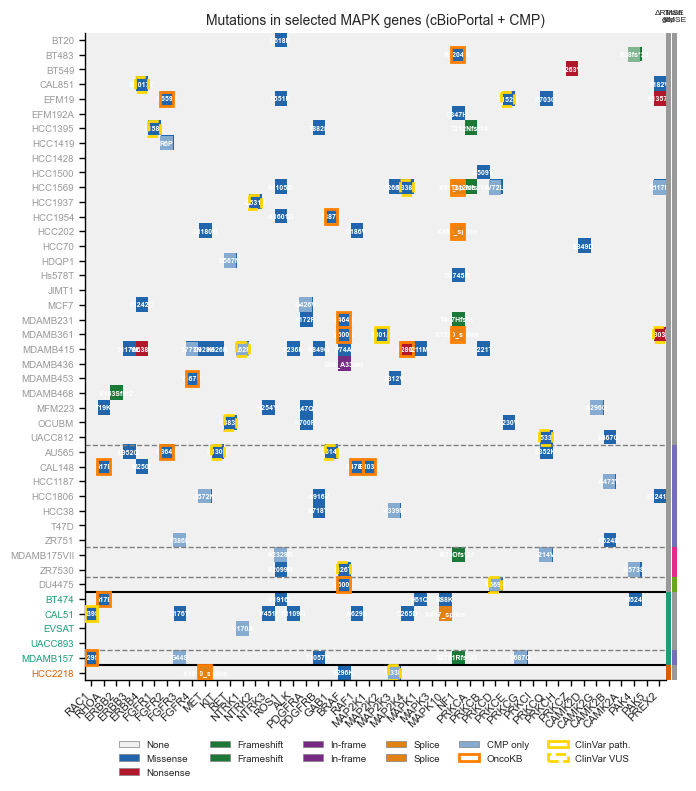

In [15]:
# ---------------------------------------------------------------------------
# Heatmap: subgroups × mutations in selected MAPK genes
# Two independent color strips: ΔRMSE gap subgroups + train RMSE subgroups
# Combines cBioPortal + CMP (COSMIC/Sanger) mutation data
# ---------------------------------------------------------------------------
import matplotlib.colors as mcolors

_TARGET_GENES = ["RAC1", "RHOA"] + ["ERBB2", "ERBB3", "ERBB4", "FGFR1", "FGFR2", "FGFR3", "FGFR4", "MET", "KIT", "RET", "NTRK1", "NTRK2", "NTRK3", "ROS1", "ALK", "PDGFRA", "PDGFRB"] + ["GAB1", "BRAF", "RAF1", "MAP2K1", "MAP2K2", "MAP2K3", "MAP2K4", "MAPK1", "MAPK3", "MAPK10", "NF1"] + ["PRKCA", "PRKCB", "PRKCD", "PRKCE", "PRKCG", "PRKCI", "PRKCQ", "PRKCH", "PRKCZ", "CAMK2D", "CAMK2G", "CAMK2B", "CAMK2A", "PAK4", "PAK5", "PREX2"]

_cbio = D.cbio_df.copy()
_all_cls_sorted = sorted(D.covered_cls)

# ── Load CMP mutations ────────────────────────────────────────────────
import json as _json
_ids_cache = _json.loads(
    (features_dir / ".annotation_cache" / "cellosaurus_ids_v2.json").read_text()
)
_cl_to_sidm = _ids_cache.get("cl_to_sidm", {})

import cell_line_annotations as _cla
_cmp_raw = _cla.fetch_cmp_mutations(
    list(D.covered_cls), _cl_to_sidm, cache_dir=features_dir,
)

# Map CMP effect → _MUT_TYPE_MAP code
_CMP_EFFECT_MAP = {
    "missense": 1, "nonsense": 2,
    "frameshift": 3, "inframe_insertion": 4, "inframe_deletion": 4,
    "ess_splice": 5, "splice_region": 5,
}

# Normalise CMP proteinChange: strip "p." prefix
_cmp = _cmp_raw[_cmp_raw["gene"].isin(_TARGET_GENES)].copy()
_cmp["pc_norm"] = _cmp["proteinChange"].str.replace(r"^p\.", "", regex=True)
_cmp["mut_code"] = _cmp["effect"].map(_CMP_EFFECT_MAP).fillna(0).astype(int)
# Only keep mutations with a known effect type AND informative protein change
_cmp = _cmp[(_cmp["mut_code"] > 0) & ~_cmp["pc_norm"].isin(["-", "?", ""])]

# ── Query novel CMP mutations against OncoKB / ClinVar ───────────────
_cmp_novel_pairs = set(
    _cmp[["gene", "pc_norm"]].dropna().apply(tuple, axis=1)
) - set(oncokb_annotations.keys()) - set(clinvar_annotations.keys())
# Filter out entries with "?" or empty proteinChange
_cmp_novel_pairs = {(g, pc) for g, pc in _cmp_novel_pairs if pc and pc != "?"}

if _cmp_novel_pairs:
    import time
    _ONCOKB_TOKEN = "5f52790a-870f-4665-ade6-8b8a0821e01b"
    _ONCOKB_URL = "https://www.oncokb.org/api/v1/annotate/mutations/byProteinChange"
    _ONCOKB_HEADERS = {
        "Authorization": f"Bearer {_ONCOKB_TOKEN}",
        "Accept": "application/json",
    }
    _base_search = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
    _base_summary = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

    print(f"Querying {len(_cmp_novel_pairs)} novel CMP mutations against OncoKB + ClinVar ...")
    for _i, (_g, _pc) in enumerate(sorted(_cmp_novel_pairs)):
        # ClinVar
        _cv_query = f'{_g}[gene] AND {_pc}'
        try:
            _r = requests.get(_base_search, params={
                "db": "clinvar", "term": _cv_query, "retmode": "json"
            }, timeout=15)
            _ids = _r.json().get("esearchresult", {}).get("idlist", [])
            if _ids:
                _r2 = requests.get(_base_summary, params={
                    "db": "clinvar", "id": ",".join(_ids), "retmode": "xml"
                }, timeout=15)
                _root = ET.fromstring(_r2.text)
                for _doc in _root.iter("DocumentSummary"):
                    _sig_el = (_doc.find("germline_classification")
                               or _doc.find("clinical_significance"))
                    if _sig_el is not None:
                        _desc = _sig_el.findtext("description", "")
                        if _desc:
                            clinvar_annotations[(_g, _pc)] = _desc
                            break
        except Exception:
            pass

        # OncoKB
        try:
            _alt = _pc.lstrip("p.")
            _r_okb = requests.get(_ONCOKB_URL, params={
                "hugoSymbol": _g, "alteration": _alt,
            }, headers=_ONCOKB_HEADERS, timeout=15)
            if _r_okb.status_code == 200:
                _result = _r_okb.json()
                _oncogenic = _result.get("oncogenic", "")
                if _oncogenic:
                    oncokb_annotations[(_g, _pc)] = _oncogenic
        except Exception:
            pass

        time.sleep(0.25)
        if (_i + 1) % 20 == 0:
            print(f"  {_i + 1}/{len(_cmp_novel_pairs)} done")

    # Refresh derived sets
    clinvar_pathogenic = {k for k, v in clinvar_annotations.items() if "pathogenic" in v.lower()}
    clinvar_vus = {k for k, v in clinvar_annotations.items() if "uncertain" in v.lower()}
    oncokb_set = {
        k for k, v in oncokb_annotations.items()
        if v.lower() in ("oncogenic", "likely oncogenic")
    }
    print(f"  Done. OncoKB oncogenic: {len(oncokb_set)}, "
          f"ClinVar pathogenic: {len(clinvar_pathogenic)}, VUS: {len(clinvar_vus)}")

    # Update cache
    import pickle as _pkl
    from pathlib import Path as _Path
    _ANNOT_CACHE = _Path(_project_root) / "figures_paper" / ".annotation_cache.pkl"
    _pkl.dump({
        "snp_queries": snp_queries,
        "clinvar_annotations": clinvar_annotations,
        "clinvar_pathogenic": clinvar_pathogenic,
        "clinvar_vus": clinvar_vus,
        "oncokb_annotations": oncokb_annotations,
        "oncokb_set": oncokb_set,
    }, open(_ANNOT_CACHE, "wb"))
    print(f"  Updated annotation cache → {_ANNOT_CACHE}")
else:
    print("All CMP mutations already queried against OncoKB / ClinVar")

# Per-cell-line subgroup lookups (both kept independently)
_cl_gap_sg = {cl: gap_subgroups_full.get(cl, "low gap") for cl in _all_cls_sorted}
_cl_rmse_sg = {cl: train_rmse_subgroups.get(cl.replace("c", "", 1), "other")
               for cl in _all_cls_sorted}

# Sort by gap subgroup order, then train RMSE order, then alphabetically
_gap_order_map = {sg: i for i, sg in enumerate(_SUBGROUP_ORDER)}
_rmse_order_map = {sg: i for i, sg in enumerate(_TRAIN_RMSE_ORDER)}

_sorted_cls = sorted(
    _all_cls_sorted,
    key=lambda cl: (_gap_order_map.get(_cl_gap_sg[cl], 99),
                    _rmse_order_map.get(_cl_rmse_sg[cl], 99),
                    cl))

# Build mutation type matrix — start with cBioPortal
_mut_mat = pd.DataFrame(0, index=_sorted_cls, columns=_TARGET_GENES)
_pchange_mat = pd.DataFrame("", index=_sorted_cls, columns=_TARGET_GENES)
_source_mat = pd.DataFrame("", index=_sorted_cls, columns=_TARGET_GENES)

for (cl, gene), sub in _cbio[_cbio["gene"].isin(_TARGET_GENES)].groupby(["cell_line", "gene"]):
    if cl not in _mut_mat.index:
        continue
    best_code = 0
    best_pc = ""
    for _, row in sub.iterrows():
        mt = row.get("mutationType", "")
        code = _MUT_TYPE_MAP.get(mt, 6 if pd.notna(mt) and mt != "" else 0)
        if code > best_code:
            best_code = code
            pc = row.get("proteinChange", "")
            best_pc = pc if pd.notna(pc) else ""
    _mut_mat.loc[cl, gene] = best_code
    _pchange_mat.loc[cl, gene] = best_pc
    _source_mat.loc[cl, gene] = "cbio"

# Overlay CMP mutations — fill in blanks
_n_cmp_new = 0
_n_cmp_confirm = 0
for (cl, gene), sub in _cmp.groupby(["cell_line", "gene"]):
    if cl not in _mut_mat.index:
        continue
    best_code_cmp = 0
    best_pc_cmp = ""
    for _, row in sub.iterrows():
        if row["mut_code"] > best_code_cmp:
            best_code_cmp = row["mut_code"]
            best_pc_cmp = row["pc_norm"] if pd.notna(row["pc_norm"]) else ""
    existing = _mut_mat.loc[cl, gene]
    if existing == 0 and best_code_cmp > 0:
        _mut_mat.loc[cl, gene] = best_code_cmp
        _pchange_mat.loc[cl, gene] = best_pc_cmp
        _source_mat.loc[cl, gene] = "cmp"
        _n_cmp_new += 1
    elif existing > 0 and best_code_cmp > 0:
        _n_cmp_confirm += 1

print(f"CMP overlay: {_n_cmp_new} new entries added, {_n_cmp_confirm} confirmed")

# Clean display labels (remove leading 'c')
_display_labels = [cl.replace("c", "", 1) for cl in _sorted_cls]
_mut_mat.index = _display_labels
_pchange_mat.index = _display_labels
_source_mat.index = _display_labels

# Gap subgroup per row (primary grouping for separators)
_gap_for_display = [_cl_gap_sg[cl] for cl in _sorted_cls]
_rmse_for_display = [_cl_rmse_sg[cl] for cl in _sorted_cls]

# Find gap subgroup boundary positions for separator lines
_sg_boundaries = []
for i in range(1, len(_gap_for_display)):
    if _gap_for_display[i] != _gap_for_display[i - 1]:
        _sg_boundaries.append(i - 0.5)

# Midpoints for gap subgroup labels
_present_gap_sgs = [sg for sg in _SUBGROUP_ORDER
                    if any(s == sg for s in _gap_for_display)]
_gap_mid = {}
for sg in _present_gap_sgs:
    indices = [i for i, s in enumerate(_gap_for_display) if s == sg]
    if indices:
        _gap_mid[sg] = (indices[0] + indices[-1]) / 2.0

# --- Lighter colors for CMP-only mutations (blend toward white) ---
def _lighten(hex_color, factor=0.45):
    rgb = mcolors.to_rgb(hex_color)
    return tuple(v + factor * (1.0 - v) for v in rgb)

_MUT_TYPE_COLORS_CMP = [_lighten(c) for c in _MUT_TYPE_COLORS]

# --- Plot ---
_STRIP_WIDTH = 0.4
_COLOR_ONCOKB = "#ff7f00"
_COLOR_CLINVAR = "gold"

_cmap_hm = ListedColormap(_MUT_TYPE_COLORS)
_norm_hm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], _cmap_hm.N)

fig_mut, ax_mut = plt.subplots(
    figsize=(7, max(3, len(_sorted_cls) * 0.18)))

ax_mut.imshow(_mut_mat.values, aspect="auto", cmap=_cmap_hm, norm=_norm_hm,
              interpolation="nearest")

# Overlay CMP-only cells with lighter fill color
for i in range(len(_mut_mat)):
    for j in range(len(_TARGET_GENES)):
        if _source_mat.iloc[i, j] == "cmp" and _mut_mat.iloc[i, j] > 0:
            code = _mut_mat.iloc[i, j]
            ax_mut.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                facecolor=_MUT_TYPE_COLORS_CMP[code],
                edgecolor="none", zorder=1.5))

# Annotate cells with protein change + OncoKB/ClinVar borders
_has_oncokb = False
_has_cv_path = False
_has_cv_vus = False
_has_cmp_src = False
for i in range(len(_mut_mat)):
    for j in range(len(_TARGET_GENES)):
        val = _mut_mat.iloc[i, j]
        pc = _pchange_mat.iloc[i, j]
        src = _source_mat.iloc[i, j]
        if val > 0 and pc:
            # Text label
            ax_mut.text(j, i, pc, ha="center", va="center",
                        fontsize=max(FONTSIZE - 3, 4), color="white",
                        fontweight="bold", clip_on=True)
            gene = _TARGET_GENES[j]
            # OncoKB / ClinVar borders (applied to both sources)
            if (gene, pc) in oncokb_set:
                ax_mut.add_patch(plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    facecolor="none", edgecolor=_COLOR_ONCOKB,
                    linewidth=2.0, zorder=3))
                _has_oncokb = True
            elif (gene, pc) in clinvar_pathogenic:
                ax_mut.add_patch(plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    facecolor="none", edgecolor=_COLOR_CLINVAR,
                    linewidth=2.0, zorder=3))
                _has_cv_path = True
            elif (gene, pc) in clinvar_vus:
                ax_mut.add_patch(plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    facecolor="none", edgecolor=_COLOR_CLINVAR,
                    linewidth=2.0, linestyle="--", zorder=3))
                _has_cv_vus = True
        # Track CMP source for legend
        if src == "cmp" and val > 0:
            _has_cmp_src = True

# Gap subgroup separator lines
for boundary in _sg_boundaries:
    ax_mut.axhline(boundary, color="black", lw=LW_THICK, linestyle="-")

# Train RMSE subgroup separator lines (thinner, within each gap group)
_rmse_boundaries = []
for i in range(1, len(_rmse_for_display)):
    if (_rmse_for_display[i] != _rmse_for_display[i - 1]
            and (i - 0.5) not in _sg_boundaries):
        _rmse_boundaries.append(i - 0.5)
for boundary in _rmse_boundaries:
    ax_mut.axhline(boundary, color="grey", lw=LW_MEDIUM, linestyle="--")

# Two color strips on the right (gap + train RMSE)
_n_cols = len(_TARGET_GENES)
_x_gap = _n_cols - 0.5 + 0.05
_x_rmse = _x_gap + _STRIP_WIDTH + 0.05
for i, cl in enumerate(_sorted_cls):
    ax_mut.add_patch(plt.Rectangle(
        (_x_gap, i - 0.5), _STRIP_WIDTH, 1,
        facecolor=_SUBGROUP_COLORS.get(_cl_gap_sg[cl], "#d9d9d9"),
        edgecolor="none", clip_on=False))
    ax_mut.add_patch(plt.Rectangle(
        (_x_rmse, i - 0.5), _STRIP_WIDTH, 1,
        facecolor=_TRAIN_RMSE_COLORS.get(_cl_rmse_sg[cl], "#d9d9d9"),
        edgecolor="none", clip_on=False))

# Strip titles above
ax_mut.text(_x_gap + _STRIP_WIDTH / 2, -1.2, "ΔRMSE\ngap",
            ha="center", va="bottom", fontsize=FONTSIZE - 2, clip_on=False)
ax_mut.text(_x_rmse + _STRIP_WIDTH / 2, -1.2, "Train\nRMSE",
            ha="center", va="bottom", fontsize=FONTSIZE - 2, clip_on=False)

# Y-tick colors from gap subgroup
_ytick_colors = [_SUBGROUP_COLORS.get(sg, "black") for sg in _gap_for_display]

# Axes formatting
ax_mut.set_yticks(range(len(_display_labels)))
ax_mut.set_yticklabels(_display_labels, fontsize=FONTSIZE - 1)
for tl, c in zip(ax_mut.get_yticklabels(), _ytick_colors):
    tl.set_color(c)

ax_mut.set_xticks(range(len(_TARGET_GENES)))
ax_mut.set_xticklabels(_TARGET_GENES, rotation=45, ha="right", fontsize=FONTSIZE)
ax_mut.tick_params(which="both", length=0)
ax_mut.grid(False)
ax_mut.set_title("Mutations in selected MAPK genes (cBioPortal + CMP)",
                 fontsize=FONTSIZE_HEADING)
configure_axis_spines(ax_mut)

# Legend — mutation types (saturated = cBio, light = CMP) + annotation borders
_legend_handles = [Patch(facecolor=_MUT_TYPE_COLORS[v], edgecolor="grey",
                         linewidth=LW_THIN, label=_MUT_TYPE_LABELS[v])
                   for v in sorted(_MUT_TYPE_MAP.values()) if v in _mut_mat.values]
if 0 in _mut_mat.values:
    _legend_handles.insert(0, Patch(facecolor=_MUT_TYPE_COLORS[0], edgecolor="grey",
                                    linewidth=LW_THIN, label="None"))
# CMP lighter swatch in legend
if _has_cmp_src:
    _legend_handles.append(Patch(facecolor=_MUT_TYPE_COLORS_CMP[1], edgecolor="grey",
                                 linewidth=LW_THIN, label="CMP only"))
if _has_oncokb:
    _legend_handles.append(Patch(facecolor="none", edgecolor=_COLOR_ONCOKB,
                                 linewidth=2.0, label="OncoKB"))
if _has_cv_path:
    _legend_handles.append(Patch(facecolor="none", edgecolor=_COLOR_CLINVAR,
                                 linewidth=2.0, label="ClinVar path."))
if _has_cv_vus:
    _legend_handles.append(Patch(facecolor="none", edgecolor=_COLOR_CLINVAR,
                                 linewidth=2.0, linestyle="--", label="ClinVar VUS"))
ax_mut.legend(handles=_legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.08), ncol=min(len(_legend_handles), 6),
              fontsize=FONTSIZE - 1, frameon=False)

# Print group counts
from collections import Counter as _Counter
_gap_counts = _Counter(_gap_for_display)
_rmse_counts = _Counter(_rmse_for_display)
print("Gap subgroup counts:")
for sg in _present_gap_sgs:
    print(f"  {sg}: {_gap_counts.get(sg, 0)}")
print("Train RMSE subgroup counts:")
for sg in _TRAIN_RMSE_ORDER:
    if _rmse_counts.get(sg, 0):
        print(f"  {sg}: {_rmse_counts[sg]}")

# Print CMP-only mutations and their annotations
_cmp_entries = []
for i in range(len(_source_mat)):
    for j in range(len(_TARGET_GENES)):
        if _source_mat.iloc[i, j] == "cmp":
            g = _TARGET_GENES[j]
            pc = _pchange_mat.iloc[i, j]
            annot = ""
            if (g, pc) in oncokb_set:
                annot = " [OncoKB]"
            elif (g, pc) in clinvar_pathogenic:
                annot = " [ClinVar path.]"
            elif (g, pc) in clinvar_vus:
                annot = " [ClinVar VUS]"
            _cmp_entries.append(f"  {_display_labels[i]}: {g} {pc}{annot}")
if _cmp_entries:
    print(f"\nCMP-only mutations added ({len(_cmp_entries)}):")
    for e in _cmp_entries:
        print(e)

fig_mut.tight_layout()
plt.show()

CMP overlay applied to SNP heatmap
mmc2 overlay applied to SNP heatmap (4 new hits)
SNP heatmap: 9 SNPs x 58 cell lines (12 without mutation data), 13 hits
  RAC1 N39S: 1 — CAL51 [cbio+cmp]
  RAC1 P29S: 1 — MDAMB157 [cbio]
  RHOA G17E: 2 — CAL148 [cbio+cmp], BT474 [cbio+cmp]
  KRAS G12/13: 2 — MDAMB231 [cbio+cmp+mmc2], MPE600 [mmc2]
  MET N375S: 2 — UACC893 [mmc2], HCC2218 [mmc2]
  MET Δex14: 1 — HCC2218 [cbio+cmp]
  BRAF V600E: 2 — MDAMB361 [cbio], DU4475 [cbio+cmp]
  RAF1 S478K: 1 — CAL148 [cbio+cmp]
  MAP2K1 E203K: 1 — CAL148 [cbio+cmp]


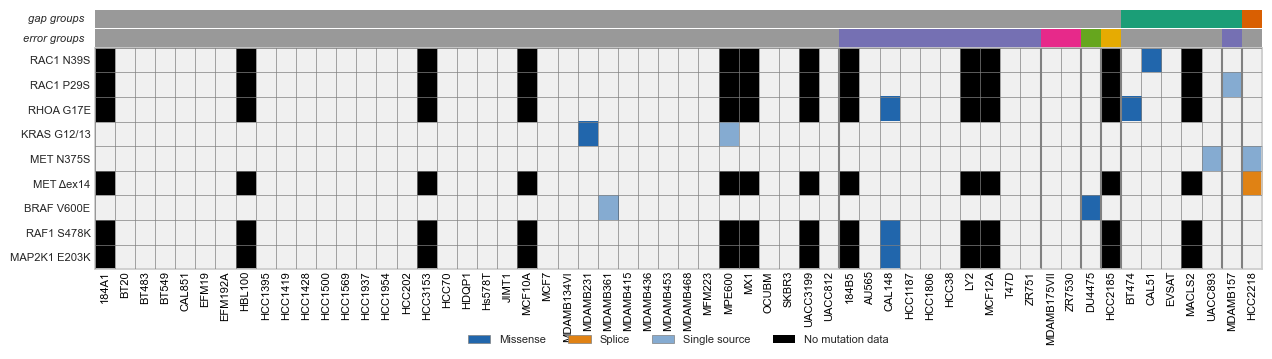

In [16]:
# ---------------------------------------------------------------------------
# Heatmap: selected SNPs (Y axis) × cell lines (X axis, same ordering)
# Combines cBioPortal + CMP (COSMIC) + mmc2 data
# Full-saturation color = confirmed by 2+ sources (consistent)
# Light-saturation color = single source only (unconfirmed)
# Black cell = no mutation data available (skipped for universally-sequenced genes)
# pc_target may be a str or tuple of strs (→ combined row / isoform aliases)
# ---------------------------------------------------------------------------
import matplotlib.colors as _mcolors_snp

_TARGET_SNPS = [
    ("RAC1", "N39S"),
    ("RAC1", "P29S"),
    ("RHOA", "G17E"),
    ("KRAS", ("G12V", "G12C", "G13D")),
    # ("NRAS", "Q61R"),
    ("MET", "N375S"),
    ("MET", "X1010_splice"),
    ("BRAF", "V600E"),
    # ("BRAF", "G464V"),
    ("RAF1", ("S478K", "E478K", "E498K")),  # same mutation, different isoform numbering
    ("MAP2K1", "E203K"),
]

# Display labels (override defaults where needed)
_SNP_DISPLAY = {
    ("MET", "X1010_splice"):                   "MET Δex14",
    ("KRAS", ("G12V", "G12C", "G13D")):        "KRAS G12/13",
    ("RAF1", ("S478K", "E478K", "E498K")):     "RAF1 S478K",
}

def _snp_default_label(g, pc):
    if isinstance(pc, tuple):
        return f"{g} " + "/".join(pc)
    return f"{g} {pc}"

_snp_labels = [_SNP_DISPLAY.get((g, pc), _snp_default_label(g, pc))
               for g, pc in _TARGET_SNPS]

# Rows for which "no mutation data" hatching is suppressed (gene universally sequenced)
_NO_HATCH_LABELS = {"KRAS G12/13", "MET N375S", "BRAF V600E"}

# Helper: normalise pc_target to a frozenset for membership testing
def _pc_set(pc_target):
    return frozenset((pc_target,) if isinstance(pc_target, str) else pc_target)

_cbio2 = D.cbio_df.copy()

# Use ALL cell lines (including those without mutation data)
_all_cls_full = sorted(gap_subgroups_full.keys())

# Identify cell lines with data in each source
_cls_with_cbio = set(_cbio2["cell_line"].unique())
try:
    _cls_with_cmp2 = set(_cmp_raw["cell_line"].unique())
except NameError:
    _cls_with_cmp2 = set()
# A cell line is "missing" only when it has no data in either source
_cls_missing_mut = {cl for cl in _all_cls_full
                    if cl not in _cls_with_cbio and cl not in _cls_with_cmp2}

# Count available data modalities per cell line (mutation, phospho, prot, trans)
_cls_with_phospho = set(D.phospho_mat.index)
_cls_with_prot = set(D.prot_mat.index)
_cls_with_trans = set(D.trans_mat.index)
_cl_n_modalities = {
    cl: sum([cl in _cls_with_cbio or cl in _cls_with_cmp2,
             cl in _cls_with_phospho,
             cl in _cls_with_prot,
             cl in _cls_with_trans])
    for cl in _all_cls_full
}

# Per-cell-line subgroup lookups
_cl_gap_sg2 = {cl: gap_subgroups_full.get(cl, "low gap") for cl in _all_cls_full}
_cl_rmse_sg2 = {cl: train_rmse_subgroups.get(cl.replace("c", "", 1), "other")
                for cl in _all_cls_full}

# Sort by gap subgroup order, then train RMSE order, then alphabetically
_gap_order_map2 = {sg: i for i, sg in enumerate(_SUBGROUP_ORDER)}
_rmse_order_map2 = {sg: i for i, sg in enumerate(_TRAIN_RMSE_ORDER)}

_sorted_cls2 = sorted(
    _all_cls_full,
    key=lambda cl: (_gap_order_map2.get(_cl_gap_sg2[cl], 99),
                    _rmse_order_map2.get(_cl_rmse_sg2[cl], 99),
                    cl))

# Build SNP value matrix and per-source boolean matrices
_snp_mat = pd.DataFrame(0, index=_snp_labels, columns=_sorted_cls2)
_snp_cbio_found = pd.DataFrame(False, index=_snp_labels, columns=_sorted_cls2)
_snp_cmp_found  = pd.DataFrame(False, index=_snp_labels, columns=_sorted_cls2)
_snp_mmc2_found = pd.DataFrame(False, index=_snp_labels, columns=_sorted_cls2)

# ── Populate from cBioPortal ─────────────────────────────────────────
for si, (gene, pc_target) in enumerate(_TARGET_SNPS):
    label = _snp_labels[si]
    _pcs = _pc_set(pc_target)
    _is_splice = isinstance(pc_target, str) and "splice" in pc_target.lower()
    for cl in _sorted_cls2:
        sub = _cbio2[(_cbio2["cell_line"] == cl) & (_cbio2["gene"] == gene)]
        for _, row in sub.iterrows():
            pc_val = row.get("proteinChange", "")
            mt = row.get("mutationType", "")
            if pd.notna(pc_val) and pc_val in _pcs:
                code = _MUT_TYPE_MAP.get(mt, 6 if pd.notna(mt) and mt != "" else 0)
                if code > _snp_mat.loc[label, cl]:
                    _snp_mat.loc[label, cl] = code
                _snp_cbio_found.loc[label, cl] = True
            elif gene == "MET" and _is_splice:
                if pd.notna(mt) and "Splice" in mt:
                    pc_check = pc_val if pd.notna(pc_val) else ""
                    if "1010" in pc_check or _is_splice:
                        code = _MUT_TYPE_MAP.get(mt, 5)
                        if code > _snp_mat.loc[label, cl]:
                            _snp_mat.loc[label, cl] = code
                        _snp_cbio_found.loc[label, cl] = True

# ── Overlay CMP (COSMIC) mutations ───────────────────────────────────
_CMP_SNP_EFFECT_MAP = {
    "missense": 1, "nonsense": 2, "frameshift": 3,
    "inframe_insertion": 4, "inframe_deletion": 4,
    "ess_splice": 5, "splice_region": 5,
}
_cmp_snp_available = False
try:
    _cmp_for_snp = _cmp_raw.copy()
    _cmp_for_snp["pc_norm"] = _cmp_for_snp["proteinChange"].str.replace(r"^p\.", "", regex=True)
    _cmp_for_snp["mut_code"] = (_cmp_for_snp["effect"]
                                 .map(_CMP_SNP_EFFECT_MAP)
                                 .fillna(6).astype(int))

    for si, (gene, pc_target) in enumerate(_TARGET_SNPS):
        label = _snp_labels[si]
        _pcs = _pc_set(pc_target)
        _is_splice = isinstance(pc_target, str) and "splice" in pc_target.lower()
        sub_gene = _cmp_for_snp[_cmp_for_snp["gene"] == gene]
        for cl in _sorted_cls2:
            sub_cl = sub_gene[sub_gene["cell_line"] == cl]
            best_cmp_code = 0
            for _, row in sub_cl.iterrows():
                pc_norm = str(row.get("pc_norm", "") or "")
                effect = str(row.get("effect", "") or "")
                if pc_norm in _pcs:
                    best_cmp_code = max(best_cmp_code, int(row["mut_code"]))
                elif gene == "MET" and _is_splice:
                    if "splice" in effect.lower():
                        best_cmp_code = max(best_cmp_code, int(row["mut_code"]))
            if best_cmp_code > 0:
                if best_cmp_code > _snp_mat.loc[label, cl]:
                    _snp_mat.loc[label, cl] = best_cmp_code
                _snp_cmp_found.loc[label, cl] = True

    _cmp_snp_available = True
    print("CMP overlay applied to SNP heatmap")
except NameError:
    print("Warning: _cmp_raw not available; SNP heatmap shows cBioPortal only")

# ── Overlay mmc2 (Marcotte et al. exome sequencing, sheet S1C) ───────
_mmc2_raw = pd.read_excel(
    Path(_project_root) / "figures_paper" / "mmc2.xlsx",
    sheet_name="S1C",
    header=None,
)

_mmc2_header = [
    str(v).strip() if pd.notna(v) else f"__col{i}"
    for i, v in enumerate(_mmc2_raw.iloc[3])
]
_mmc2_df = _mmc2_raw.iloc[4:].reset_index(drop=True)
_mmc2_df.columns = _mmc2_header
_mmc2_df = _mmc2_df.rename(columns={_mmc2_df.columns[0]: "_cell_line"})
_mmc2_df["_cl_norm"] = "c" + _mmc2_df["_cell_line"].astype(str).str.strip().str.upper()
# Remap cell lines where mmc2 uses a different name ordering than the dataset
_MMC2_CL_REMAP = {"c600MPE": "cMPE600"}
_mmc2_df["_cl_norm"] = _mmc2_df["_cl_norm"].map(lambda x: _MMC2_CL_REMAP.get(x, x))

_mmc2_hits = 0
for si, (gene, pc_target) in enumerate(_TARGET_SNPS):
    label = _snp_labels[si]
    if gene not in _mmc2_df.columns:
        continue
    _pcs = _pc_set(pc_target)
    for cl in _sorted_cls2:
        row_mask = _mmc2_df["_cl_norm"] == cl
        if not row_mask.any():
            continue
        cell_val = str(_mmc2_df.loc[row_mask, gene].iloc[0])
        if any(f"p.{pct}" in cell_val for pct in _pcs):
            if not _snp_mmc2_found.loc[label, cl]:
                _mmc2_hits += 1
            if _snp_mat.loc[label, cl] == 0:
                _snp_mat.loc[label, cl] = 1  # missense
            _snp_mmc2_found.loc[label, cl] = True

print(f"mmc2 overlay applied to SNP heatmap ({_mmc2_hits} new hits)")

# Derived: number of confirming sources per (SNP, cell line)
_snp_nsources_mat = (_snp_cbio_found.astype(int)
                     + _snp_cmp_found.astype(int)
                     + _snp_mmc2_found.astype(int))

# Helper: source string for printout
def _src_str(label, cl):
    parts = []
    if _snp_cbio_found.loc[label, cl]: parts.append("cbio")
    if _snp_cmp_found.loc[label, cl]:  parts.append("cmp")
    if _snp_mmc2_found.loc[label, cl]: parts.append("mmc2")
    return "+".join(parts) if parts else ""

# Display labels (remove leading 'c') — used for axis tick labels only
_snp_display_cols = [cl.replace("c", "", 1) for cl in _sorted_cls2]

# Gap + RMSE subgroup info for X axis (cell lines)
_gap_for_x = [_cl_gap_sg2[cl] for cl in _sorted_cls2]
_rmse_for_x = [_cl_rmse_sg2[cl] for cl in _sorted_cls2]

# Gap subgroup boundary positions (vertical)
_sg_vbounds = []
for i in range(1, len(_gap_for_x)):
    if _gap_for_x[i] != _gap_for_x[i - 1]:
        _sg_vbounds.append(i - 0.5)

# Train RMSE boundaries (within gap groups)
_rmse_vbounds = []
for i in range(1, len(_rmse_for_x)):
    if (_rmse_for_x[i] != _rmse_for_x[i - 1]
            and (i - 0.5) not in _sg_vbounds):
        _rmse_vbounds.append(i - 0.5)

# --- Lighter colors for single-source mutations (blend toward white) ------
def _lighten_snp(hex_color, factor=0.45):
    rgb = _mcolors_snp.to_rgb(hex_color)
    return tuple(v + factor * (1.0 - v) for v in rgb)

_MUT_TYPE_COLORS_CMP_SNP = [_lighten_snp(c) for c in _MUT_TYPE_COLORS]

# --- Setup ---
_STRIP_HEIGHT = 1.0
_cmap_hm2 = ListedColormap(_MUT_TYPE_COLORS)
_norm_hm2 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], _cmap_hm2.N)


def plot_panel_snp_heatmap(ax, *, show_legend=True):
    """Plot selected-SNP × cell-line heatmap on a given axes.

    Full-saturation fill  = confirmed by 2+ sources (consistent).
    Light-saturation fill = single source only (unconfirmed).
    Black cell            = no mutation data in any source
                            (suppressed for universally-sequenced rows).
    """
    ax.imshow(_snp_mat.values, aspect="auto", cmap=_cmap_hm2, norm=_norm_hm2,
              interpolation="nearest",
              extent=(-0.5, len(_snp_display_cols) - 0.5,
                      len(_snp_labels) - 0.5, -0.5))

    # Overlay single-source cells with lighter fill
    _has_single_src = False
    for i, label in enumerate(_snp_labels):
        for j, cl in enumerate(_sorted_cls2):
            code = int(_snp_mat.values[i, j])
            n_src = int(_snp_nsources_mat.loc[label, cl])
            if code > 0 and n_src < 2:
                ax.add_patch(plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    facecolor=_MUT_TYPE_COLORS_CMP_SNP[code],
                    edgecolor="none", zorder=1.5))
                _has_single_src = True

    # Fill with black for missing mutation data, skipping universally-sequenced rows
    _has_missing = False
    for j, cl in enumerate(_sorted_cls2):
        if cl in _cls_missing_mut:
            for i, label in enumerate(_snp_labels):
                if label not in _NO_HATCH_LABELS:
                    ax.add_patch(plt.Rectangle(
                        (j - 0.5, i - 0.5), 1, 1,
                        facecolor="black", edgecolor="none", linewidth=0,
                        zorder=2, clip_on=True))
                    _has_missing = True

    # Subgroup separator lines (vertical)
    for boundary in _rmse_vbounds + _sg_vbounds:
        ax.axvline(boundary, color="grey", lw=LW_THICK, linestyle="-")
    
    _hm_draw_color_strips(ax, _sorted_cls2, [
        (_cl_rmse_sg2, _TRAIN_RMSE_COLORS),
        (_cl_gap_sg2, _SUBGROUP_COLORS),
    ], labels=["error groups", "gap groups"], offset_x=-0.5)

    # X-ticks: plain black, no per-cell-line coloring or italic
    ax.set_xticks(range(len(_snp_display_cols)))
    ax.set_xticklabels(_snp_display_cols, rotation=90, ha="center",
                       fontsize=FONTSIZE, color="black")

    ax.set_yticks(range(len(_snp_labels)))
    ax.set_yticklabels(_snp_labels, fontsize=FONTSIZE)
    # Remove tick marks (bottom=False / left=False is more reliable than length=0)
    ax.tick_params(axis="x", bottom=False, pad=-5)
    ax.tick_params(axis="y", left=False, pad=-3)
    # Minor ticks at cell boundaries → thin white grid lines for rows and columns
    _n_cols = len(_snp_display_cols)
    _n_rows = len(_snp_labels)
    ax.set_xticks(np.arange(-0.5, _n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, _n_rows, 1), minor=True)
    ax.tick_params(axis="both", which="minor", length=0)
    ax.grid(which="minor", color="grey", linewidth=LW_THIN, linestyle="-")
    ax.grid(which="major", visible=False)
    ax.set_axisbelow(False)

    if show_legend:
        _present_codes = sorted(set(int(x) for x in _snp_mat.values.flatten() if x > 0))
        _legend_handles2 = [Patch(facecolor=_MUT_TYPE_COLORS[v], edgecolor="grey",
                                  linewidth=LW_THIN, label=_MUT_TYPE_LABELS[v])
                            for v in _present_codes]
        if _has_single_src:
            _legend_handles2.append(Patch(
                facecolor=_MUT_TYPE_COLORS_CMP_SNP[1], edgecolor="grey",
                linewidth=LW_THIN, label="Single source"))
        if _has_missing:
            _legend_handles2.append(Patch(facecolor="black", edgecolor="none",
                                          linewidth=0,
                                          label="No mutation data"))
        ax.legend(handles=_legend_handles2, loc="upper center",
                  bbox_to_anchor=(0.5, -0.25), ncol=min(len(_legend_handles2), 7),
                  fontsize=FONTSIZE, frameon=False)


# --- Standalone plot ---
fig_mut2, ax_mut2 = plt.subplots(
    figsize=(max(8, len(_sorted_cls2) * 0.22), 4.0))
plot_panel_snp_heatmap(ax_mut2)
fig_mut2.tight_layout()

# Print summary
_n_hits = (_snp_mat.values > 0).sum()
_n_missing = len(_cls_missing_mut)
print(f"SNP heatmap: {len(_snp_labels)} SNPs x {len(_sorted_cls2)} cell lines "
      f"({_n_missing} without mutation data), {_n_hits} hits")
for i, label in enumerate(_snp_labels):
    n = (_snp_mat.values[i] > 0).sum()
    cls_with = [
        (disp, _src_str(label, cl))
        for disp, cl, v in zip(_snp_display_cols, _sorted_cls2, _snp_mat.values[i])
        if v > 0
    ]
    print(f"  {label}: {n} — " + ", ".join(f"{c} [{s}]" for c, s in cls_with))

plt.show()


In [17]:
# ---------------------------------------------------------------------------
# Fetch CMP (COSMIC) mutations and compare to cBioPortal
# ---------------------------------------------------------------------------
import importlib, json, sys
sys.path.insert(0, str(Path("..").resolve()))
import cell_line_annotations as cla
importlib.reload(cla)

# Load cl_to_sidm from the cellosaurus ID cache
_ids_cache = json.loads(
    (features_dir / ".annotation_cache" / "cellosaurus_ids_v2.json").read_text()
)
_cl_to_sidm = _ids_cache.get("cl_to_sidm", {})

_cmp_df = cla.fetch_cmp_mutations(
    list(D.covered_cls),
    _cl_to_sidm,
    cache_dir=features_dir,
)

# --- Compare CMP vs cBioPortal on the overlapping cell lines ---
_cbio_comp = D.cbio_df.copy()
_common_cls = sorted(set(_cmp_df["cell_line"].unique()) & set(_cbio_comp["cell_line"].unique()))
print(f"\n{'='*60}")
print(f"CMP vs cBioPortal comparison")
print(f"{'='*60}")
print(f"Cell lines in CMP:  {_cmp_df['cell_line'].nunique()}")
print(f"Cell lines in cBio: {_cbio_comp['cell_line'].nunique()}")
print(f"Overlap:            {len(_common_cls)}")
print(f"CMP total mutations:  {len(_cmp_df)}")
print(f"cBio total mutations: {len(_cbio_comp)}")

# Normalise protein change: strip leading "p." from CMP data for matching
_cmp_comp = _cmp_df[_cmp_df["cell_line"].isin(_common_cls)].copy()
_cmp_comp["pc_norm"] = _cmp_comp["proteinChange"].str.replace(r"^p\.", "", regex=True)

_cbio_sub = _cbio_comp[_cbio_comp["cell_line"].isin(_common_cls)].copy()
_cbio_sub["pc_norm"] = _cbio_sub["proteinChange"]

# Create (cell_line, gene, proteinChange) tuples for matching
_cmp_triplets = set(
    _cmp_comp.dropna(subset=["pc_norm"])
    .apply(lambda r: (r["cell_line"], r["gene"], r["pc_norm"]), axis=1)
)
_cbio_triplets = set(
    _cbio_sub.dropna(subset=["pc_norm"])
    .apply(lambda r: (r["cell_line"], r["gene"], r["pc_norm"]), axis=1)
)

_both = _cmp_triplets & _cbio_triplets
_cmp_only = _cmp_triplets - _cbio_triplets
_cbio_only = _cbio_triplets - _cmp_triplets

print(f"\nMatching on (cell_line, gene, proteinChange):")
print(f"  Shared:    {len(_both)}")
print(f"  CMP only:  {len(_cmp_only)}")
print(f"  cBio only: {len(_cbio_only)}")
if len(_both) + len(_cmp_only) + len(_cbio_only) > 0:
    _jaccard = len(_both) / (len(_both) + len(_cmp_only) + len(_cbio_only))
    print(f"  Jaccard:   {_jaccard:.3f}")

# Per-gene overlap for the target SNP genes
_target_genes_snp = sorted({g for g, _ in _TARGET_SNPS})
print(f"\nPer-gene overlap (target SNP genes):")
for _g in _target_genes_snp:
    _g_cmp = {t for t in _cmp_triplets if t[1] == _g}
    _g_cbio = {t for t in _cbio_triplets if t[1] == _g}
    _g_both = _g_cmp & _g_cbio
    print(f"  {_g:10s}: CMP={len(_g_cmp):4d}, cBio={len(_g_cbio):4d}, "
          f"shared={len(_g_both):4d}")

# Check the specific target SNPs
print(f"\nTarget SNP concordance:")
for _g, _pc in _TARGET_SNPS:
    _label = _SNP_DISPLAY.get((_g, _pc), f"{_g} {_pc}")
    _cmp_cls = sorted({t[0] for t in _cmp_triplets if t[1] == _g and t[2] == _pc})
    _cbio_cls_set = sorted({t[0] for t in _cbio_triplets if t[1] == _g and t[2] == _pc})
    # For splice variants, also check effect-based matching in CMP
    if isinstance(_pc, str) and "splice" in _pc.lower():
        _cmp_splice = sorted(
            _cmp_comp[(_cmp_comp["gene"] == _g) &
                      (_cmp_comp["effect"].str.contains("splice", case=False, na=False))]
            ["cell_line"].unique()
        )
        _cmp_cls = sorted(set(_cmp_cls) | set(_cmp_splice))
    _shared = sorted(set(_cmp_cls) & set(_cbio_cls_set))
    _cmp_extra = sorted(set(_cmp_cls) - set(_cbio_cls_set))
    _cbio_extra = sorted(set(_cbio_cls_set) - set(_cmp_cls))
    _status = "✓" if set(_cmp_cls) == set(_cbio_cls_set) else "≠"
    _cmp_disp = [c.replace("c", "", 1) for c in _cmp_cls]
    _cbio_disp = [c.replace("c", "", 1) for c in _cbio_cls_set]
    print(f"  {_status} {_label:20s}: CMP={_cmp_disp}, cBio={_cbio_disp}")
    if _cmp_extra:
        print(f"      CMP only: {[c.replace('c','',1) for c in _cmp_extra]}")
    if _cbio_extra:
        print(f"      cBio only: {[c.replace('c','',1) for c in _cbio_extra]}")

# Gene-level agreement: for each (cell_line, gene) does at least one mutation exist?
_cmp_gene_pairs = set((t[0], t[1]) for t in _cmp_triplets)
_cbio_gene_pairs = set((t[0], t[1]) for t in _cbio_triplets)
_gene_both = _cmp_gene_pairs & _cbio_gene_pairs
_gene_cmp_only = _cmp_gene_pairs - _cbio_gene_pairs
_gene_cbio_only = _cbio_gene_pairs - _cmp_gene_pairs
print(f"\nGene-level (cell_line, gene) overlap:")
print(f"  Shared:    {len(_gene_both)}")
print(f"  CMP only:  {len(_gene_cmp_only)}")
print(f"  cBio only: {len(_gene_cbio_only)}")
if len(_gene_both) + len(_gene_cmp_only) + len(_gene_cbio_only) > 0:
    _gene_jaccard = len(_gene_both) / (len(_gene_both) + len(_gene_cmp_only) + len(_gene_cbio_only))
    print(f"  Jaccard:   {_gene_jaccard:.3f}")


  [cache hit] CMP mutations loaded from cache

CMP vs cBioPortal comparison
Cell lines in CMP:  43
Cell lines in cBio: 47
Overlap:            43
CMP total mutations:  200639
cBio total mutations: 20887

Matching on (cell_line, gene, proteinChange):
  Shared:    11380
  CMP only:  115139
  cBio only: 8463
  Jaccard:   0.084

Per-gene overlap (target SNP genes):
  BRAF      : CMP=  13, cBio=   7, shared=   5
  KRAS      : CMP=   4, cBio=   1, shared=   1
  MAP2K1    : CMP=   4, cBio=   1, shared=   1
  MET       : CMP=  10, cBio=   3, shared=   0
  RAC1      : CMP=   4, cBio=   2, shared=   1
  RAF1      : CMP=   8, cBio=   3, shared=   0
  RHOA      : CMP=   5, cBio=   3, shared=   3

Target SNP concordance:
  ✓ RAC1 N39S           : CMP=['CAL51'], cBio=['CAL51']
  ≠ RAC1 P29S           : CMP=[], cBio=['MDAMB157']
      cBio only: ['MDAMB157']
  ✓ RHOA G17E           : CMP=['BT474', 'CAL148'], cBio=['BT474', 'CAL148']
  ✓ KRAS G12/13         : CMP=[], cBio=[]
  ✓ MET N375S           : C

## Panels F & G — Volcano plots

Phospho: 37 features (no cutoff)
Proteomics: 6161 features (no cutoff)
Transcriptomics: 16562 genes, dropping 4415 with median < -2.5, keeping 12147


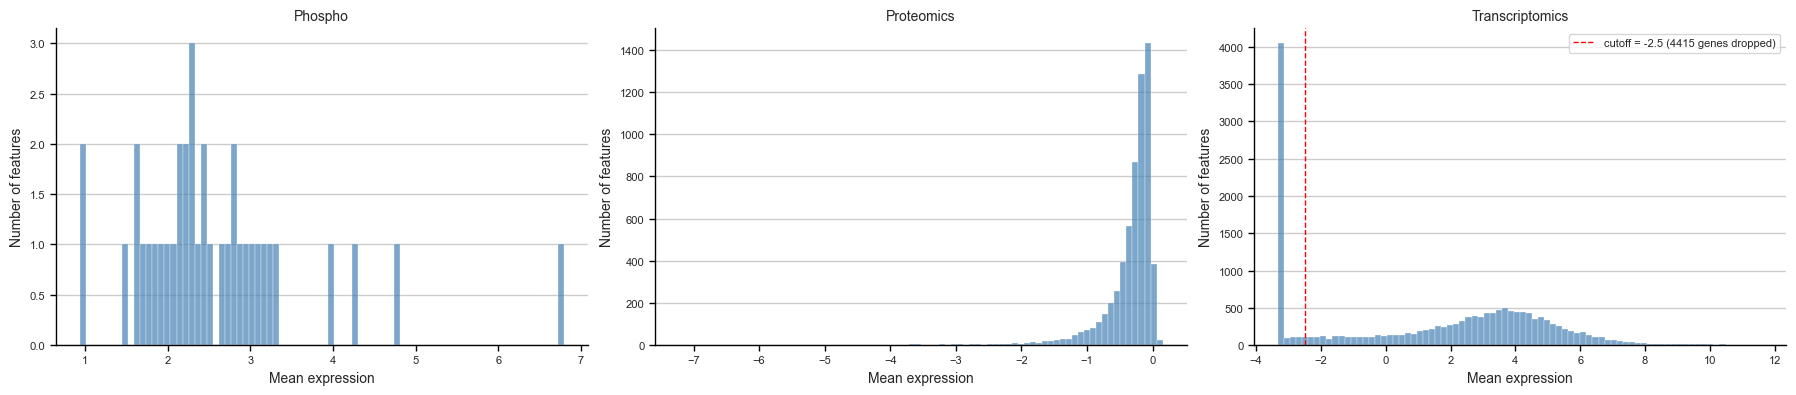

In [18]:
# ---------------------------------------------------------------------------
# Diagnostic: distribution of mean expression per feature across omics
# ---------------------------------------------------------------------------
from sklearn.impute import KNNImputer as _KNNImputer

_TRANS_MEDIAN_CUTOFF = -2.5
_Q_THRESH =0.10

_omic_mats = [
    ("Phospho", D.phospho_mat),
    ("Proteomics", D.prot_mat),
    ("Transcriptomics", D.trans_mat),
]
fig_mv, axes_mv = plt.subplots(1, len(_omic_mats), figsize=(18, 4))

for ax_mv, (omic_label, mat) in zip(np.atleast_1d(axes_mv), _omic_mats):
    Y = mat.values.astype(float)
    gene_names = np.array(mat.columns)

    # Same pre-processing as _run_limma: missingness filter + KNN impute
    frac_miss = np.isnan(Y).mean(axis=0)
    keep = frac_miss <= 0.30
    Y, gene_names = Y[:, keep], gene_names[keep]
    n_nan = np.isnan(Y).sum()
    if n_nan > 0:
        Y = _KNNImputer(n_neighbors=min(5, Y.shape[0] - 1)).fit_transform(Y)

    _means = np.median(Y, axis=0)

    ax_mv.hist(
        _means,
        bins=80,
        color="steelblue",
        edgecolor="white",
        alpha=0.7,
        linewidth=0.3,
    )
    ax_mv.set_xlabel("Mean expression")
    ax_mv.set_ylabel("Number of features")
    ax_mv.set_title(omic_label, fontsize=FONTSIZE_HEADING)
    configure_axis_spines(ax_mv)

    if omic_label == "Transcriptomics":
        _n_drop = (_means < _TRANS_MEDIAN_CUTOFF).sum()
        ax_mv.axvline(
            _TRANS_MEDIAN_CUTOFF,
            color="red",
            ls="--",
            lw=LW_MEDIUM,
            label=f"cutoff = {_TRANS_MEDIAN_CUTOFF} ({_n_drop} genes dropped)",
        )
        ax_mv.legend(fontsize=FONTSIZE, loc="upper right")
        print(
            f"{omic_label}: {len(_means)} genes, "
            f"dropping {_n_drop} with median < {_TRANS_MEDIAN_CUTOFF}, "
            f"keeping {len(_means) - _n_drop}"
        )
    else:
        print(f"{omic_label}: {len(_means)} features (no cutoff)")

fig_mv.tight_layout()
fig_mv.savefig("fig_gap_mean_distribution.pdf", bbox_inches="tight")
plt.show()

In [19]:
# plot_panel_volcano is imported from figures_paper.de_corr_plots
print('plot_panel_volcano defined')


plot_panel_volcano defined


p90RSK gap outlier set (6): ['cBT474', 'cCAL51', 'cEVSAT', 'cMACLS2', 'cMDAMB157', 'cUACC893']
iMEK RMSE outlier set (11): ['c184B5', 'cAU565', 'cCAL148', 'cHCC1187', 'cHCC1806', 'cHCC38', 'cLY2', 'cMCF12A', 'cMDAMB157', 'cT47D', 'cZR751']



limma DE: cytof ~ p90RSK_gap [All]
  57 samples (6 high, 51 low), 37 features
  KNN-imputed 21 missing values
  Fitted: 37 features, 0 FDR<0.1

limma DE: cytof ~ iMEK_RMSE [All]
  58 samples (11 high, 47 low), 37 features
  KNN-imputed 21 missing values
  Fitted: 37 features, 0 FDR<0.1
Pre-filtered proteomics: 7877 → 6762 genes with dropout in ≤50% of samples

limma DE: proteomics ~ p90RSK_gap [All]
  57 samples (6 high, 51 low), 6762 features
  Dropping 588 features with >30% missingness before imputation
  KNN-imputed 14442 missing values
  Fitted: 6174 features, 22 FDR<0.1

limma DE: proteomics ~ iMEK_RMSE [All]
  58 samples (11 high, 47 low), 6762 features
  Dropping 601 features with >30% missingness before imputation
  KNN-imputed 14322 missing values
  Fitted: 6161 features, 0 FDR<0.1
Pre-filtered transcriptomics: 16562 → 12143 genes with median expression > -2.5 (log2 CPM)

limma DE: transcriptomics ~ p90RSK_gap [All]
  57 samples (6 high, 51 low), 12143 features


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 2:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 3:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 4:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 5:   
R callback write-console: In rlm.default(x = X, y =

  Fitted: 12143 features, 6 FDR<0.1

limma DE: transcriptomics ~ iMEK_RMSE [All]
  58 samples (11 high, 47 low), 12143 features


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 2:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  


  Fitted: 12143 features, 4 FDR<0.1
  de_phospho_p90rsk: 37 genes tested, 0 FDR < 0.1
  de_prot_p90rsk: 6174 genes tested, 22 FDR < 0.1
  de_trans_p90rsk: 12143 genes tested, 6 FDR < 0.1
  de_phospho_imek: 37 genes tested, 0 FDR < 0.1
  de_prot_imek: 6161 genes tested, 0 FDR < 0.1
  de_trans_imek: 12143 genes tested, 4 FDR < 0.1


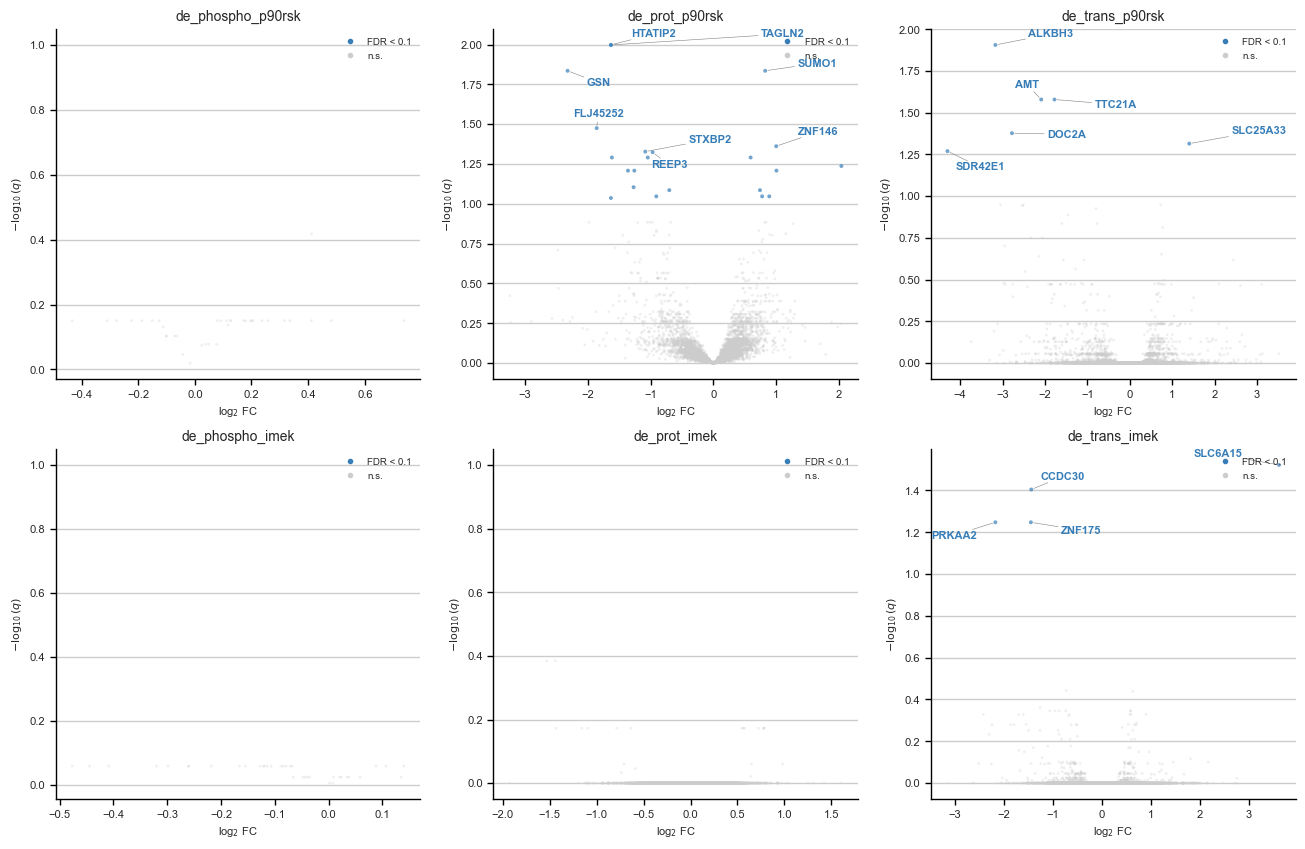

In [20]:
# ---------------------------------------------------------------------------
# Differential expression analysis (limma) — phospho, proteomics & transcriptomics
# Uses compute_marker_parameter_correlations from embeddings.py
# ---------------------------------------------------------------------------
from figures_paper.embeddings import compute_marker_parameter_correlations

# ── Define outlier sets (must match matrix index format: "c<name>") ────
_p90rsk_outlier_set = {cl for cl, sg in gap_subgroups_full.items() if sg == "high p90RSK gap"}
_imek_outlier_set = {"c" + cl for cl, sg in train_rmse_subgroups.items() if sg == "high iMEK RMSE"}

print(f"p90RSK gap outlier set ({len(_p90rsk_outlier_set)}): {sorted(_p90rsk_outlier_set)}")
print(f"iMEK RMSE outlier set ({len(_imek_outlier_set)}): {sorted(_imek_outlier_set)}")

# ── Encode subgroups as binary targets (1=outlier, 0=control) ─────────
_all_de_cells = D.phospho_mat.index.union(D.prot_mat.index).union(D.trans_mat.index)
_p90rsk_binary = pd.Series(
    {cl: 1 if cl in _p90rsk_outlier_set else 0 for cl in _all_de_cells
     if cl != 'cCAL148'},  # exclude for of E203K resistance mutation
    name="p90RSK_gap",
)
_imek_binary = pd.Series(
    {cl: 1 if cl in _imek_outlier_set else 0 for cl in _all_de_cells},
    name="iMEK_RMSE",
)
_binary_targets = {"p90RSK_gap": _p90rsk_binary, "iMEK_RMSE": _imek_binary}

# ── Run DE (one call per omic) ─────────────────────────────────────────
_de_by_omic = {}
for _omic_name, _dtype in [
    ("phospho",   "cytof"),
    ("prot",     "proteomics"),
    ("trans",    "transcriptomics"),
]:
    _de_by_omic[_omic_name] = compute_marker_parameter_correlations(
        method="differential_expression",
        data_type=_dtype,
        targets=_binary_targets,
        alpha=_Q_THRESH,
        exclude="CAL148",
    )

de_phospho_p90rsk = _de_by_omic["phospho"].query("parameter == 'p90RSK_gap'").reset_index(drop=True)
de_prot_p90rsk    = _de_by_omic["prot"].query("parameter == 'p90RSK_gap'").reset_index(drop=True)
de_trans_p90rsk   = _de_by_omic["trans"].query("parameter == 'p90RSK_gap'").reset_index(drop=True)
de_phospho_imek   = _de_by_omic["phospho"].query("parameter == 'iMEK_RMSE'").reset_index(drop=True)
de_prot_imek      = _de_by_omic["prot"].query("parameter == 'iMEK_RMSE'").reset_index(drop=True)
de_trans_imek     = _de_by_omic["trans"].query("parameter == 'iMEK_RMSE'").reset_index(drop=True)

# ── Quick summary ─────────────────────────────────────────────────────
de_results = {
    "de_phospho_p90rsk": de_phospho_p90rsk,
    "de_prot_p90rsk": de_prot_p90rsk,
    "de_trans_p90rsk": de_trans_p90rsk,
    "de_phospho_imek": de_phospho_imek,
    "de_prot_imek": de_prot_imek,
    "de_trans_imek": de_trans_imek,
}
f, axs = plt.subplots(figsize=(16, 10), nrows=2, ncols=3)
for ax, (name, df) in zip(axs.flat, de_results.items()):
    n_sig = (df["pvalue_corrected"] < _Q_THRESH).sum()
    print(f"  {name}: {len(df)} genes tested, {n_sig} FDR < {_Q_THRESH}")
    plot_panel_volcano(ax, df, title=name, show_legend=True,
                       fc_col="log2_fold_change", q_col="pvalue_corrected", gene_col="marker", alpha=_Q_THRESH)
plt.show()


In [21]:
# Print FDR-significant genes across all DE analyses
for _name, _de in [
    ("Phospho @ p90RSK gap", de_phospho_p90rsk),
    ("Prot @ p90RSK gap", de_prot_p90rsk),
    ("Trans @ p90RSK gap", de_trans_p90rsk),
    ("Phospho @ iMEK RMSE", de_phospho_imek),
    ("Prot @ iMEK RMSE", de_prot_imek),
    ("Trans @ iMEK RMSE", de_trans_imek),
]:
    _hits = _de[_de["pvalue_corrected"] < _Q_THRESH].sort_values("pvalue_corrected")
    print(f"{'='*60}")
    print(f"{_name}:  {len(_hits)} significant genes (FDR < {_Q_THRESH})")
    print(f"{'='*60}")
    if len(_hits) == 0:
        print("  (none)")
        continue
    for _, _r in _hits.iterrows():
        _tag = ""
        if _r["marker"] in _CORE_MAPK_GENES:
            _tag = " â core MAPK"
        elif _r["marker"] in set(D.MAPK_GENES):
            _tag = " â MAPK"
        print(f"  {_r['marker']:<12s}  logFC={_r['log2_fold_change']:+.3f}  q={_r['pvalue_corrected']:.2e}{_tag}")


Phospho @ p90RSK gap:  0 significant genes (FDR < 0.1)
  (none)
Prot @ p90RSK gap:  22 significant genes (FDR < 0.1)
  HTATIP2       logFC=-1.632  q=1.01e-02
  TAGLN2        logFC=-1.629  q=1.01e-02
  GSN           logFC=-2.320  q=1.46e-02
  SUMO1         logFC=+0.824  q=1.46e-02
  FLJ45252      logFC=-1.858  q=3.35e-02
  ZNF146        logFC=+0.999  q=4.35e-02
  STXBP2        logFC=-1.084  q=4.70e-02
  REEP3         logFC=-0.967  q=4.74e-02
  ACO1          logFC=-1.045  q=5.12e-02
  BAG3          logFC=-1.615  q=5.12e-02
  EHMT2         logFC=+0.592  q=5.12e-02
  PEG10         logFC=+2.036  q=5.79e-02
  S100A11       logFC=-1.359  q=6.19e-02
  RAB5IF        logFC=-1.258  q=6.19e-02
  PRAF2         logFC=+1.003  q=6.19e-02
  TDRKH         logFC=-1.270  q=7.87e-02
  KIFAP3        logFC=-0.702  q=8.21e-02
  ORC3          logFC=+0.741  q=8.21e-02
  TOR1AIP1      logFC=-0.908  q=8.98e-02
  TMEM126B      logFC=+0.888  q=8.98e-02
  ZMYM3         logFC=+0.775  q=8.98e-02
  THAP12        logF

In [22]:
de_prot_p90rsk

,marker,parameter,log2_fold_change,pvalue,pvalue_corrected,significant,mean_low,mean_high,n_low,n_high,subtype,abs_log2fc
0,KRT17,p90RSK_gap,-3.239346,0.008076,0.377844,False,-3.475887,-6.870928,51,6,All,3.239346
1,S100P,p90RSK_gap,-3.222380,0.039939,0.555374,False,-2.417562,-5.000485,51,6,All,3.222380
2,ALDH1A3,p90RSK_gap,-2.897504,0.036065,0.548785,False,-2.139030,-5.109671,51,6,All,2.897504
3,RB1CC1,p90RSK_gap,-2.568989,0.027824,0.523434,False,-1.261127,-4.259203,51,6,All,2.568989
4,TUBA4A,p90RSK_gap,-2.476599,0.001456,0.195483,False,-0.801061,-3.268340,51,6,All,2.476599
...,...,...,...,...,...,...,...,...,...,...,...,...
6169,ECI1,p90RSK_gap,-0.000192,0.999426,0.999750,False,-0.156603,-0.162638,51,6,All,0.000192
6170,MRPS14,p90RSK_gap,-0.000155,0.999422,0.999750,False,-0.071916,-0.059707,51,6,All,0.000155
6171,HYPK,p90RSK_gap,0.000154,0.999135,0.999750,False,-0.027906,-0.038749,51,6,All,0.000154
6172,TSNAX,p90RSK_gap,-0.000088,0.999602,0.999764,False,-0.050418,-0.059899,51,6,All,0.000088


In [23]:
# ---------------------------------------------------------------------------
# Correlations: all omics features vs pERK iMEK RMSE and p90RSK gap
# Uses compute_marker_parameter_correlations from embeddings.py
# ---------------------------------------------------------------------------
from statsmodels.stats.multitest import multipletests
from figures_paper.embeddings import compute_marker_parameter_correlations


def _prefix_c(series):
    series = series.copy()
    series.index = pd.Index(
        [idx if str(idx).startswith("c") else f"c{idx}" for idx in series.index]
    )
    return series


_perk_label = OBS_LABELS.get("pERK_Y204_obs", "pERK(p Y204)").replace(" [a.u.]", "")
_perk_imek_rows = [r for r in _train_pivot.index if r.startswith(_perk_label) and r.endswith("+iMEK")]
_perk_iegfr_rows = [r for r in _train_pivot.index if r.startswith(_perk_label) and r.endswith("+iEGFR")]
_perk_imek_rmse_per_cl = _prefix_c(_train_pivot.loc[_perk_imek_rows].mean(axis=0))
_perk_imek_rmse_per_cl.name = "pERK_iMEK_RMSE"
_perk_iegfr_rmse_per_cl = _prefix_c(_train_pivot.loc[_perk_iegfr_rows].mean(axis=0))
_perk_iegfr_rmse_per_cl.name = "pERK_iEGFR_RMSE"

_p90_label = OBS_LABELS.get("pRPS6KA1_S380_obs", "pRPS6KA1(p S380)").replace(" [a.u.]", "")
_p90_rows = [r for r in _hm_pivot.index if r.startswith(_p90_label)]
if not _p90_rows:
    raise ValueError("Could not identify p90RSK gap rows in _hm_pivot")
_p90_gap_per_cl = _prefix_c(_hm_pivot.loc[_p90_rows].mean(axis=0))
_p90_gap_per_cl.name = "p90RSK_gap"

_target_series = {
    "pERK_iMEK_RMSE": _perk_imek_rmse_per_cl,
    "pERK_iEGFR_RMSE": _perk_iegfr_rmse_per_cl,
    "p90RSK_gap": _p90_gap_per_cl,
}

_parts = []
for _omic_name in ["cytof", "proteomics", "transcriptomics"]:
    _corr = compute_marker_parameter_correlations(
        method="pearson",
        data_type=_omic_name,
        targets=_target_series,
    )
    _corr["omic"] = _omic_name if _omic_name != "cytof" else "phospho"
    _parts.append(_corr)

if not _parts:
    raise ValueError("No valid feature-target correlations were computed")

feature_target_correlations = pd.concat(_parts, ignore_index=True)

# Target-wide FDR (across all omics, per target)
feature_target_correlations["pvalue_corrected_target"] = np.nan
for _tgt in feature_target_correlations["parameter"].unique():
    _mask = feature_target_correlations["parameter"] == _tgt
    _, _qvals, _, _ = multipletests(
        feature_target_correlations.loc[_mask, "pvalue"].values, method="fdr_bh"
    )
    feature_target_correlations.loc[_mask, "pvalue_corrected_target"] = _qvals

for _tgt in ["pERK_iMEK_RMSE", "pERK_iEGFR_RMSE", "p90RSK_gap"]:
    print(f"{"=" * 80}")
    print(_tgt)
    print(f"{"=" * 80}")
    _tgt_df = feature_target_correlations.query("parameter == @_tgt")
    for _omic_name in ["phospho", "proteomics", "transcriptomics"]:
        _sub = _tgt_df.query("omic == @_omic_name")
        if _sub.empty:
            print(f"  {_omic_name:<15s} no valid pairs")
            continue
        print(
            f"  {_omic_name:<15s} {_sub.shape[0]:5d} features tested | "
            f"Pearson FDR<{_Q_THRESH}: {(_sub['pvalue_corrected'] < _Q_THRESH).sum():3d}"
        )

Pre-filtered proteomics: 7877 → 6762 genes with dropout in ≤50% of samples
Pre-filtered transcriptomics: 16562 → 12143 genes with median expression > -2.5 (log2 CPM)
pERK_iMEK_RMSE
  phospho            37 features tested | Pearson FDR<0.1:   0
  proteomics       6762 features tested | Pearson FDR<0.1:   0
  transcriptomics 12143 features tested | Pearson FDR<0.1:   1
pERK_iEGFR_RMSE
  phospho         no valid pairs
  proteomics      no valid pairs
  transcriptomics no valid pairs
p90RSK_gap
  phospho            37 features tested | Pearson FDR<0.1:   0
  proteomics       6762 features tested | Pearson FDR<0.1:   0
  transcriptomics 12143 features tested | Pearson FDR<0.1:   0


In [24]:
# ---------------------------------------------------------------------------
# All statistically significant feature hits from the correlation analysis
# ---------------------------------------------------------------------------

_sig_any_per_omic = feature_target_correlations.loc[
    feature_target_correlations["pvalue_corrected"] < _Q_THRESH
].copy()
_sig_any_targetwide = feature_target_correlations.loc[
    feature_target_correlations["pvalue_corrected_target"] < _Q_THRESH
].copy()

_sig_cols = [
    "parameter",
    "omic",
    "marker",
    "n_samples",
    "correlation",
    "pvalue",
    "pvalue_corrected",
    "pvalue_corrected_target",
]

print(f"Per-omic FDR significant hits (Pearson q < {_Q_THRESH})")
print("=" * 80)
if _sig_any_per_omic.empty:
    print("None")
else:
    _sig_any_per_omic = _sig_any_per_omic.sort_values(
        ["parameter", "omic", "pvalue_corrected", "abs_corr"],
        ascending=[True, True, True, False],
    )
    print(_sig_any_per_omic[_sig_cols].to_string(index=False))

print(f"Target-wide FDR significant hits (Pearson q_target < {_Q_THRESH})")
print("=" * 80)
if _sig_any_targetwide.empty:
    print("None")
else:
    _sig_any_targetwide = _sig_any_targetwide.sort_values(
        ["parameter", "omic", "pvalue_corrected_target", "abs_corr"],
        ascending=[True, True, True, False],
    )
    print(_sig_any_targetwide[_sig_cols].to_string(index=False))


Per-omic FDR significant hits (Pearson q < 0.1)
     parameter            omic marker  n_samples  correlation   pvalue  pvalue_corrected  pvalue_corrected_target
pERK_iMEK_RMSE transcriptomics ZNF329         58    -0.580963 0.000002           0.02115                 0.032992
Target-wide FDR significant hits (Pearson q_target < 0.1)
     parameter            omic marker  n_samples  correlation   pvalue  pvalue_corrected  pvalue_corrected_target
pERK_iMEK_RMSE transcriptomics ZNF329         58    -0.580963 0.000002           0.02115                 0.032992


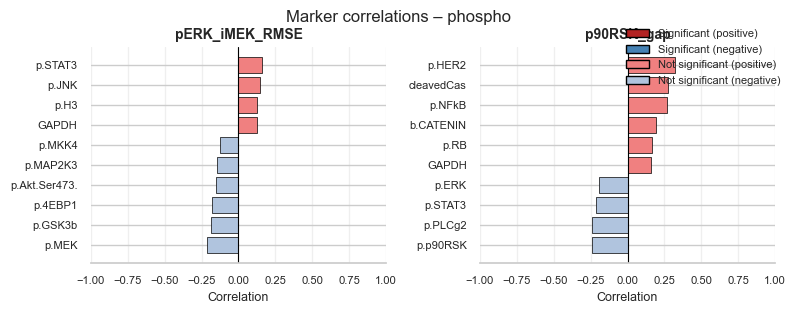

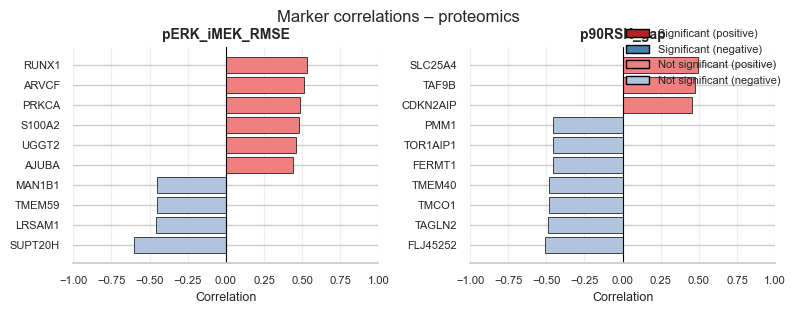

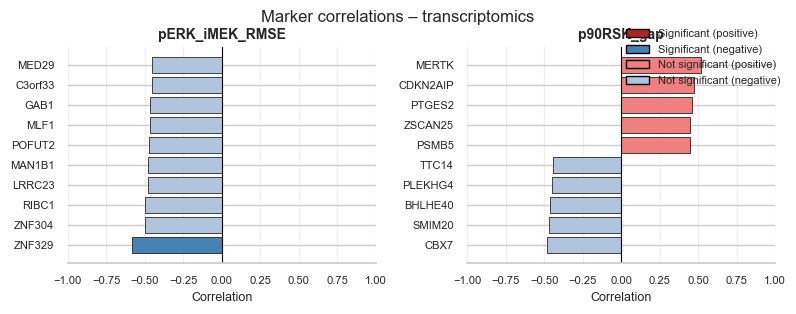

In [25]:
# ---------------------------------------------------------------------------
# Barplots: top correlated markers per target
# (pERK iMEK RMSE, pERK iEGFR RMSE, p90RSK gap) — one figure per omic
# ---------------------------------------------------------------------------
import importlib
import figures_paper.embeddings as _emb_module
importlib.reload(_emb_module)
from figures_paper.embeddings import plot_marker_parameter_barplots

_targets = ["pERK_iMEK_RMSE", "p90RSK_gap"]

for _omic in ["phospho", "proteomics", "transcriptomics"]:
    _sub = feature_target_correlations.query("omic == @_omic").copy()
    if _sub.empty:
        print(f"No data for {_omic}, skipping.")
        continue

    fig, axes = plot_marker_parameter_barplots(
        _sub,
        parameters=_targets,
        n_top=10,
        n_cols=2,
        alpha=_Q_THRESH,
    )
    fig.suptitle(f"Marker correlations – {_omic}", fontsize=12, y=1.02)
    plt.show()


p90RSK gap: 32 significant gene×omic entries  (0 MAPK, 0 Core MAPK)
  p90RSK gap: no MAPK/Core MAPK hits — showing top 10 overall


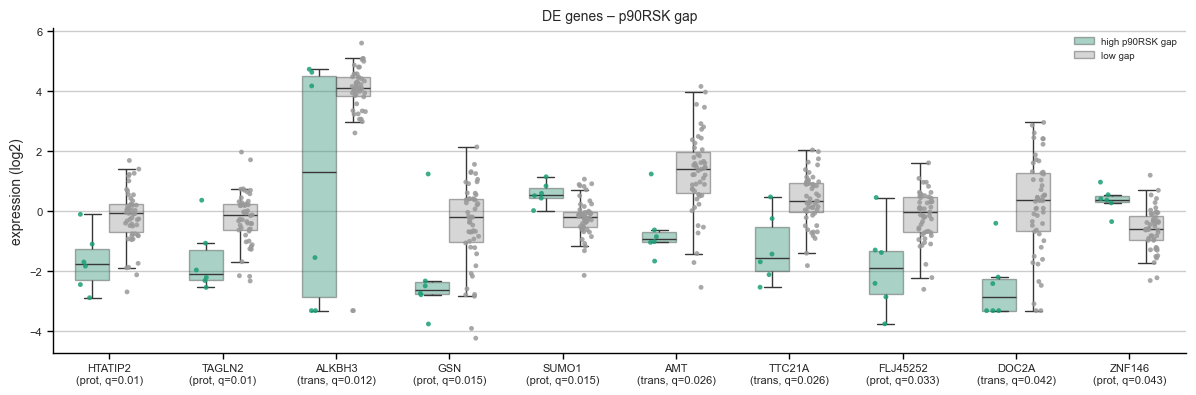

iMEK RMSE: 7 significant gene×omic entries  (0 MAPK, 0 Core MAPK)
  iMEK RMSE: no MAPK/Core MAPK hits — showing top 10 overall


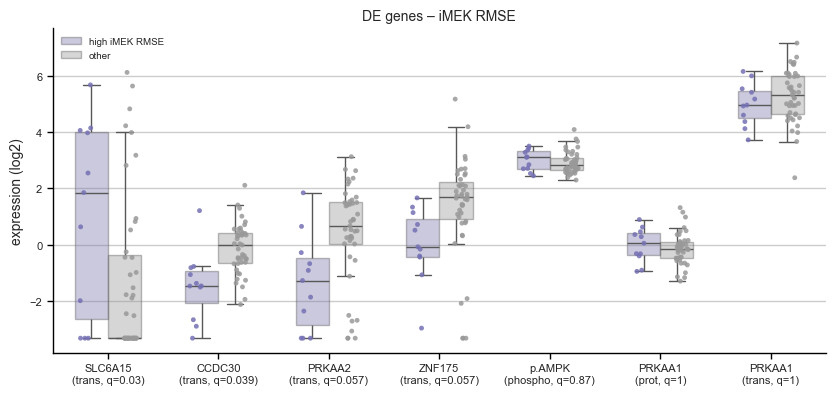

In [26]:
# ---------------------------------------------------------------------------
# Boxplots: expression of FDR-significant DE genes per subgroup
# ---------------------------------------------------------------------------

# ── Compute per-cell-line y-axis values ───────────────────────────────

# (A) p90RSK gen gap: mean ΔRMSE across conditions for pRPS6KA1_S380
_p90_label = OBS_LABELS.get("pRPS6KA1_S380_obs", "pRPS6KA1(p S380)").replace(" [a.u.]", "")
_p90_rows = [r for r in _hm_pivot.index if r.startswith(_p90_label)]
_p90_gap_per_cl = _hm_pivot.loc[_p90_rows].mean(axis=0)
_p90_gap_per_cl.name = "p90RSK_gap"

# (B) iMEK train RMSE: mean across observables for iMEK condition
_imek_rows = [r for r in _train_pivot.index if r.endswith("+iMEK")]
_imek_rmse_per_cl = _train_pivot.loc[_imek_rows].mean(axis=0)
_imek_rmse_per_cl.name = "iMEK_RMSE"

# ── Collect FDR-significant genes across all analyses ─────────────────
_analyses = [
    (
        "p90RSK gap",
        {"phospho": de_phospho_p90rsk, "prot": de_prot_p90rsk, "trans": de_trans_p90rsk},
        gap_subgroups,
        _SUBGROUP_COLORS,
    ),
    (
        "iMEK RMSE",
        {"phospho": de_phospho_imek, "prot": de_prot_imek, "trans": de_trans_imek},
        train_rmse_subgroups,
        _TRAIN_RMSE_COLORS,
    ),
]

for _prefix, _de_by_omic, _sg_dict, _color_dict in _analyses:
    # Get significant genes from all omics
    _sig_genes = []
    for _omic, _de in _de_by_omic.items():
        _hits = _de[(_de["pvalue_corrected"] < _Q_THRESH) | (_de["marker"] == "PRKAA1") | (_de["marker"] == "PRKAA2") | (_de["marker"] == "p.AMPK") ].sort_values("pvalue_corrected")
        for _, row in _hits.iterrows():
            _sig_genes.append(
                {
                    "marker": row["marker"],
                    "omic": _omic,
                    "pvalue_corrected": row["pvalue_corrected"],
                    "log2_fold_change": row["log2_fold_change"],
                }
            )

    if not _sig_genes:
        print(f"{_prefix}: no FDR-significant genes")
        continue

    _sig_df = pd.DataFrame(_sig_genes)
    # Deduplicate: keep best q per (gene, omic)
    _sig_df = _sig_df.sort_values("pvalue_corrected").drop_duplicates(subset=["marker", "omic"], keep="first")

    # Intersect with MAPK / Core MAPK gene sets
    _mapk_set = set(D.MAPK_GENES)
    _sig_df["in_MAPK"] = _sig_df["marker"].isin(_mapk_set)
    _sig_df["in_CoreMAPK"] = _sig_df["marker"].isin(_CORE_MAPK_GENES)

    _n_total = len(_sig_df)
    _n_mapk = _sig_df["in_MAPK"].sum()
    _n_core = _sig_df["in_CoreMAPK"].sum()
    print(f"{_prefix}: {_n_total} significant gene×omic entries  ({_n_mapk} MAPK, {_n_core} Core MAPK)")
    if _n_mapk:
        print(f"  MAPK hits: {sorted(_sig_df.loc[_sig_df['in_MAPK'], 'gene'].unique())}")
    if _n_core:
        print(f"  Core MAPK hits: {sorted(_sig_df.loc[_sig_df['in_CoreMAPK'], 'gene'].unique())}")

    # Restrict boxplot to MAPK ∪ Core MAPK (top 10 by q)
    _sig_mapk = _sig_df[_sig_df["in_MAPK"] | _sig_df["in_CoreMAPK"]].head(10)
    if _sig_mapk.empty:
        print(f"  {_prefix}: no MAPK/Core MAPK hits — showing top 10 overall")
        _sig_mapk = _sig_df.head(10)
    _sig_df = _sig_mapk

    rows = []
    gene_labels = []
    for _, srow in _sig_df.iterrows():
        gene, omic = srow["marker"], srow["omic"]
        if omic == "trans":
            mat = D.trans_mat
        elif omic == "prot":
            mat = D.prot_mat
        else:
            mat = D.phospho_mat
        if gene not in mat.columns:
            continue
        _gvals = mat[gene].copy()
        _gvals.index = _gvals.index.str.replace("^c", "", regex=True)
        _gvals = _gvals.dropna()
        _gvals = _gvals[_gvals.index.isin(_sg_dict.keys())]
        if len(_gvals) < 4:
            continue

        _glabel = f"{gene}\n({omic}, q={srow['pvalue_corrected']:.2g})"
        gene_labels.append(_glabel)
        for cl, gval in zip(_gvals.index, _gvals):
            rows.append(
                {
                    "gene": _glabel,
                    "expression": gval,
                    "subgroup": _sg_dict.get(cl, "other"),
                    "cell_line": cl,
                }
            )

    if not rows:
        print(f"  {_prefix}: no plottable genes")
        continue
    _bdf = pd.DataFrame(rows)

    # Subgroup order & palette
    if "high p90RSK gap" in _color_dict:
        _sg_order = [sg for sg in ["high p90RSK gap", "low gap"] if sg in _bdf["subgroup"].values]
    else:
        _sg_order = [sg for sg in ["high iMEK RMSE", "other"] if sg in _bdf["subgroup"].values]
    _palette = {sg: _color_dict.get(sg, "#999999") for sg in _sg_order}

    _gene_order = list(dict.fromkeys(gene_labels))
    _n_genes = len(_gene_order)
    fig_box, ax_box = plt.subplots(figsize=(max(1.2 * _n_genes, 4), 4))
    sns.boxplot(
        data=_bdf,
        x="gene",
        y="expression",
        hue="subgroup",
        order=_gene_order,
        hue_order=_sg_order,
        palette=_palette,
        width=0.6,
        fliersize=0,
        boxprops=dict(alpha=0.4),
        ax=ax_box,
    )
    sns.stripplot(
        data=_bdf,
        x="gene",
        y="expression",
        hue="subgroup",
        order=_gene_order,
        hue_order=_sg_order,
        palette=_palette,
        size=3.5,
        jitter=0.12,
        alpha=0.85,
        dodge=True,
        ax=ax_box,
    )

    _handles, _labels = ax_box.get_legend_handles_labels()
    _n_sg = len(_sg_order)
    ax_box.legend(_handles[:_n_sg], _labels[:_n_sg], fontsize=FONTSIZE - 1, frameon=False, loc="best")
    ax_box.set_title(f"DE genes – {_prefix}", fontsize=FONTSIZE_HEADING)
    ax_box.set_xlabel("")
    ax_box.set_ylabel("expression (log2)")
    configure_axis_spines(ax_box)
    fig_box.tight_layout()
    fig_box.savefig(f"fig_gap_boxplot_{_prefix.replace(' ', '_')}.pdf", bbox_inches="tight")
    plt.show()


In [27]:
_bdf[_bdf["gene"].str.contains("PRKAA2")]

,gene,expression,subgroup,cell_line
116,"PRKAA2\n(trans, q=0.057)",-1.120,other,184A1
117,"PRKAA2\n(trans, q=0.057)",-1.273,high iMEK RMSE,184B5
118,"PRKAA2\n(trans, q=0.057)",-2.358,high iMEK RMSE,AU565
119,"PRKAA2\n(trans, q=0.057)",0.253,other,BT20
120,"PRKAA2\n(trans, q=0.057)",0.533,other,BT474
121,"PRKAA2\n(trans, q=0.057)",0.237,other,BT483
122,"PRKAA2\n(trans, q=0.057)",-2.512,other,BT549
123,"PRKAA2\n(trans, q=0.057)",1.845,high iMEK RMSE,CAL148
124,"PRKAA2\n(trans, q=0.057)",-2.715,other,CAL51
125,"PRKAA2\n(trans, q=0.057)",0.478,other,CAL851


In [28]:
D.trans_mat['PRKAA2']

preequilibrationConditionId
c184A1         -1.120
c184B5         -1.273
cAU565         -2.358
cBT20           0.253
cBT474          0.533
cBT483          0.237
cBT549         -2.512
cCAL148         1.845
cCAL51         -2.715
cCAL851         0.478
cDU4475        -3.322
cEFM19         -3.322
cEFM192A        0.554
cEVSAT          2.632
cHBL100         1.087
cHCC1187       -3.322
cHCC1395       -3.322
cHCC1419        1.412
cHCC1428        0.288
cHCC1500        1.435
cHCC1569       -2.687
cHCC1806       -1.863
cHCC1937       -3.069
cHCC1954        0.494
cHCC202         1.500
cHCC2185       -0.304
cHCC2218        0.670
cHCC3153        1.590
cHCC38         -0.913
cHCC70          1.532
cHDQP1          0.881
cHs578T        -0.430
cJIMT1          0.035
cLY2           -3.322
cMACLS2         2.335
cMCF10A        -0.554
cMCF12A        -0.673
cMCF7          -3.322
cMDAMB134VI     0.906
cMDAMB157      -3.322
cMDAMB175VII    0.389
cMDAMB231       1.493
cMDAMB361       0.299
cMDAMB415       2.238
cMDA

## Mutational burden & enrichment

         All  p90RSK vs other  p = 0.03304  *
         All  iMEK vs other    p = 0.5611  n.s.
  MAPK related  p90RSK vs other  p = 0.09615  n.s.
  MAPK related  iMEK vs other    p = 0.5311  n.s.
   core MAPK  p90RSK vs other  p = 0.487  n.s.
   core MAPK  iMEK vs other    p = 0.8569  n.s.


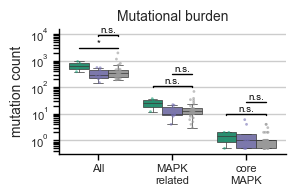

In [32]:
# ---------------------------------------------------------------------------
# Mutational burden: high p90RSK gap & high iMEK RMSE vs other
# ---------------------------------------------------------------------------

def prepare_burden_data(analysis, cbio_df, gap_subgroups_full,
                        train_rmse_subgroups, core_mapk_genes):
    """Prepare melted burden DataFrame and per-subgroup MW p-values.

    Returns a SimpleNamespace with:
        melt_df, labels_burden, pvals_p90rsk, pvals_imek
    """
    import types

    cbio_by_cl = cbio_df.groupby("cell_line")["gene"].apply(set).to_dict()

    labels_burden = {
        "n_all": "All", "n_mapk": "MAPK\nrelated", "n_core_mapk": "core\nMAPK",
    }

    p90_cls = {cl for cl, sg in gap_subgroups_full.items()
               if sg == "high p90RSK gap"}
    imek_cls = {"c" + cl for cl, sg in train_rmse_subgroups.items()
                if sg == "high iMEK RMSE"}

    df = analysis.copy()
    df["n_core_mapk"] = df["cell_line"].map(
        lambda cl: len(cbio_by_cl.get(cl, set()) & core_mapk_genes))
    df["Group"] = "other"
    df.loc[df["cell_line"].isin(p90_cls), "Group"] = "high p90RSK gap"
    df.loc[df["cell_line"].isin(imek_cls), "Group"] = "high iMEK RMSE"

    burden_cols = list(labels_burden.keys())
    other_df = df[df["Group"] == "other"]

    pvals_p90rsk, pvals_imek = {}, {}
    for sg_name, sg_pvals in [("high p90RSK gap", pvals_p90rsk),
                               ("high iMEK RMSE", pvals_imek)]:
        sg_df = df[df["Group"] == sg_name]
        for col in burden_cols:
            _, sg_pvals[col] = mannwhitneyu(
                sg_df[col], other_df[col], alternative="two-sided")

    melt_df = df.melt(
        id_vars=["cell_line", "Group"], value_vars=burden_cols,
        var_name="category", value_name="count")
    melt_df["cat_label"] = melt_df["category"].map(labels_burden)
    melt_df["count_log"] = melt_df["count"].clip(lower=0.5)

    return types.SimpleNamespace(
        melt_df=melt_df, labels_burden=labels_burden,
        pvals_p90rsk=pvals_p90rsk, pvals_imek=pvals_imek,
    )


# ── Helper: mutational burden boxplot ─────────────────────────────────
def plot_panel_burden(ax, melt_df, labels_burden, burden_pvals_p90rsk,
                      burden_pvals_imek):
    """Grouped boxplot of mutational burden with MW brackets."""
    _grp_order = ["high p90RSK gap", "high iMEK RMSE", "other"]
    _pal_b = {
        "high p90RSK gap": _SUBGROUP_COLORS["high p90RSK gap"],
        "high iMEK RMSE":  _TRAIN_RMSE_COLORS["high iMEK RMSE"],
        "other":           _COLOR_DEFAULT,
    }
    _cat_order = list(labels_burden.values())

    sns.boxplot(data=melt_df, x="cat_label", y="count_log", hue="Group",
                hue_order=_grp_order, order=_cat_order, palette=_pal_b,
                linewidth=LW_THIN, fliersize=0, ax=ax)
    sns.stripplot(data=melt_df, x="cat_label", y="count_log", hue="Group",
                  hue_order=_grp_order, order=_cat_order, palette=_pal_b,
                  dodge=True, size=2, alpha=0.6, ax=ax, legend=False)
    ax.set_yscale("log")
    ax.set_xlabel("")
    ax.set_ylabel("mutation count")
    ax.set_title("Mutational burden", fontsize=FONTSIZE_HEADING)

    # Annotate MW p-values (each group vs other) per category
    _n_grps = len(_grp_order)
    _width = 0.8 / _n_grps
    _other_idx = _grp_order.index("other")
    for i, col in enumerate(labels_burden):
        cat_data = melt_df.loc[melt_df["category"] == col, "count_log"]
        _ytop = cat_data.max() * 1.5
        x_other = i + (_other_idx - (_n_grps - 1) / 2) * _width

        # p90RSK vs other
        p_p90 = burden_pvals_p90rsk[col]
        x_p90 = i + (0 - (_n_grps - 1) / 2) * _width
        _draw_bracket(ax, x_p90, x_other, _ytop, 1.05, _sig_label(p_p90))
        print(f"  {labels_burden[col].replace('\n', ' '):>10s}  p90RSK vs other  p = {p_p90:.4g}  {_sig_label(p_p90)}")

        # iMEK RMSE vs other
        p_imek = burden_pvals_imek[col]
        x_imek = i + (1 - (_n_grps - 1) / 2) * _width
        _ytop2 = _ytop * 3
        _draw_bracket(ax, x_imek, x_other, _ytop2, 1.05, _sig_label(p_imek))
        print(f"  {labels_burden[col].replace('\n', ' '):>10s}  iMEK vs other    p = {p_imek:.4g}  {_sig_label(p_imek)}")

    ax.get_legend().remove()
    configure_axis_spines(ax)


# ── Prepare data + create figure ──────────────────────────────────────
_burden = prepare_burden_data(D.analysis, D.cbio_df, gap_subgroups_full,
                              train_rmse_subgroups, _CORE_MAPK_GENES)

fig_burden, ax_burden = plt.subplots(figsize=(3, 2))
plot_panel_burden(ax_burden, _burden.melt_df, _burden.labels_burden,
                  _burden.pvals_p90rsk, _burden.pvals_imek)

fig_burden.tight_layout()
plt.show()
fig_burden.savefig("fig_gap_burden_comparison.pdf", bbox_inches="tight")

Mutation fraction p-values (MW, two-sided):
        high iMEK RMSE  MAPK
related  p = 0.9604  n.s.
        high iMEK RMSE  core
MAPK     p = 0.8089  n.s.
       high p90RSK gap  MAPK
related  p = 0.7896  n.s.
       high p90RSK gap  core
MAPK     p = 0.6444  n.s.


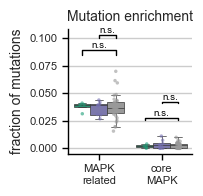

In [33]:
# ---------------------------------------------------------------------------
# MAPK mutation fraction (relative to total burden)
# ---------------------------------------------------------------------------


def prepare_enrichment_data(analysis, cbio_df, gap_subgroups_full,
                            train_rmse_subgroups, core_mapk_genes):
    """Prepare melted fraction DataFrame and per-subgroup MW p-values.

    Returns a SimpleNamespace with:
        melt_df, frac_cols, pvals
    """
    import types

    cbio_by_cl = cbio_df.groupby("cell_line")["gene"].apply(set).to_dict()

    frac_cols = {"frac_mapk": "MAPK\nrelated", "frac_core_mapk": "core\nMAPK"}

    p90_cls = {cl for cl, sg in gap_subgroups_full.items()
               if sg == "high p90RSK gap"}
    imek_cls = {"c" + cl for cl, sg in train_rmse_subgroups.items()
                if sg == "high iMEK RMSE"}

    df = analysis.copy()
    df["n_core_mapk"] = df["cell_line"].map(
        lambda cl: len(cbio_by_cl.get(cl, set()) & core_mapk_genes))
    df["Group"] = "other"
    df.loc[df["cell_line"].isin(p90_cls), "Group"] = "high p90RSK gap"
    df.loc[df["cell_line"].isin(imek_cls), "Group"] = "high iMEK RMSE"

    df["frac_mapk"]      = df["n_mapk"]      / df["n_all"].clip(lower=1)
    df["frac_core_mapk"] = df["n_core_mapk"] / df["n_all"].clip(lower=1)

    # MW tests per group pair (vs other) per fraction
    pvals = {}
    for grp_name in ["high p90RSK gap", "high iMEK RMSE"]:
        for col, label in frac_cols.items():
            g_vals = df.loc[df["Group"] == grp_name, col]
            o_vals = df.loc[df["Group"] == "other", col]
            _, p = mannwhitneyu(g_vals, o_vals, alternative="two-sided")
            pvals[(grp_name, label)] = p

    print("Mutation fraction p-values (MW, two-sided):")
    for (grp, cat), p in sorted(pvals.items()):
        print(f"  {grp:>20s}  {cat:<12s}  p = {p:.4g}  {_sig_label(p)}")

    melt_df = df.melt(
        id_vars=["cell_line", "Group"], value_vars=list(frac_cols),
        var_name="category", value_name="fraction")
    melt_df["cat_label"] = melt_df["category"].map(frac_cols)

    return types.SimpleNamespace(
        melt_df=melt_df, frac_cols=frac_cols, pvals=pvals,
    )


# ── Helper: mutation-set enrichment boxplot ───────────────────────────
def plot_panel_enrichment(ax, melt_df, frac_cols, pvals):
    """Grouped boxplot of mutation fraction with MW brackets."""
    _grp_order = ["high p90RSK gap", "high iMEK RMSE", "other"]
    _pal = {
        "high p90RSK gap": _SUBGROUP_COLORS["high p90RSK gap"],
        "high iMEK RMSE":  _TRAIN_RMSE_COLORS["high iMEK RMSE"],
        "other":           _COLOR_DEFAULT,
    }
    _cat_order = list(frac_cols.values())

    sns.boxplot(data=melt_df, x="cat_label", y="fraction", hue="Group",
                hue_order=_grp_order, order=_cat_order, palette=_pal,
                linewidth=LW_THIN, fliersize=0, ax=ax)
    sns.stripplot(data=melt_df, x="cat_label", y="fraction", hue="Group",
                  hue_order=_grp_order, order=_cat_order, palette=_pal,
                  dodge=True, size=2.5, alpha=0.6, ax=ax, legend=False)
    ax.set_xlabel("")
    ax.set_ylabel("fraction of mutations")
    ax.set_title("Mutation enrichment",
                 fontsize=FONTSIZE_HEADING)

    # Brackets (each group vs other)
    _n_g = len(_grp_order)
    _width = 0.8 / _n_g
    _other_idx = _grp_order.index("other")
    for i, (col, label) in enumerate(frac_cols.items()):
        cat_data = melt_df.loc[melt_df["category"] == col, "fraction"]
        _ytop = cat_data.max() + 0.015
        x_other = i + (_other_idx - (_n_g - 1) / 2) * _width

        # p90RSK vs other
        p_p90 = pvals[("high p90RSK gap", label)]
        x_p90 = i + (0 - (_n_g - 1) / 2) * _width
        _draw_bracket(ax, x_p90, x_other, _ytop, 1.05, _sig_label(p_p90))

        # iMEK RMSE vs other
        p_imek = pvals[("high iMEK RMSE", label)]
        x_imek = i + (1 - (_n_g - 1) / 2) * _width
        _ytop2 = _ytop + 0.015
        _draw_bracket(ax, x_imek, x_other, _ytop2, 1.03, _sig_label(p_imek))

    ax.get_legend().remove()
    configure_axis_spines(ax)


# ── Prepare data + create figure ──────────────────────────────────────
_enrich = prepare_enrichment_data(D.analysis, D.cbio_df, gap_subgroups_full,
                                  train_rmse_subgroups, _CORE_MAPK_GENES)

fig_frac, ax_frac = plt.subplots(figsize=(2, 2))
plot_panel_enrichment(ax_frac, _enrich.melt_df, _enrich.frac_cols,
                      _enrich.pvals)

fig_frac.tight_layout()
fig_frac.savefig("fig_gap_burden_fraction.pdf", bbox_inches="tight")
plt.show()

## Z-score stability of top-4 sensitive parameters (train vs LOOCV-val)

Cell lines compared: 58

Parameter                                       Mean |Δz|   Median |Δz|   Pearson r  Spearman ρ
-----------------------------------------------------------------------------------------------
ERBB2_p_Y1248_ERBB2_kw                              0.222         0.147       0.948       0.953
RPS6KA1_p_S380_ERK__Y204_p_kw                       0.264         0.194       0.938       0.931


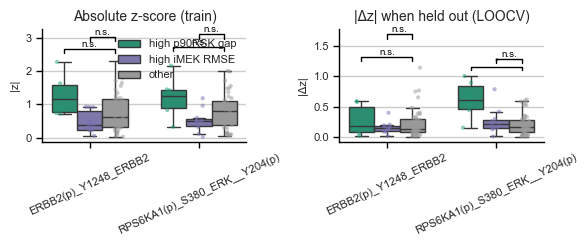


Group statistics per parameter (Mann-Whitney U vs 'other', BH-corrected):
Parameter                                         Group    n   mean|z|  mean|Δz|     p(|z|)     q(|z|)    p(|Δz|)    q(|Δz|)
--------------------------------------------------------------------------------------------------------------------------------------------
ERBB2(p)_Y1248_ERBB2                    high p90RSK gap    6     1.274     0.270     0.0674     0.2696     0.7962     0.9099
ERBB2(p)_Y1248_ERBB2                     high iMEK RMSE   10     0.479     0.164     0.1342     0.3012     0.9537     0.9537
ERBB2(p)_Y1248_ERBB2                              other   42     0.784     0.228        ref        ref        ref        ref
RPS6KA1(p)_S380_ERK__Y204(p)            high p90RSK gap    6     1.206     0.619     0.1506     0.3012     0.0019     0.0149
RPS6KA1(p)_S380_ERK__Y204(p)             high iMEK RMSE   10     0.519     0.266     0.2318     0.3709     0.3839     0.5119
RPS6KA1(p)_S380_ERK__Y204(p)      

In [46]:
# Compare z-score stability of top-4 sensitive parameters: train vs LOOCV-val
# Z-score per job first, then average across jobs.

from scipy.stats import zscore as _zscore

MODEL = "EGFR_MAPK__logobs_tegfr_aggavg"
FIGURE = "figure5"
DATA = "dream_cytof"
CONTEXT = "cytof_init"

SENSITIVE_PARAMS = [
    "ERBB2_p_Y1248_ERBB2_kw",
    "RPS6KA1_p_S380_ERK__Y204_p_kw",
]

# Load param_devs for figure5 (LOOCV)
_pdev_path = evaluations_dir / MODEL / DATA / f"param_devs_{FIGURE}.csv"
_pdev = pd.read_csv(_pdev_path, index_col=0)
_pdev = _pdev[_pdev["context"] == CONTEXT]

loocv_splits = sorted([s for s in _pdev["samples"].unique() if s != "all"])

# --- Train: z-score per job, then average across jobs ---
_all_train = _pdev[(_pdev["samples"] == "all") & (_pdev["dataset"] == "train")]
_train_z_parts = []
for job, grp in _all_train.groupby("job"):
    vals = grp.set_index("cell_line")[SENSITIVE_PARAMS]
    _train_z_parts.append(vals.apply(_zscore))
train_z = pd.concat(_train_z_parts).groupby(level=0).mean()

# --- Val: z-score per job within each LOOCV split, then average across jobs ---
_val_z_parts = []
for split in loocv_splits:
    held_out_cl = f"c{split}"
    split_df = _pdev[_pdev["samples"] == split]
    for job, grp in split_df.groupby("job"):
        vals = grp.set_index("cell_line")[SENSITIVE_PARAMS]
        if held_out_cl not in vals.index:
            continue
        z = vals.apply(_zscore)
        _val_z_parts.append(z.loc[[held_out_cl]])

if _val_z_parts:
    _val_z_all = pd.concat(_val_z_parts)
    val_z = _val_z_all.groupby(level=0).mean()
else:
    val_z = pd.DataFrame(columns=SENSITIVE_PARAMS)

# Keep only CLs present in both
common_cls = train_z.index.intersection(val_z.index)
train_z = train_z.loc[common_cls]
val_z = val_z.loc[common_cls]
n_cls = len(common_cls)

dz = val_z - train_z

# Print summary table
print(f"Cell lines compared: {n_cls}\n")
print(f"{'Parameter':<45s}  {'Mean |Δz|':>10s}  {'Median |Δz|':>12s}  {'Pearson r':>10s}  {'Spearman ρ':>10s}")
print("-" * 95)
for param in SENSITIVE_PARAMS:
    dz_p = dz[param]
    pearson = np.corrcoef(train_z[param], val_z[param])[0, 1]
    spearman = train_z[param].corr(val_z[param], method="spearman")
    print(f"{param:<45s}  {dz_p.abs().mean():10.3f}  {dz_p.abs().median():12.3f}  {pearson:10.3f}  {spearman:10.3f}")

# --- Build long-form dataframe: one row per (cell_line, param) ---
_group_map = {}
for cl in common_cls:
    sg = gap_subgroups_full.get(cl, "low gap")
    # train_rmse_subgroups keys lack the "c" prefix
    _rmse_sg = train_rmse_subgroups.get(cl[1:] if cl.startswith("c") else cl, "other")
    if sg == "high p90RSK gap":
        _group_map[cl] = "high p90RSK gap"
    elif _rmse_sg == "high iMEK RMSE":
        _group_map[cl] = "high iMEK RMSE"
    else:
        _group_map[cl] = "other"

short_names = {
    p: p.replace("_p_", "(p)_").rsplit("_", 1)[0] for p in SENSITIVE_PARAMS
}

_rows = []
for param in SENSITIVE_PARAMS:
    for cl in common_cls:
        _rows.append({
            "Parameter": short_names[param],
            "|z| (train)": abs(train_z.loc[cl, param]),
            "|Δz| (train→val)": abs(dz.loc[cl, param]),
            "Group": _group_map[cl],
        })
box_df = pd.DataFrame(_rows)

_GROUP_ORDER = ["high p90RSK gap", "high iMEK RMSE", "other"]
_GROUP_PALETTE = {
    "high p90RSK gap": _SUBGROUP_COLORS["high p90RSK gap"],
    "high iMEK RMSE": _TRAIN_RMSE_COLORS["high iMEK RMSE"],
    "other": _COLOR_DEFAULT,
}
_param_order = [short_names[p] for p in SENSITIVE_PARAMS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.5))

sns.boxplot(data=box_df, x="Parameter", y="|z| (train)", hue="Group",
            order=_param_order, hue_order=_GROUP_ORDER,
            palette=_GROUP_PALETTE, width=0.7, fliersize=0, ax=ax1)
sns.stripplot(data=box_df, x="Parameter", y="|z| (train)", hue="Group",
              order=_param_order, hue_order=_GROUP_ORDER,
              palette=_GROUP_PALETTE, size=3, alpha=0.5, dodge=True, jitter=0.12, ax=ax1,
              legend=False)
ax1.set_title("Absolute z-score (train)", fontsize=FONTSIZE_HEADING)
ax1.set_xlabel("")
ax1.set_ylabel("|z|", fontsize=FONTSIZE)
ax1.tick_params(axis="x", rotation=25, labelsize=FONTSIZE)
ax1.legend(fontsize=FONTSIZE, loc="upper right", frameon=False)
configure_axis_spines(ax1)

sns.boxplot(data=box_df, x="Parameter", y="|Δz| (train→val)", hue="Group",
            order=_param_order, hue_order=_GROUP_ORDER,
            palette=_GROUP_PALETTE, width=0.7, fliersize=0, ax=ax2)
sns.stripplot(data=box_df, x="Parameter", y="|Δz| (train→val)", hue="Group",
              order=_param_order, hue_order=_GROUP_ORDER,
              palette=_GROUP_PALETTE, size=3, alpha=0.5, dodge=True, jitter=0.12, ax=ax2,
              legend=False)
ax2.set_title("|Δz| when held out (LOOCV)", fontsize=FONTSIZE_HEADING)
ax2.set_xlabel("")
ax2.set_ylabel("|Δz|", fontsize=FONTSIZE)
ax2.tick_params(axis="x", rotation=25, labelsize=FONTSIZE)
ax2.get_legend().remove()
configure_axis_spines(ax2)

# --- Mann-Whitney U: each gap group vs "other" per param & metric ---
_zscore_pvals = {}  # (metric, param_short, group) -> p-value
for metric in ["|z| (train)", "|Δz| (train→val)"]:
    for sn in _param_order:
        other_vals = box_df.loc[(box_df["Parameter"] == sn) & (box_df["Group"] == "other"), metric]
        for grp in _GROUP_ORDER:
            if grp == "other":
                continue
            grp_vals = box_df.loc[(box_df["Parameter"] == sn) & (box_df["Group"] == grp), metric]
            if len(grp_vals) < 2 or len(other_vals) < 2:
                continue
            _, p = mannwhitneyu(grp_vals, other_vals, alternative="two-sided")
            _zscore_pvals[(metric, sn, grp)] = p

# BH correction across all tests
_pval_keys = sorted(_zscore_pvals.keys())
_pval_raw = np.array([_zscore_pvals[k] for k in _pval_keys])
_, _pval_adj, _, _ = multipletests(_pval_raw, method="fdr_bh")
_zscore_qvals = dict(zip(_pval_keys, _pval_adj))

# Annotate brackets on both panels (using BH-adjusted q-values)
_n_groups = len(_GROUP_ORDER)
_box_width = 0.7
_dodge_width = _box_width / _n_groups
for ax_panel, metric in [(ax1, "|z| (train)"), (ax2, "|Δz| (train→val)")]:
    for i, sn in enumerate(_param_order):
        other_idx = _GROUP_ORDER.index("other")
        _bracket_offset = 0
        for grp in _GROUP_ORDER:
            if grp == "other":
                continue
            q = _zscore_qvals.get((metric, sn, grp))
            if q is None:
                continue
            grp_idx = _GROUP_ORDER.index(grp)
            x1 = i + (grp_idx - (_n_groups - 1) / 2) * _dodge_width
            x2 = i + (other_idx - (_n_groups - 1) / 2) * _dodge_width
            # y position: max of both groups + stacking offset
            grp_vals = box_df.loc[(box_df["Parameter"] == sn) & (box_df["Group"] == grp), metric]
            other_vals = box_df.loc[(box_df["Parameter"] == sn) & (box_df["Group"] == "other"), metric]
            _ymax = max(grp_vals.max(), other_vals.max())
            _ytop = _ymax * 1.1 + _bracket_offset * 0.35
            _h_ratio = 1.05  # bracket bar at y * h_ratio (slightly above y)
            _draw_bracket(ax_panel, x1, x2, _ytop, _h_ratio, _sig_label(q))
            _bracket_offset += 1

fig.tight_layout()
fig.savefig("zscore_stability_boxplots.pdf", bbox_inches="tight")
fig.savefig("zscore_stability_boxplots.png", dpi=300, bbox_inches="tight")
fig.savefig("zscore_stability_boxplots.svg", dpi=300, bbox_inches="tight")
plt.show()

# Print group stats per param with p-values and q-values
print("\nGroup statistics per parameter (Mann-Whitney U vs 'other', BH-corrected):")
print(f"{'Parameter':<35s}  {'Group':>18s}  {'n':>3s}  {'mean|z|':>8s}  {'mean|Δz|':>8s}  {'p(|z|)':>9s}  {'q(|z|)':>9s}  {'p(|Δz|)':>9s}  {'q(|Δz|)':>9s}")
print("-" * 140)
for param in SENSITIVE_PARAMS:
    sn = short_names[param]
    for grp in _GROUP_ORDER:
        sub = box_df[(box_df["Parameter"] == sn) & (box_df["Group"] == grp)]
        p_z = _zscore_pvals.get(("|z| (train)", sn, grp), float("nan"))
        q_z = _zscore_qvals.get(("|z| (train)", sn, grp), float("nan"))
        p_dz = _zscore_pvals.get(("|Δz| (train→val)", sn, grp), float("nan"))
        q_dz = _zscore_qvals.get(("|Δz| (train→val)", sn, grp), float("nan"))
        p_z_str = f"{p_z:.4f}" if not np.isnan(p_z) else "  ref"
        q_z_str = f"{q_z:.4f}" if not np.isnan(q_z) else "  ref"
        p_dz_str = f"{p_dz:.4f}" if not np.isnan(p_dz) else "  ref"
        q_dz_str = f"{q_dz:.4f}" if not np.isnan(q_dz) else "  ref"
        print(f"{sn:<35s}  {grp:>18s}  {len(sub):3d}  "
              f"{sub['|z| (train)'].mean():8.3f}  "
              f"{sub['|Δz| (train→val)'].mean():8.3f}  "
              f"{p_z_str:>9s}  {q_z_str:>9s}  "
              f"{p_dz_str:>9s}  {q_dz_str:>9s}")

## Composite figure

Composite figure saved.


<function matplotlib.pyplot.show(close=None, block=None)>

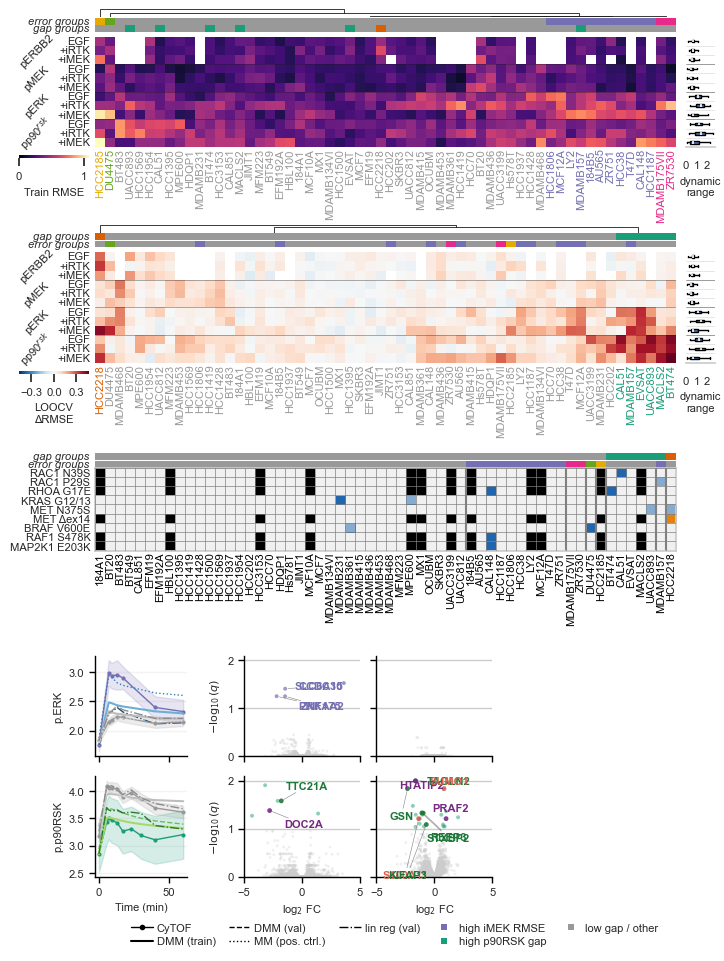

In [35]:
# Process groups for p90RSK gap volcano labels
_P90RSK_GENE_GROUPS = {
    "cytoskeletal dynamics": (
        ["GSN", "STXBP2", "TAGLN2", "KIFAP3", "REEP3", "EXOC1", "TTC21A"],
        "#1b7837",   # dark green
    ),
    "endo/exocytosis": (
        ["DOC2A", "HTATIP2", "PRAF2"],
        "#762a83",   # purple
    ),
    "calcium sensing/dynamics": (
        ["SUMO1", "S100A11"],
        "#d6604d",   # red-orange  (GSN/STXBP2/DOC2A already claimed above)
    ),
}

# ---------------------------------------------------------------------------
# Composite figure – generalisation gap analysis
#   Col 0 (main):  all 4 rows of content
#   Col 1 (right): boxplots for rows 0–1 only; empty for rows 2–3
#   Row 0:  Train RMSE heatmap | boxplot
#   Row 1:  A (ΔRMSE heatmap)  | boxplot
#   Row 2:  SNP / cell-line heatmap (col 0 only)
#   Row 3:  2 sub-rows × dynamics | DE trans | DE prot | trans corr | prot corr | burden
# ---------------------------------------------------------------------------

fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(4, 2,
    height_ratios=[0.8, 0.8, 0.6, 1.6],
    width_ratios=[4, 0.2],
    hspace=0.8, wspace=0.03)

# ── Row 0: Train RMSE heatmap ────────────────────────────────────────
ax_train = fig.add_subplot(gs[0, 0])
_ax_train_box = fig.add_subplot(gs[0, 1])
plot_panel_train_heatmap(ax_train, ax_box=_ax_train_box)

# ── Row 1: A — ΔRMSE heatmap ─────────────────────────────────────────
ax_A = fig.add_subplot(gs[1, 0])
_ax_A_box = fig.add_subplot(gs[1, 1])
plot_panel_delta_heatmap(ax_A, train_rmse_sg=train_rmse_subgroups,
                         ax_box=_ax_A_box)

# ── Row 2: SNP / cell-line heatmap (left column only) ────────────────
ax_snp = fig.add_subplot(gs[2, 0])
plot_panel_snp_heatmap(ax_snp, show_legend=False)

# ── Row 3: dynamics + DE + correlations + mutations (2 sub-rows: iMEK top, p90RSK bottom)
# Columns: dynamics | spacer | trans volcano | prot volcano | space | blank |
gs_r3 = gs[3, 0].subgridspec(2, 6,
    width_ratios=[0.8, 0.2, 1, 1, 0.1, 1.2,],
    wspace=0.2, hspace=0.2)

# -- Top sub-row: high iMEK RMSE --
ax_dyn_imek = fig.add_subplot(gs_r3[0, 0])
plot_subgroup_dynamics(ax_dyn_imek, "p.ERK", "iMEK",
                       "high iMEK RMSE", train_rmse_subgroups,
                       sim_dfs=_sim_dfs_dyn_all,
                       show_xlabel=False)

ax_trans_imek = fig.add_subplot(gs_r3[0, 2])
plot_panel_volcano(ax_trans_imek, de_trans_imek, alpha=0.1,
                   fc_col="log2_fold_change", q_col="pvalue_corrected", gene_col="marker",
                   title="", show_legend=False, show_annotations=True,
                   color=_TRAIN_RMSE_COLORS["high iMEK RMSE"])

ax_prot_imek = fig.add_subplot(gs_r3[0, 3])
plot_panel_volcano(ax_prot_imek, de_prot_imek, alpha=0.1,
                   fc_col="log2_fold_change", q_col="pvalue_corrected", gene_col="marker",
                   title="", show_legend=False, show_annotations=True,
                   color=_TRAIN_RMSE_COLORS["high iMEK RMSE"])

# -- Bottom sub-row: high p90RSK gap --
ax_dyn_p90 = fig.add_subplot(gs_r3[1, 0])
plot_subgroup_dynamics(ax_dyn_p90, "p.p90RSK", "EGF",
                       "high p90RSK gap", gap_subgroups,
                       sim_dfs=_sim_dfs_dyn_gap,)

ax_trans_p90 = fig.add_subplot(gs_r3[1, 2])
plot_panel_volcano(ax_trans_p90, de_trans_p90rsk, alpha=0.1,
                   fc_col="log2_fold_change", q_col="pvalue_corrected", gene_col="marker",
                   title="", show_legend=False, show_annotations=True,
                   color=_SUBGROUP_COLORS["high p90RSK gap"],
                   gene_groups=_P90RSK_GENE_GROUPS)

ax_prot_p90 = fig.add_subplot(gs_r3[1, 3])
plot_panel_volcano(ax_prot_p90, de_prot_p90rsk, alpha=0.1,
                   fc_col="log2_fold_change", q_col="pvalue_corrected", gene_col="marker",
                   title="", show_legend=False, show_annotations=True,
                   color=_SUBGROUP_COLORS["high p90RSK gap"],
                   gene_groups=_P90RSK_GENE_GROUPS)

for ax in [ax_prot_imek, ax_trans_imek, ax_dyn_imek]:
    ax.set_xlabel("")
    ax.set_xticklabels([])


# Shared y-axis across all four volcano plots
_volcano_axes = [ax_trans_imek, ax_prot_imek, ax_trans_p90, ax_prot_p90]
_vol_ymax = max(ax.get_ylim()[1] for ax in _volcano_axes)
_vol_ymax = max(max(abs(ax.get_ylim()[1]), abs(ax.get_ylim()[0])) for ax in _volcano_axes)
for _vax in _volcano_axes:
    _vax.set_ylim(0, _vol_ymax)
    _vax.set_xlim(-5, 5)

# Hide y-axis for proteomics column (right volcanos)
for _vax in [ax_prot_imek, ax_prot_p90]:
    _vax.set_ylabel("")
    plt.setp(_vax.get_yticklabels(), visible=False)

# ── Unified legend below Row 3 ───────────────────────────────────────
# 2 rows × 4 columns: row 1 = line styles, row 2 = subgroup colours
_leg3_handles, _leg3_labels = [], []

# Row 1 — model / line styles
_leg3_handles.append(Line2D([], [], color="black", ls="-", marker="o",
                            markersize=3, lw=LW_MEDIUM))
_leg3_labels.append("CyTOF")
_leg3_handles.append(Line2D([], [], color="black", ls="-", lw=LW_THICK))
_leg3_labels.append("DMM (train)")
_leg3_handles.append(Line2D([], [], color="black", ls="--", lw=LW_MEDIUM))
_leg3_labels.append("DMM (val)")
_leg3_handles.append(Line2D([], [], color="black", ls=":", lw=LW_MEDIUM))
_leg3_labels.append("MM (pos. ctrl.)")
_leg3_handles.append(Line2D([], [], color="black", ls="-.", lw=LW_MEDIUM))
_leg3_labels.append("lin reg (val)")
_leg3_handles.append(Line2D([], [], ls="", marker="None"))
_leg3_labels.append(" ")

# Row 2 — subgroup colours
_leg3_handles.append(Line2D([], [], color=_TRAIN_RMSE_COLORS["high iMEK RMSE"],
                            ls="-", marker="s", markersize=4, lw=0,
                            markeredgewidth=0))
_leg3_labels.append("high iMEK RMSE")
_leg3_handles.append(Line2D([], [], color=_SUBGROUP_COLORS["high p90RSK gap"],
                            ls="-", marker="s", markersize=4, lw=0,
                            markeredgewidth=0))
_leg3_labels.append("high p90RSK gap")
_leg3_handles.append(Line2D([], [], color=_DYN_REST_COLOR,
                            ls="-", marker="s", markersize=4, lw=0,
                            markeredgewidth=0))
_leg3_labels.append("low gap / other")
_leg3_handles.append(Line2D([], [], ls="", marker="None"))
_leg3_labels.append(" ")

fig.legend(_leg3_handles, _leg3_labels, loc="lower center",
           bbox_to_anchor=(0.5, -0.04), ncol=5,
           fontsize=FONTSIZE, frameon=False, columnspacing=1.2,
           handletextpad=0.3, labelspacing=0.3)

fig.subplots_adjust(bottom=0.04)

fig.savefig("Figure_gap_composite.pdf", dpi=300,
            bbox_inches="tight", pad_inches=0.02)

fig.savefig("Figure_gap_composite.png", dpi=300,
            bbox_inches="tight", pad_inches=0.02)

print("Composite figure saved.")
plt.show


In [36]:
# Check significant DE hits
print("=== Proteomics (p90RSK): FDR < 0.05 ===")
print(de_prot_p90rsk[de_prot_p90rsk["pvalue_corrected"] < 0.05][["marker", "log2_fold_change", "pvalue_corrected"]].to_string())

print("=== Transcriptomics (p90RSK): FDR < 0.05 ===")
print(de_trans_p90rsk[de_trans_p90rsk["pvalue_corrected"] < 0.05][["marker", "log2_fold_change", "pvalue_corrected"]].to_string())

=== Proteomics (p90RSK): FDR < 0.05 ===
       marker  log2_fold_change  pvalue_corrected
7         GSN         -2.319947          0.014618
20   FLJ45252         -1.857644          0.033477
28    HTATIP2         -1.631530          0.010060
30     TAGLN2         -1.628676          0.010060
122    STXBP2         -1.084060          0.047018
156    ZNF146          0.999159          0.043475
169     REEP3         -0.966979          0.047421
276     SUMO1          0.823811          0.014618
=== Transcriptomics (p90RSK): FDR < 0.05 ===
       marker  log2_fold_change  pvalue_corrected
5      ALKBH3         -3.168206          0.012414
24      DOC2A         -2.777816          0.041944
103       AMT         -2.088174          0.026357
194    TTC21A         -1.775202          0.026357
401  SLC25A33          1.400777          0.048430


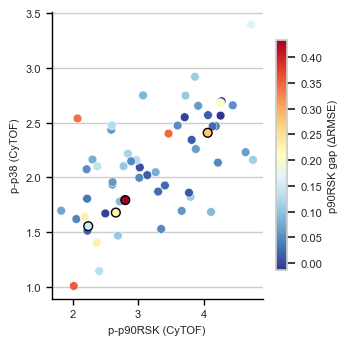

In [37]:
# Phospho-p38 vs phospho-PLCγ2, one dot per cell line
# Color: p90RSK gap (ΔRMSE); black outline: RAC1 N39S/P29S or RHOA G17E mutants
import matplotlib.colors as mcolors

_mut_rows_sc = [r for r in ["RAC1 N39S", "RAC1 P29S", "RHOA G17E"] if r in _snp_mat.index]

# Intersect cell lines across all three data sources (D.phospho_mat and _snp_mat use "c" prefix; _p90_gap_per_cl does not)
_cls_with_gap = {f"c{cl}" for cl in _p90_gap_per_cl.index}
_common_cls_sc = sorted(set(D.phospho_mat.index) & set(_snp_mat.columns) & _cls_with_gap)

_df_sc = pd.DataFrame({
    "x": D.phospho_mat.loc[_common_cls_sc, "p.p90RSK"],
    "y": D.phospho_mat.loc[_common_cls_sc, "p.p38"],
    "gap": [_p90_gap_per_cl[cl[1:]] for cl in _common_cls_sc],
}, index=_common_cls_sc).dropna()

_mut_mask_sc = (_snp_mat.loc[_mut_rows_sc, _df_sc.index].values > 0).any(axis=0)

_norm_sc = mcolors.Normalize(vmin=_df_sc["gap"].min(), vmax=_df_sc["gap"].max())
_cmap_sc = "RdYlBu_r"

fig, ax = plt.subplots(figsize=(3.5, 3.5))

sc = ax.scatter(
    _df_sc["x"], _df_sc["y"],
    c=_df_sc["gap"], cmap=_cmap_sc, norm=_norm_sc,
    s=40, edgecolors="white", lw=0.4, zorder=3,
)
ax.scatter(
    _df_sc["x"][_mut_mask_sc], _df_sc["y"][_mut_mask_sc],
    c=_df_sc["gap"][_mut_mask_sc], cmap=_cmap_sc, norm=_norm_sc,
    s=40, edgecolors="black", lw=1.0, zorder=4,
)

cb = fig.colorbar(sc, ax=ax, shrink=0.8)
cb.set_label("p90RSK gap (ΔRMSE)", fontsize=FONTSIZE)
cb.ax.tick_params(labelsize=FONTSIZE)

ax.set_xlabel("p-p90RSK (CyTOF)", fontsize=FONTSIZE)
ax.set_ylabel("p-p38 (CyTOF)", fontsize=FONTSIZE)
ax.tick_params(labelsize=FONTSIZE)
configure_axis_spines(ax)

plt.tight_layout()
plt.show()